## I. General imports & definitions

#### Import all used libraries & area weights

In [1]:
'''Import all needed libraries'''
import xarray as xr
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cftime
import random
import nc_time_axis
import datetime
import os
import pickle
import seaborn as sns
import matplotlib.patches as mpatches
from   matplotlib.lines import Line2D
from   matplotlib import colors
from   cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from   scipy.stats import linregress, pearsonr
from   xarray.coding.times import CFDatetimeCoder
from   statsmodels.tsa.stattools import acf

'''Import area weights'''
# Import weights for each lat-lon grid point since they have different sizes for different latitudes
# Nan for areas that are land covered, otherwise values proportional to size of the grid points, fully integrated = 1
area_weights = xr.open_mfdataset('area_weights.nc')
area_weights = area_weights['area_t']
# for visualization: area_weights.plot()

/home/tb2267/jupyter_venv/lib/python3.12/site-packages/dask/array/reductions.py:655: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


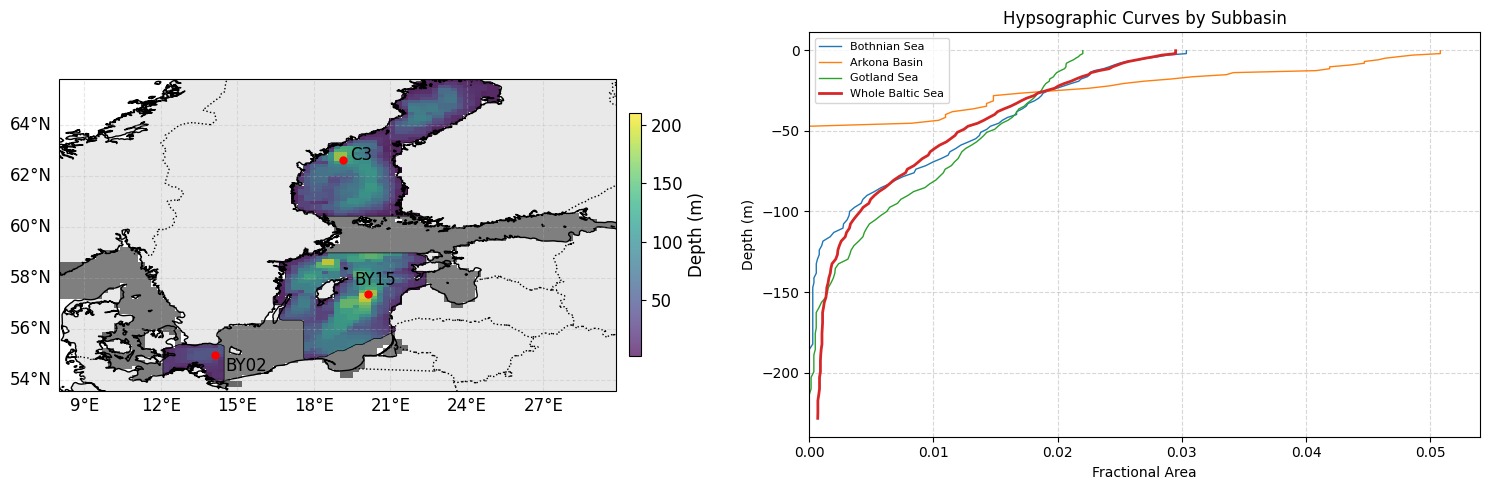

In [2]:
'''Define Basins and compute hypsos'''
# === 1. Load Data ===
bs_grid = xr.open_mfdataset("../reference_run/reference_run_01_1948/19480101.ocean_month_z.nc")
bs_grid = bs_grid['temp'].isel(time=0).drop_vars('time')
bs_grid = xr.where(~np.isnan(bs_grid), 1, bs_grid)  # 1 where valid

# === 2. Define Masks for Subbasins ===
# mask_bothnianbay  = ((bs_grid['xh'] + bs_grid['yh']) > 84.6) & (bs_grid['yh'] > 62)
mask_bothniansea  = (bs_grid['yh'] > 60.4) & (bs_grid['xh'] < 25.5) #& (~mask_bothnianbay)
mask_gof          = (bs_grid['yh'] > 59) & (bs_grid['yh'] < 61) & (bs_grid['xh'] > 24)
mask_arkona       = (bs_grid['xh'] > 12) & (bs_grid['xh'] < 14.5) & (bs_grid['yh'] < 55.4) & (bs_grid['yh'] > 54)
mask_bornholm     = (bs_grid['xh'] > 13) & (bs_grid['xh'] < 17.5) & (bs_grid['yh'] < 56.4) & (~mask_arkona)
mask_gotlandsea   = (bs_grid['xh'] > 15) & (bs_grid['yh'] < 59) & (~mask_bornholm) & (~mask_gof) & \
                    ((bs_grid['yh'] - 0.333 * bs_grid['xh']) > 48.8) & \
                    ((bs_grid['xh'] < 22.5) | (bs_grid['yh'] > 59))

arkona_weights = area_weights.where(mask_arkona) * (1/area_weights.where(mask_arkona).sum(dim=['xh','yh']))
gotland_weights = area_weights.where(mask_gotlandsea) * (1/area_weights.where(mask_gotlandsea).sum(dim=['xh','yh']))
bothnian_weights = area_weights.where(mask_bothniansea) * (1/area_weights.where(mask_bothniansea).sum(dim=['xh','yh']))


# === 3. Helper Function to Get Deepest Valid z_l per Grid Cell ===
def max_depth_masked(grid, mask):
    masked_grid = grid.where(mask)
    depth_at_valid = grid['z_l'].where(~np.isnan(masked_grid))
    max_depth = depth_at_valid.max(dim='z_l', skipna=True)
    return max_depth

# === 4. Compute Depth Grids ===
# depth_bothnianbay  = max_depth_masked(bs_grid, mask_bothnianbay)
depth_bothniansea  = max_depth_masked(bs_grid, mask_bothniansea)
# depth_gof          = max_depth_masked(bs_grid, mask_gof)
depth_arkona       = max_depth_masked(bs_grid, mask_arkona)
# depth_bornholm     = max_depth_masked(bs_grid, mask_bornholm)
depth_gotlandsea   = max_depth_masked(bs_grid, mask_gotlandsea)

# === 5. Station Coordinates ===
stations = [
    ("BY02", 14.12, 54.96),
    # ("BY05", 16.04, 55.20),
    ("BY15", 20.12, 57.36),
    # ("BY31", 18.20, 58.56),
    ("C3",   19.16, 62.64),
    # ("F9",   21.80, 64.56),
    # ("LL7",  24.92, 59.88),
]

# === 6. Hypsographic Function ===

def compute_hypsographic(grid, mask):
    masked = grid.where(mask)
    area = area_weights.where(mask)
    depth_area = (masked * area).sum(dim=['xh', 'yh'], skipna=True)
    hypsographic = depth_area / depth_area.sum(dim='z_l')
    return hypsographic

# === 7. Compute Hypsographic Curves ===
masks = [mask_bothniansea, mask_arkona, mask_gotlandsea]
labels = ['Bothnian Sea', 'Arkona Basin', 'Gotland Sea']

hypsos = {}
for label, mask in zip(labels, masks):
    hypsos[label] = compute_hypsographic(bs_grid, mask)

bs_mask = ~np.isnan(bs_grid)
hypsos['Whole Baltic Sea'] = compute_hypsographic(bs_grid, bs_mask)

# === 8. Combined Plot: Subbasins + Hypsographic Curves ===
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(1, 2, 2)


# --- Plot 1: Baltic Map with Subbasins ---
ax = ax1
proj = ccrs.PlateCarree()
#ax.set_extent([10, 31, 53, 66], crs=proj)
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
bs_mask_surface = ~np.isnan(bs_grid.isel(z_l=0))
ax.pcolormesh(bs_grid['xh'], bs_grid['yh'], bs_mask_surface, transform=proj, shading='auto', cmap='Greys', alpha=0.5)

all_depths = xr.concat([depth_bothniansea, depth_arkona, depth_gotlandsea], dim='basin')
vmin = float(all_depths.min(skipna=True).compute())
vmax = float(all_depths.max(skipna=True).compute())
norm = colors.Normalize(vmin=vmin, vmax=vmax)

for depth in [depth_bothniansea, depth_arkona, depth_gotlandsea]:
    im = ax.pcolormesh(bs_grid['xh'], bs_grid['yh'], depth, transform=proj, cmap='viridis', shading='auto', alpha=0.7, norm=norm)
    outline_mask = ~np.isnan(depth)
    ax.contour(bs_grid['xh'], bs_grid['yh'], outline_mask, levels=[0.5], colors='black', linewidths=0.5, transform=proj)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label("Depth (m)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

for name, lon, lat in stations:
    ax.plot(lon, lat, marker='o', color='red', markersize=5, transform=proj, label=f'{name}')
    if name == 'BY02':
        ax.text(lon + 0.4, lat - 0.6, name, fontsize=12, transform=proj, color='black')
    elif name == 'BY15':
        ax.text(lon - 0.55, lat + 0.35, name, fontsize=12, transform=proj, color='black')
    elif name == 'C3':
        ax.text(lon + 0.25, lat - 0.0, name, fontsize=12, transform=proj, color='black')

# ax.set_title("Baltic Sea Subbasins and Stations")
ax.set_xlabel("Longitude [°E]", fontsize=10)
ax.set_ylabel("Latitude [°N]", fontsize=10)
gl = ax.gridlines(draw_labels=True, crs=proj, linestyle='--', alpha=0.3)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# --- Plot 2: Hypsographic Curves ---
ax = ax2
for label, hypo in hypsos.items():
    ax.plot(hypo, -hypo['z_l'], label=label, linewidth=2 if label == 'Whole Baltic Sea' else 1)

ax.set_xlabel("Fractional Area")
ax.set_ylabel("Depth (m)")
ax.set_xlim(0, 0.054)
ax.set_title("Hypsographic Curves by Subbasin")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# === 9. Print Depth Info ===
# print("Maximum depth per subbasin:")
# print(f"Bothnian Bay:     {depth_bothnianbay.max(skipna=True).compute().item():.1f} m")
# print(f"Bothnian Sea:     {depth_bothniansea.max(skipna=True).compute().item():.1f} m")
# print(f"Gulf of Finland:  {depth_gof.max(skipna=True).compute().item():.1f} m")
# print(f"Arkona Basin:     {depth_arkona.max(skipna=True).compute().item():.1f} m")
# print(f"Bornholm Basin:   {depth_bornholm.max(skipna=True).compute().item():.1f} m")
# print(f"Gotland Sea:      {depth_gotlandsea.max(skipna=True).compute().item():.1f} m")

# print("\nMaximum depth (m) at station grid points:")
# for name, lon, lat in stations:
#     lon_idx = abs(bs_grid['xh'] - lon).argmin().item()
#     lat_idx = abs(bs_grid['yh'] - lat).argmin().item()
#     profile = bs_grid[:, lat_idx, lon_idx]
#     valid_mask = (~np.isnan(profile)).compute()
#     valid_depths = bs_grid['z_l'].where(valid_mask, drop=True)

#     if len(valid_depths) > 0:
#         max_depth = float(valid_depths.max().compute())
#         print(f"{name:12s}: {max_depth:.1f} m")
#     else:
#         print(f"{name:12s}: No valid data")


#### Import refrun

In [3]:
'''Import refrun timeseries'''
# Full BS
refrun_ssh_full_BS     = xr.open_dataset("reference_run_time_series/refrun_ssh_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "SSH"})
refrun_sst_full_BS     = xr.open_dataset("reference_run_time_series/refrun_sst_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "SST"})
refrun_sss_full_BS     = xr.open_dataset("reference_run_time_series/refrun_sss_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "SSS"})
refrun_ice_hi_full_BS  = xr.open_dataset("reference_run_time_series/refrun_ice_hi_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "HI"})
refrun_ice_cn_full_BS  = xr.open_dataset("reference_run_time_series/refrun_ice_cn_full_BS.nc")#.rename({"__xarray_dataarray_variable__": "CN"})
refrun_salt_full_BS    = xr.open_dataset("reference_run_time_series/refrun_salt_full_BS.nc")#.rename({"Time": "time"})
refrun_heat_full_BS    = xr.open_dataset("reference_run_time_series/refrun_heat_full_BS.nc")#.rename({"Time": "time"})
# Stations
refrun_heat_arkona   = xr.open_dataset("reference_run_time_series/refrun_heat_arkona.nc")
refrun_salt_arkona   = xr.open_dataset("reference_run_time_series/refrun_salt_arkona.nc")
refrun_heat_gotland  = xr.open_dataset("reference_run_time_series/refrun_heat_gotland.nc")
refrun_salt_gotland  = xr.open_dataset("reference_run_time_series/refrun_salt_gotland.nc")
refrun_heat_bothnian = xr.open_dataset("reference_run_time_series/refrun_heat_bothnian.nc")
refrun_salt_bothnian = xr.open_dataset("reference_run_time_series/refrun_salt_bothnian.nc")
refrun_sfc_bothnian  = xr.open_dataset("reference_run_time_series/refrun_sfc_bothnian.nc")
refrun_sfc_arkona    = xr.open_dataset("reference_run_time_series/refrun_sfc_arkona.nc")
refrun_sfc_gotland   = xr.open_dataset("reference_run_time_series/refrun_sfc_gotland.nc")
refrun_ice_arkona    = xr.open_dataset("reference_run_time_series/refrun_ice_arkona.nc")
refrun_ice_gotland   = xr.open_dataset("reference_run_time_series/refrun_ice_gotland.nc")
refrun_ice_bothnian  = xr.open_dataset("reference_run_time_series/refrun_ice_bothnian.nc")

#### Define used functions

In [4]:
'''Define used functions'''

########################################################################################################################################################
def get_predictor_thresholds(timeseries, detrend, EY):
    # timeseries       - predictor timeseries
    # detrend          - if 0: no detrend, if 1: remove linear trend from time series
    # EY               - initial year of ensemble
    years                = timeseries['time'].dt.year
    output_years         = years.where((years > 1947) & (years < 2012), drop=True)  # list of years 1948-2010

    # Detrend the time series, makes sense for temperature related variables
    if detrend == 1:
        slope, intercept, *_ = linregress(years.values, timeseries.values)
        timeseries_detrended = timeseries - slope * years + intercept
        timeseries           = timeseries_detrended
    # Compute category thresholds
    mean_val = timeseries.mean()
    std_val  = timeseries.std()
    strong_pos   = output_years.where((timeseries > mean_val + std_val).compute(), drop=True).values
    moderate_pos = output_years.where(((timeseries > mean_val + 0.5 * std_val) & (timeseries <= mean_val + std_val)).compute(), drop=True).values
    neutral      = output_years.where(((timeseries >= mean_val - 0.5 * std_val) & (timeseries <= mean_val + 0.5 * std_val)).compute(), drop=True).values
    moderate_neg = output_years.where(((timeseries < mean_val - 0.5 * std_val) & (timeseries >= mean_val - std_val)).compute(), drop=True).values
    strong_neg   = output_years.where((timeseries < mean_val - std_val).compute(), drop=True).values
    # Find threshold that initial year lies in
    all_thresholds = [(" Strong pos", strong_pos), ("     Mod pos", moderate_pos), ("       Neutral", neutral), ("     Mod neg", moderate_neg), (" Strong neg", strong_neg)]
    for name, years in all_thresholds:
        if EY in years:
            initial_year_threshold = years[years != 2011]
            threshold_name         = name
            break
        else:
            threshold_name = None
            initial_year_threshold = None
    return all_thresholds, threshold_name, initial_year_threshold


########################################################################################################################################################
# calculate variance of refrun for each var, used in the bloew function but computation only needed once


def compute_skill_metrics(data_timeseries, refrun_timeseries, timescale, predictant, basin, bootstrap):
    # function that calculates the wanted skill metrics (CC&MSSS) between a timeseries and the according refrun on a given timescale
    # timeseries will most likely be a subsample mean
    # compute correlation coefficient, p-value of that & also the mean square skill score (MSSS)
    # variance give the separately computed variance of the refruns for each variable for each basin

    # Shorten timeseries to chosen timescale

    if timescale == '5y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(1,5))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(1,5))
    if timescale == '6y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(1,6))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(1,6))
    if timescale == '7y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(1,7))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(1,7))
    if timescale == '8y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(1,8))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(1,8))
    if timescale == '9y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(1,9))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(1,9))
    if timescale == '10y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(1,10))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(1,10))
    if timescale == '6-10y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(6,10))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(6,10))
    if timescale == '5-10y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(5,10))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(5,10))
    if timescale == '4-10y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(4,10))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(4,10))
    if timescale == '3-10y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(3,10))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(3,10))
    if timescale == '2-10y':
        data_timeseries   = data_timeseries.sel(leadyear=slice(2,10))
        refrun_timeseries = refrun_timeseries.sel(leadyear=slice(2,10))
    

    # Optional: Adjust the variance of the data to the variance of the refrun for Ice
    # refrun_var = refrun_timeseries.var()
    # data_var = data_timeseries.var()
    # data_timeseries = data_timeseries * (refrun_var / data_var)**0.5

    # Compute CC and MSSS
    CC_0, _ = pearsonr(data_timeseries, refrun_timeseries)
    MSSS_0  = 1 - np.sum((data_timeseries - refrun_timeseries)**2) / np.sum((refrun_timeseries - np.mean(refrun_timeseries))**2)
    
    # Bootstrap yes or no?
    if bootstrap:
        CC_p, MSSS_p = overlapping_block_bootstrap(data_timeseries=data_timeseries, refrun_timeseries=refrun_timeseries, predictant=predictant, basin=basin, timescale=timescale)
    else:  # no bootstrap, just give empty array as output
        CC_p, MSSS_p = [], []

    return CC_0, CC_p, MSSS_0.values, MSSS_p



########################################################################################################################################################
# Run bootstrapping test to obtain significance intervals (pvalues) for CC and MSSS
def overlapping_block_bootstrap(data_timeseries, refrun_timeseries, predictant, basin, timescale, random_seed=8):
    if random_seed is not None:
        np.random.seed(random_seed)

    n_bootstrap = 1000

    # Set blocksizes based on predictant autocorrelation and prediction timescale, difficult decision but important
    # looked at autocorrelation of refrun, time until it goes below 1/e
    # here annual resolution of time series, so most of the blocksizes are = 1
    if basin == 'full_BS':
        if predictant in ['SSH','SST','Ice CN', 'Ice HI']:
            blocksize = 1
        elif predictant in ['Heat']:
            blocksize = 2 
        elif predictant in ['Salt', 'SSS']:
            if timescale in ['5y', '6y', '6-10y', '5-10y']:
                blocksize = 2
            if timescale in ['7y', '8y', '4-10y', '3-10y']:
                blocksize = 3
            if timescale in ['9y', '10y', '2-10y']:
                blocksize = 4
    elif basin == 'Arkona':
        if predictant in ['SSH','SST','Ice CN', 'Ice HI']:
            blocksize = 1
        elif predictant in ['Heat', 'SSS']:
            blocksize = 2 
        elif predictant in ['Salt']:
            if timescale in ['5y', '6y', '6-10y', '5-10y']:
                blocksize = 2
            if timescale in ['7y', '8y','9y', '10y', '2-10y', '4-10y', '3-10y']:
                blocksize = 3
    elif basin == 'Gotland':
        if predictant in ['SSH','SST','Ice CN', 'Ice HI']:
            blocksize = 1
        elif predictant in ['Heat']:
            blocksize = 2 
        elif predictant in ['Salt', 'SSS']:
            if timescale in ['5y', '6y', '6-10y', '5-10y']:
                blocksize = 2
            if timescale in ['7y', '8y', '4-10y', '3-10y']:
                blocksize = 3
            if timescale in ['9y', '10y', '2-10y']:
                blocksize = 4
    elif basin == 'Bothnian':
        if predictant in ['SSH','SST']:
            blocksize = 1
        elif predictant in ['Heat','Ice CN', 'Ice HI']:
            blocksize = 2 
        elif predictant in ['Salt', 'SSS']:
            if timescale in ['5y', '6y', '6-10y', '5-10y']:
                blocksize = 2
            if timescale in ['7y', '8y', '4-10y', '3-10y']:
                blocksize = 3
            if timescale in ['9y', '10y', '2-10y']:
                blocksize = 4


    # Generate all overlapping blocks (start at every possible index)
    n             = len(data_timeseries)
    n_blocks      = int(np.ceil(n / blocksize)) # rounds up the number of used blocks, ie 119/60 -> 2.
    max_start     = n - blocksize + 1
    blocks_data   = np.array([data_timeseries[i:i + blocksize] for i in range(max_start)])
    blocks_refrun = np.array([refrun_timeseries[i:i + blocksize] for i in range(max_start)])

    # Compute original pearsonr and MSSS
    original_corr, _ = pearsonr(data_timeseries, refrun_timeseries)
    original_MSSS    = (1 - ( np.mean((data_timeseries - refrun_timeseries)**2) ) / ( np.mean((refrun_timeseries - np.mean(refrun_timeseries))**2) )).values
    
    bootstrapped_corrs = np.empty(n_bootstrap)
    bootstrapped_MSSSs = np.empty(n_bootstrap)
        
    # bootstrapping loop (n_bootstrap times)
    for i in range(n_bootstrap):
        # Sample block indices with replacement
        idx = np.random.randint(0, max_start, size=n_blocks)
        # Concatenate the blocks to form bootstrap sample
        data_boot   = blocks_data[idx].reshape(-1)[:n]
        refrun_boot = blocks_refrun[idx].reshape(-1)[:n]
        # Compute bootstrapped CC and MSSS
        bootstrapped_corrs[i], _ = pearsonr(data_boot, refrun_boot)
        bootstrapped_MSSSs[i]    = 1 - ( np.mean((data_boot - refrun_boot)**2) ) / ( np.mean((refrun_boot - np.mean(refrun_boot))**2) )

    # two-tailed hypothesis test: pvalue with null hypothesis of CC=0 and MSSS=0
    p_value_corr = np.mean(bootstrapped_corrs >= original_corr)
    p_value_MSSS = np.mean(bootstrapped_MSSSs >= original_MSSS)
    return p_value_corr, p_value_MSSS




########################################################################################################################################################
# deltas over whole refrun 72y:  sst: +1.08986K; ssh:  +0.060953m; sss:  +0.23475; heat: +5.11774e+19; salt: -7.13216e11
def detrend(refruns, ds, detrending_method):
    # detrending_method:  0: no detrending
    #                     1: calculate 10y linear trend of refrun and remove it from both refrun and ds
    #                     2: remove 10y linear trend of refrun from refrun and 10y lin trend of ensemble from ds
    #                     3: for heat: remove linear trend computed over whole refrun from refrun and ds
    #                        delta heat over whole refrun (72y): +5.11774e+19
    #                     4: for sst: remove linear trend computed over whole refrun from refrun and ds
    #                        delta sst over whole refrun(72y): +1.08986K
    
    refruns_ano         = refruns.copy()
    ds_ano              = ds.copy()

    # Detrend using selected method
    for EY in ensemble_years:
        t = np.arange(refruns_ano[EY].sizes['leadyear'])

        if detrending_method == 1:
            coef                    = np.polyfit(t, refruns_ano[EY].values, deg=1)
            trend                   = np.polyval(coef, t)
            trend_da                = xr.DataArray(trend, dims='leadyear', coords={'leadyear': refruns_ano[EY]['leadyear']})
            refruns_ano[EY]         = refruns_ano[EY] - trend_da
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_da

        elif detrending_method == 2:
            coef_refrun     = np.polyfit(t, refruns_ano[EY].values, deg=1)
            trend_refrun    = np.polyval(coef_refrun, t)
            trend_refrun_da = xr.DataArray(trend_refrun, dims='leadyear', coords={'leadyear': refruns_ano[EY]['leadyear']})
            refruns_ano[EY] = refruns_ano[EY] - trend_refrun_da

            ds_EY                   = ds_ano.sel(EY=EY).mean(dim='year')
            t = np.arange(len(ds_EY['leadyear']))
            coef_ds                 = np.polyfit(t, ds_EY.values, deg=1) 
            trend_ds                = np.polyval(coef_ds, t)
            trend_ds_da             = xr.DataArray(trend_ds, dims='leadyear', coords={'leadyear': ds_EY['leadyear']})
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_ds_da

        elif detrending_method == 3:
            # Fixed trend for heat
            heat_delta_72y = 5.11774e+19
            heat_delta_10y = heat_delta_72y * (10 / 72)
            # Build linear trend over the month axis
            trend                   = np.linspace(0, heat_delta_10y, refruns_ano[EY].sizes['month'])
            trend_da                = xr.DataArray(trend, dims='month', coords={'month': refruns_ano[EY]['month']})
            refruns_ano[EY]         = refruns_ano[EY] - trend_da
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_da

        elif detrending_method == 4:
            # Fixed trend for SST
            sst_delta_72y = 1.08986
            sst_delta_10y = sst_delta_72y * (10 / 72)
            # Build linear trend over the month axis
            trend                   = np.linspace(0, sst_delta_10y, refruns_ano[EY].sizes['month'])
            trend_da                = xr.DataArray(trend, dims='month', coords={'month': refruns_ano[EY]['month']})
            refruns_ano[EY]         = refruns_ano[EY] - trend_da  
            ds_ano.loc[dict(EY=EY)] = ds_ano.sel(EY=EY) - trend_da    

    return refruns_ano, ds_ano

#### Predictor timeseries

In [5]:
'''Prepare all predictor timeseries'''


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Prepare initial value timeseries'''
# Initial values
# No init values for ice related vars
sss_0101_full_BS  = refrun_sss_full_BS['SSS'].sel(time=refrun_sss_full_BS.time[(refrun_sss_full_BS.time.dt.month == 1) & (refrun_sss_full_BS.time.dt.day == 1)])
sst_0101_full_BS  = refrun_sst_full_BS['SST'].sel(time=refrun_sst_full_BS.time[(refrun_sst_full_BS.time.dt.month == 1) & (refrun_sst_full_BS.time.dt.day == 1)])
ssh_0101_full_BS  = refrun_ssh_full_BS['SSH'].sel(time=refrun_ssh_full_BS.time[(refrun_ssh_full_BS.time.dt.month == 1) & (refrun_ssh_full_BS.time.dt.day == 1)])
salt_0101_full_BS = refrun_salt_full_BS['Salt'].sel(time=refrun_salt_full_BS.time[(refrun_salt_full_BS.time.dt.month == 1) & (refrun_salt_full_BS.time.dt.day == 1) & (refrun_salt_full_BS.time.dt.hour == 0)])
heat_0101_full_BS = refrun_heat_full_BS['Heat'].sel(time=refrun_heat_full_BS.time[(refrun_heat_full_BS.time.dt.month == 1) & (refrun_heat_full_BS.time.dt.day == 1) & (refrun_heat_full_BS.time.dt.hour == 0)])

sss_0101_Arkona = refrun_sfc_arkona['SSS'].sel(time=refrun_sfc_arkona.time[(refrun_sfc_arkona.time.dt.month == 1) & (refrun_sfc_arkona.time.dt.day == 1)])
sst_0101_Arkona = refrun_sfc_arkona['SST'].sel(time=refrun_sfc_arkona.time[(refrun_sfc_arkona.time.dt.month == 1) & (refrun_sfc_arkona.time.dt.day == 1)])
ssh_0101_Arkona = refrun_sfc_arkona['SSH'].sel(time=refrun_sfc_arkona.time[(refrun_sfc_arkona.time.dt.month == 1) & (refrun_sfc_arkona.time.dt.day == 1)])
sss_0101_Gotland = refrun_sfc_gotland['SSS'].sel(time=refrun_sfc_gotland.time[(refrun_sfc_gotland.time.dt.month == 1) & (refrun_sfc_gotland.time.dt.day == 1)])
sst_0101_Gotland = refrun_sfc_gotland['SST'].sel(time=refrun_sfc_gotland.time[(refrun_sfc_gotland.time.dt.month == 1) & (refrun_sfc_gotland.time.dt.day == 1)])
ssh_0101_Gotland = refrun_sfc_gotland['SSH'].sel(time=refrun_sfc_gotland.time[(refrun_sfc_gotland.time.dt.month == 1) & (refrun_sfc_gotland.time.dt.day == 1)])
sss_0101_Bothnian = refrun_sfc_bothnian['SSS'].sel(time=refrun_sfc_bothnian.time[(refrun_sfc_bothnian.time.dt.month == 1) & (refrun_sfc_bothnian.time.dt.day == 1)])
sst_0101_Bothnian = refrun_sfc_bothnian['SST'].sel(time=refrun_sfc_bothnian.time[(refrun_sfc_bothnian.time.dt.month == 1) & (refrun_sfc_bothnian.time.dt.day == 1)])
ssh_0101_Bothnian = refrun_sfc_bothnian['SSH'].sel(time=refrun_sfc_bothnian.time[(refrun_sfc_bothnian.time.dt.month == 1) & (refrun_sfc_bothnian.time.dt.day == 1)])

heat_0101_Arkona = refrun_heat_arkona['temp'].sel(time=refrun_heat_arkona.time[refrun_heat_arkona.time.dt.month == 1])
salt_0101_Arkona = refrun_salt_arkona['salt'].sel(time=refrun_salt_arkona.time[refrun_salt_arkona.time.dt.month == 1])
heat_0101_Gotland = refrun_heat_gotland['temp'].sel(time=refrun_heat_gotland.time[refrun_heat_gotland.time.dt.month == 1])
salt_0101_Gotland = refrun_salt_gotland['salt'].sel(time=refrun_salt_gotland.time[refrun_salt_gotland.time.dt.month == 1])
heat_0101_Bothnian = refrun_heat_bothnian['temp'].sel(time=refrun_heat_bothnian.time[refrun_heat_bothnian.time.dt.month == 1])
salt_0101_Bothnian = refrun_salt_bothnian['salt'].sel(time=refrun_salt_bothnian.time[refrun_salt_bothnian.time.dt.month == 1])


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Prepare NAO & AMV timeseries'''
# DJFM NAO index
df_NAO              = pd.read_csv("supplemental_data/NAO_index.txt", sep=r'\s+', header=None)  # read in the file
df_NAO.columns      = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df_NAO['DJFM_mean'] = df_NAO['12'].shift(1).astype(float).add(df_NAO['01'].astype(float)).add(df_NAO['02'].astype(float)).add(df_NAO['03'].astype(float)) / 4
ds_NAO_DJFM         = xr.DataArray(data=df_NAO['DJFM_mean'].values, coords={'time': pd.to_datetime(df_NAO['year'], format='%Y')}, dims='time', name='DJFM_NAO_index').to_dataset()  # transform to wished format: dataset
NAO_DJFM            = ds_NAO_DJFM['DJFM_NAO_index']  # annual djfm mean timeseries using december of year n-1
NAO_DJFM_future_3y  = NAO_DJFM.rolling(time=3, center=False).mean().shift(time=-2)
NAO_DJFM_future_5y  = NAO_DJFM.rolling(time=5, center=False).mean().shift(time=-4)
NAO_DJFM_future_7y  = NAO_DJFM.rolling(time=7, center=False).mean().shift(time=-6)
NAO_DJFM_future_10y = NAO_DJFM.rolling(time=10, center=False).mean().shift(time=-9)
NAO_DJFM_29         = NAO_DJFM.rolling(time=8, center=False).mean().shift(time=-8)  # 2-9y mean future NAO index
NAO_DJFM_59        = NAO_DJFM.rolling(time=5, center=False).mean().shift(time=-9)  # 2-9y mean future NAO index
# AMV index
df_AMV                = pd.read_csv("supplemental_data/AMV_index.txt", sep=r'\s+', header=None)  # read in the file
df_AMV.columns        = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df_AMV['annual_mean'] = df_AMV.iloc[:, 1:].mean(axis=1)  # Compute annual mean AMV index
ds_AMV          = xr.DataArray(data=df_AMV['annual_mean'].values, coords={'time': pd.to_datetime(df_AMV['year'], format='%Y')}, dims='time', name='AMV_index').to_dataset()  # transform to wished format: dataset
ds_AMV          = ds_AMV['AMV_index']
ds_AMV_past_1y  = ds_AMV.shift(time=1)                                 # compute previous 1y mean
ds_AMV_past_3y  = ds_AMV_past_1y.rolling(time=3, center=False).mean()  # compute previous 3y mean
ds_AMV_past_5y  = ds_AMV_past_1y.rolling(time=5, center=False).mean()  # compute previous 5y mean
ds_AMV_past_7y  = ds_AMV_past_1y.rolling(time=7, center=False).mean()  # compute previous 7y mean
ds_AMV_past_10y = ds_AMV_past_1y.rolling(time=10, center=False).mean() # compute previous 10y mean
ds_AMV_future_1y  = ds_AMV.copy()                                                # ds_AMV hold future 1y mean value
ds_AMV_future_3y  = ds_AMV.rolling(time=3, center=False).mean().shift(time=-2)   # compute future 3y mean
ds_AMV_future_5y  = ds_AMV.rolling(time=5, center=False).mean().shift(time=-4)   # compute future 5y mean
ds_AMV_future_7y  = ds_AMV.rolling(time=7, center=False).mean().shift(time=-6)   # compute future 7y mean
ds_AMV_future_10y = ds_AMV.rolling(time=10, center=False).mean().shift(time=-9)  # compute future 9y mean
ds_AMV_past_and_future_1y  = ds_AMV.rolling(time=2, center=True).mean()   # mean over past and future 1y
ds_AMV_past_and_future_3y  = ds_AMV.rolling(time=6, center=True).mean()   # mean over past and future 3y
ds_AMV_past_and_future_5y  = ds_AMV.rolling(time=10, center=True).mean()  # mean over past and future 5y
ds_AMV_past_and_future_7y  = ds_AMV.rolling(time=14, center=True).mean()  # mean over past and future 7y
ds_AMV_past_and_future_10y = ds_AMV.rolling(time=20, center=True).mean()  # mean over past and future 10y


''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Prepare past 5/10/15y salt time series'''
annual_refrun_salt_full_BS = refrun_salt_full_BS['Salt'].resample(time='1YS').mean()
salt_past_5y_full_BS       = annual_refrun_salt_full_BS.rolling(time=5,  center=False).mean().shift(time=1)
salt_past_10y_full_BS      = annual_refrun_salt_full_BS.rolling(time=10, center=False).mean().shift(time=1)
salt_past_15y_full_BS      = annual_refrun_salt_full_BS.rolling(time=15, center=False).mean().shift(time=1)
annual_refrun_salt_arkona  = refrun_salt_arkona['salt'].resample(time='1YS').mean()
salt_past_5y_arkona        = annual_refrun_salt_arkona.rolling(time=5,  center=False).mean().shift(time=1)
salt_past_10y_arkona       = annual_refrun_salt_arkona.rolling(time=10, center=False).mean().shift(time=1)
salt_past_15y_arkona       = annual_refrun_salt_arkona.rolling(time=15, center=False).mean().shift(time=1)
annual_refrun_salt_gotland = refrun_salt_gotland['salt'].resample(time='1YS').mean()
salt_past_5y_gotland       = annual_refrun_salt_gotland.rolling(time=5,  center=False).mean().shift(time=1)
salt_past_10y_gotland      = annual_refrun_salt_gotland.rolling(time=10, center=False).mean().shift(time=1)
salt_past_15y_gotland      = annual_refrun_salt_gotland.rolling(time=15, center=False).mean().shift(time=1)
annual_refrun_salt_bothnian = refrun_salt_bothnian['salt'].resample(time='1YS').mean()
salt_past_5y_bothnian       = annual_refrun_salt_bothnian.rolling(time=5,  center=False).mean().shift(time=1)
salt_past_10y_bothnian      = annual_refrun_salt_bothnian.rolling(time=10, center=False).mean().shift(time=1)
salt_past_15y_bothnian      = annual_refrun_salt_bothnian.rolling(time=15, center=False).mean().shift(time=1)


'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''';

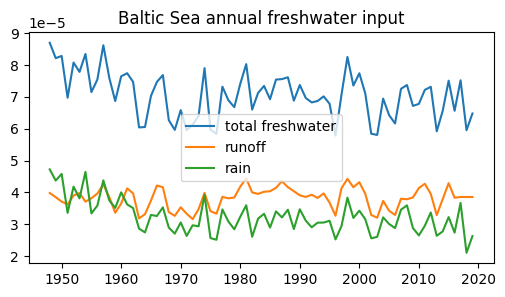

In [6]:
'''Compute annual freshwater input as sum of rain and runoff, data from forcing fields (only needed once, ca. 20min)'''

###### Rain
# area_weights_rain = area_weights.rename({'yh': 'lat', 'xh': 'lon'})
# rain_ts = []
# for year in range(1948, 2020):    
#     print(f"Processing {year}")
#     rain = xr.open_dataset(f"../../iow/database/meteo/coastDat-3_COSMO-CLM/{year}/rain.mom.dta.nc")['rain']
#     if 'area_weights_rain_interp' not in locals():
#         area_weights_rain_interp = area_weights_rain.interp(lat=rain.lat, lon=rain.lon, method='nearest')
#     rain = rain.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
#     rain = rain.sel(lon=slice(8.12, 29.72), lat=slice(53.64, 65.76))
#     rain_mean = rain.mean(dim='time')
#     rain_sum = (rain_mean * area_weights_rain_interp).sum(dim=['lat', 'lon'])
#     rain_sum = rain_sum.expand_dims(time=[np.datetime64(f"{year}-01-01", "ns")])
#     rain_ts.append(rain_sum)
# rain_ts = xr.concat(rain_ts, dim='time').chunk({'time': -1})
# rain_ts.to_netcdf("supplemental_data/rain_full_BS.nc")
ds_rain = xr.open_dataarray(f"supplemental_data/rain_full_BS.nc")

###### Runoff
# River runoff timeseries
# Use area weights kg/m**2/s, then sum along xh&yh -> compatible with rain data although different gird, just add the two
# runoff_ts = []
# for year in range(1948,2020):
#     runoff = xr.open_dataset(f"../../iow/database/RIVER/level-2/reconstruction-1850-2000/8nm/RiverDat_CDOM_V05/{year}/runoff.nc", decode_times=False)
#     runoff = runoff['runoff'].isel(time=slice(1,13)).mean(dim='time').rename({'lon': 'xh', 'lat': 'yh'})
#     area_weights_runoff = area_weights.interp(xh=runoff.xh, yh=runoff.yh, method='nearest')
#     runoff = (runoff * area_weights_runoff).sum(dim=['xh','yh']).expand_dims(time=[np.datetime64(f"{year}-01-01", "ns")])
#     runoff_ts.append(runoff)
# runoff_ts = xr.concat(runoff_ts, dim='time')
# runoff_ts.to_netcdf("supplemental_data/runoff_full_BS.nc")
ds_runoff = xr.open_dataarray(f"supplemental_data/runoff_full_BS.nc")

# freshwater_ts = rain_ts + runoff_ts
# freshwater_ts.to_netcdf("supplemental_data/freshwater_full_BS.nc")
ds_freshwater = xr.open_dataarray(f"supplemental_data/freshwater_full_BS.nc")

plt.figure(figsize=(6,3))
plt.plot(ds_freshwater.time, ds_freshwater, label='total freshwater')
plt.plot(ds_runoff.time, ds_runoff, label='runoff')
plt.plot(ds_rain.time, ds_rain, label='rain')
plt.legend()
plt.title('Baltic Sea annual freshwater input');

ds_freshwater_past_1y  = ds_freshwater.shift(time=1)                                 # compute previous 1y mean
ds_freshwater_past_3y  = ds_freshwater_past_1y.rolling(time=3, center=False).mean()  # compute previous 3y mean
ds_freshwater_past_5y  = ds_freshwater_past_1y.rolling(time=5, center=False).mean()  # compute previous 5y mean
ds_freshwater_past_7y  = ds_freshwater_past_1y.rolling(time=7, center=False).mean()  # compute previous 7y mean
ds_freshwater_past_10y = ds_freshwater_past_1y.rolling(time=10, center=False).mean() # compute previous 10y mean
ds_freshwater_future_1y  = ds_freshwater.copy()                                                # ds_freshwater hold future 1y mean value
ds_freshwater_future_3y  = ds_freshwater.rolling(time=3, center=False).mean().shift(time=-2)   # compute future 3y mean
ds_freshwater_future_5y  = ds_freshwater.rolling(time=5, center=False).mean().shift(time=-4)   # compute future 5y mean
ds_freshwater_future_7y  = ds_freshwater.rolling(time=7, center=False).mean().shift(time=-6)   # compute future 7y mean
ds_freshwater_future_10y = ds_freshwater.rolling(time=10, center=False).mean().shift(time=-9)  # compute future 9y mean
ds_freshwater_past_and_future_1y  = ds_freshwater.rolling(time=2, center=True).mean()   # mean over past and future 1y
ds_freshwater_past_and_future_3y  = ds_freshwater.rolling(time=6, center=True).mean()   # mean over past and future 3y
ds_freshwater_past_and_future_5y  = ds_freshwater.rolling(time=10, center=True).mean()  # mean over past and future 5y
ds_freshwater_past_and_future_7y  = ds_freshwater.rolling(time=14, center=True).mean()  # mean over past and future 7y
ds_freshwater_past_and_future_10y = ds_freshwater.rolling(time=20, center=True).mean()  # mean over past and future 10y

## II. EY specific calculations

In [7]:
'''List of all ensemble start years'''
ensemble_years = [1951, 1956, 1961, 1966, 1971, 1976, 1981, 1986, 1991, 1996, 2001, 2006, 2011]

#### Refrun & initial field

In [8]:
'''Get 10y refrun slices for each EY'''

''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Import initial conditions from initial field MOM_res.nc'''
# Compute initial conditions of SSS, SSH, SST
# Initial ice vars not given in ice_model.res.nc
# Initial heat and salt already included in the ds
initial_fields, initial_fields_full_BS, initial_fields_Arkona, initial_fields_Gotland, initial_fields_Bothnian = {},{},{},{},{}
for EY in ensemble_years:
    initial_fields[EY] = xr.open_mfdataset(
        f"../ensemble_{str(EY)[-2:]}/initial_field/MOM.res.nc", 
        decode_times=False
    )
    initial_fields[EY] = initial_fields[EY][['Temp', 'Salt', 'sfc']].rename({'lath': 'yh', 'lonh': 'xh'}).isel(Time=0)
    initial_fields_full_BS[EY] = (initial_fields[EY].isel(Layer=0) * area_weights).sum(dim=["xh","yh"])  # average over BS
    initial_fields_Arkona[EY] = (initial_fields[EY].isel(Layer=0) * arkona_weights).sum(dim=["xh","yh"])  # average over Arkona Basin
    initial_fields_Gotland[EY] = (initial_fields[EY].isel(Layer=0) * gotland_weights).sum(dim=["xh","yh"])  # average over Gotland Sea
    initial_fields_Bothnian[EY] = (initial_fields[EY].isel(Layer=0) * bothnian_weights).sum(dim=["xh","yh"])  # average over Bothnian Bay

''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

'''Get initial field specific refruns data'''
# Import reference run data, select values along time coordinate, and add initial values
refruns_ssh_full_BS, refruns_sst_full_BS, refruns_sss_full_BS, refruns_ice_hi_full_BS, refruns_ice_cn_full_BS, refruns_salt_full_BS, refruns_heat_full_BS = {}, {}, {}, {}, {}, {}, {}
salt_init_full_BS, heat_init_full_BS = {}, {}
refruns_ssh_Arkona, refruns_sst_Arkona, refruns_sss_Arkona, refruns_ice_hi_Arkona, refruns_ice_cn_Arkona, refruns_salt_Arkona, refruns_heat_Arkona = {}, {}, {}, {}, {}, {}, {}
refruns_ssh_Gotland, refruns_sst_Gotland, refruns_sss_Gotland, refruns_ice_hi_Gotland, refruns_ice_cn_Gotland, refruns_salt_Gotland, refruns_heat_Gotland = {}, {}, {}, {}, {}, {}, {}
refruns_ssh_Bothnian, refruns_sst_Bothnian, refruns_sss_Bothnian, refruns_ice_hi_Bothnian, refruns_ice_cn_Bothnian, refruns_salt_Bothnian, refruns_heat_Bothnian = {}, {}, {}, {}, {}, {}, {}


for EY in ensemble_years:
    if EY == 2011:    
        refruns_ssh_Arkona[EY] = refrun_sfc_arkona['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        refruns_ssh_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_Arkona[EY]], dim="leadyear").compute()
        refruns_sss_Arkona[EY] = refrun_sfc_arkona['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        refruns_sss_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_Arkona[EY]], dim="leadyear").compute()
        refruns_sst_Arkona[EY] = refrun_sfc_arkona['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        # refruns_sst_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_Arkona[EY]], dim="leadyear").compute()

        refruns_ssh_Gotland[EY] = refrun_sfc_gotland['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10))
        refruns_ssh_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_Gotland[EY]], dim="leadyear").compute()
        refruns_sss_Gotland[EY] = refrun_sfc_gotland['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10))
        refruns_sss_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_Gotland[EY]], dim="leadyear").compute()
        refruns_sst_Gotland[EY] = refrun_sfc_gotland['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10))
        # refruns_sst_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_Gotland[EY]], dim="leadyear").compute()

        refruns_ssh_Bothnian[EY] = refrun_sfc_bothnian['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10))
        refruns_ssh_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_Bothnian[EY]], dim="leadyear").compute()
        refruns_sss_Bothnian[EY] = refrun_sfc_bothnian['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10))
        refruns_sss_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_Bothnian[EY]], dim="leadyear").compute()
        refruns_sst_Bothnian[EY] = refrun_sfc_bothnian['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10))
        # refruns_sst_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_Bothnian[EY]], dim="leadyear").compute()

        refruns_ssh_full_BS[EY] = refrun_ssh_full_BS['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        refruns_ssh_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_full_BS[EY]], dim="leadyear").compute()
        refruns_sst_full_BS[EY] = refrun_sst_full_BS['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        # refruns_sst_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_full_BS[EY]], dim="leadyear").compute()
        refruns_sss_full_BS[EY] = refrun_sss_full_BS['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        refruns_sss_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_full_BS[EY]], dim="leadyear").compute()
        
        refruns_ice_hi_Arkona[EY] = refrun_ice_arkona.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10)).compute()
        refruns_ice_cn_Arkona[EY] = refrun_ice_arkona.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10)).compute()
        refruns_ice_cn_Arkona[EY] = refruns_ice_cn_Arkona[EY].compute()

        refruns_ice_hi_Gotland[EY] = refrun_ice_gotland.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()
        refruns_ice_cn_Gotland[EY] = refrun_ice_gotland.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()
        refruns_ice_cn_Gotland[EY] = refruns_ice_cn_Gotland[EY].compute()

        refruns_ice_hi_Bothnian[EY] = refrun_ice_bothnian.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()
        refruns_ice_cn_Bothnian[EY] = refrun_ice_bothnian.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()
        refruns_ice_cn_Bothnian[EY] = refruns_ice_cn_Bothnian[EY].compute()

        refruns_ice_hi_full_BS[EY] = refrun_ice_hi_full_BS.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10)).compute()
        refruns_ice_cn_full_BS[EY] = refrun_ice_cn_full_BS.sel(time=slice(f"{EY}-01", f"{EY+8}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10)).compute()
        refruns_ice_cn_full_BS[EY] = refruns_ice_cn_full_BS[EY].compute()

        refruns_salt_Arkona[EY] = refrun_salt_arkona.sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16"))['salt']
        refruns_salt_Arkona[EY] = refruns_salt_Arkona[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10)).compute()
        refruns_heat_Arkona[EY] = refrun_heat_arkona.sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16"))['temp']
        refruns_heat_Arkona[EY] = refruns_heat_Arkona[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10)).compute()

        refruns_salt_Gotland[EY] = refrun_salt_gotland.sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16"))['salt']
        refruns_salt_Gotland[EY] = refruns_salt_Gotland[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()
        refruns_heat_Gotland[EY] = refrun_heat_gotland.sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16"))['temp']
        refruns_heat_Gotland[EY] = refruns_heat_Gotland[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()

        refruns_salt_Bothnian[EY] = refrun_salt_bothnian.sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16"))['salt']
        refruns_salt_Bothnian[EY] = refruns_salt_Bothnian[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()
        refruns_heat_Bothnian[EY] = refrun_heat_bothnian.sel(time=slice(f"{EY}-01-16", f"{EY+8}-12-16"))['temp']
        refruns_heat_Bothnian[EY] = refruns_heat_Bothnian[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 10)).compute()

        refruns_salt_full_BS[EY] = refrun_salt_full_BS.sel(time=slice(f"{EY}-01-01", f"{EY+8}-12-31"))['Salt']
        # salt_init_full_BS[EY]    = refruns_salt_full_BS[EY][0].values
        refruns_salt_full_BS[EY] = refruns_salt_full_BS[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        # refruns_salt_full_BS[EY] = xr.DataArray(np.insert(refruns_salt_full_BS[EY].values, 0, salt_init_full_BS[EY]), coords=[np.insert(refruns_salt_full_BS[EY].leadyear.values, 0, 0)], dims=['year'])
        refruns_salt_full_BS[EY] = refruns_salt_full_BS[EY].compute()

        refruns_heat_full_BS[EY] = refrun_heat_full_BS.sel(time=slice(f"{EY}-01-01", f"{EY+8}-12-31"))['Heat']
        # heat_init_full_BS[EY]    = refruns_heat_full_BS[EY][0].values
        refruns_heat_full_BS[EY] = refruns_heat_full_BS[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,10))
        # refruns_heat_full_BS[EY] = xr.DataArray(np.insert(refruns_heat_full_BS[EY].values, 0, heat_init_full_BS[EY]), coords=[np.insert(refruns_heat_full_BS[EY].leadyear.values, 0, 0)], dims=['year'])
        refruns_heat_full_BS[EY] = refruns_heat_full_BS[EY].compute()

    else:    
        refruns_ssh_Arkona[EY] = refrun_sfc_arkona['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        refruns_ssh_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_Arkona[EY]], dim="leadyear").compute()
        refruns_sss_Arkona[EY] = refrun_sfc_arkona['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        refruns_sss_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_Arkona[EY]], dim="leadyear").compute()
        refruns_sst_Arkona[EY] = refrun_sfc_arkona['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        # refruns_sst_Arkona[EY] = xr.concat([xr.DataArray(data=[initial_fields_Arkona[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_Arkona[EY]], dim="leadyear").compute()

        refruns_ssh_Gotland[EY] = refrun_sfc_gotland['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11))
        refruns_ssh_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_Gotland[EY]], dim="leadyear").compute()
        refruns_sss_Gotland[EY] = refrun_sfc_gotland['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11))
        refruns_sss_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_Gotland[EY]], dim="leadyear").compute()
        refruns_sst_Gotland[EY] = refrun_sfc_gotland['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11))
        # refruns_sst_Gotland[EY] = xr.concat([xr.DataArray(data=[initial_fields_Gotland[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_Gotland[EY]], dim="leadyear").compute()

        refruns_ssh_Bothnian[EY] = refrun_sfc_bothnian['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11))
        refruns_ssh_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_Bothnian[EY]], dim="leadyear").compute()
        refruns_sss_Bothnian[EY] = refrun_sfc_bothnian['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11))
        refruns_sss_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_Bothnian[EY]], dim="leadyear").compute()
        refruns_sst_Bothnian[EY] = refrun_sfc_bothnian['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11))
        # refruns_sst_Bothnian[EY] = xr.concat([xr.DataArray(data=[initial_fields_Bothnian[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_Bothnian[EY]], dim="leadyear").compute()

        refruns_ssh_full_BS[EY] = refrun_ssh_full_BS['SSH'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        refruns_ssh_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['sfc'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_ssh_full_BS[EY]], dim="leadyear").compute()
        refruns_sst_full_BS[EY] = refrun_sst_full_BS['SST'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        # refruns_sst_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['Temp'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sst_full_BS[EY]], dim="leadyear").compute()
        refruns_sss_full_BS[EY] = refrun_sss_full_BS['SSS'].sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16")).resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        refruns_sss_full_BS[EY] = xr.concat([xr.DataArray(data=[initial_fields_full_BS[EY]['Salt'].values], coords={"leadyear": [0]}, dims=("leadyear",)), refruns_sss_full_BS[EY]], dim="leadyear").compute()
        
        refruns_ice_hi_Arkona[EY] = refrun_ice_arkona.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11)).compute()
        refruns_ice_cn_Arkona[EY] = refrun_ice_arkona.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11)).compute()
        refruns_ice_cn_Arkona[EY] = refruns_ice_cn_Arkona[EY].compute()

        refruns_ice_hi_Gotland[EY] = refrun_ice_gotland.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()
        refruns_ice_cn_Gotland[EY] = refrun_ice_gotland.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()
        refruns_ice_cn_Gotland[EY] = refruns_ice_cn_Gotland[EY].compute()

        refruns_ice_hi_Bothnian[EY] = refrun_ice_bothnian.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()
        refruns_ice_cn_Bothnian[EY] = refrun_ice_bothnian.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()
        refruns_ice_cn_Bothnian[EY] = refruns_ice_cn_Bothnian[EY].compute()

        refruns_ice_hi_full_BS[EY] = refrun_ice_hi_full_BS.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['HI'].resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11)).compute()
        refruns_ice_cn_full_BS[EY] = refrun_ice_cn_full_BS.sel(time=slice(f"{EY}-01", f"{EY+9}-12"))['CN'].sum(dim='ct').resample(time='YS').max().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11)).compute()
        refruns_ice_cn_full_BS[EY] = refruns_ice_cn_full_BS[EY].compute()

        refruns_salt_Arkona[EY] = refrun_salt_arkona.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['salt']
        refruns_salt_Arkona[EY] = refruns_salt_Arkona[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11)).compute()
        refruns_heat_Arkona[EY] = refrun_heat_arkona.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['temp']
        refruns_heat_Arkona[EY] = refruns_heat_Arkona[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11)).compute()

        refruns_salt_Gotland[EY] = refrun_salt_gotland.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['salt']
        refruns_salt_Gotland[EY] = refruns_salt_Gotland[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()
        refruns_heat_Gotland[EY] = refrun_heat_gotland.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['temp']
        refruns_heat_Gotland[EY] = refruns_heat_Gotland[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()

        refruns_salt_Bothnian[EY] = refrun_salt_bothnian.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['salt']
        refruns_salt_Bothnian[EY] = refruns_salt_Bothnian[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()
        refruns_heat_Bothnian[EY] = refrun_heat_bothnian.sel(time=slice(f"{EY}-01-16", f"{EY+9}-12-16"))['temp']
        refruns_heat_Bothnian[EY] = refruns_heat_Bothnian[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1, 11)).compute()

        refruns_salt_full_BS[EY] = refrun_salt_full_BS.sel(time=slice(f"{EY}-01-01", f"{EY+9}-12-31"))['Salt']
        # salt_init_full_BS[EY]    = refruns_salt_full_BS[EY][0].values
        refruns_salt_full_BS[EY] = refruns_salt_full_BS[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        # refruns_salt_full_BS[EY] = xr.DataArray(np.insert(refruns_salt_full_BS[EY].values, 0, salt_init_full_BS[EY]), coords=[np.insert(refruns_salt_full_BS[EY].leadyear.values, 0, 0)], dims=['year'])
        refruns_salt_full_BS[EY] = refruns_salt_full_BS[EY].compute()

        refruns_heat_full_BS[EY] = refrun_heat_full_BS.sel(time=slice(f"{EY}-01-01", f"{EY+9}-12-31"))['Heat']
        # heat_init_full_BS[EY]    = refruns_heat_full_BS[EY][0].values
        refruns_heat_full_BS[EY] = refruns_heat_full_BS[EY].resample(time='YS').mean().rename({"time": "leadyear"}).assign_coords(leadyear=range(1,11))
        # refruns_heat_full_BS[EY] = xr.DataArray(np.insert(refruns_heat_full_BS[EY].values, 0, heat_init_full_BS[EY]), coords=[np.insert(refruns_heat_full_BS[EY].leadyear.values, 0, 0)], dims=['year'])
        refruns_heat_full_BS[EY] = refruns_heat_full_BS[EY].compute()

#### Import the data

In [9]:
'''Read in ensemble data'''
ds_sst_full_BS    = xr.open_dataset(f"ensemble_data/full_BS/full_SST_full_BS.nc")
ds_sst_full_BS    = ds_sst_full_BS['SST'].assign_coords(leadyear=((ds_sst_full_BS.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_sss_full_BS    = xr.open_dataset(f"ensemble_data/full_BS/full_SSS_full_BS.nc")
ds_sss_full_BS    = ds_sss_full_BS['SSS'].assign_coords(leadyear=((ds_sss_full_BS.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ssh_full_BS    = xr.open_dataset(f"ensemble_data/full_BS/full_SSH_full_BS.nc")
ds_ssh_full_BS    = ds_ssh_full_BS['SSH'].assign_coords(leadyear=((ds_ssh_full_BS.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_salt_full_BS   = xr.open_dataset(f"ensemble_data/full_BS/full_salt_full_BS.nc")
ds_salt_full_BS   = ds_salt_full_BS['Salt'].assign_coords(leadyear=((ds_salt_full_BS.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_heat_full_BS   = xr.open_dataset(f"ensemble_data/full_BS/full_heat_full_BS.nc")
ds_heat_full_BS   = ds_heat_full_BS['Heat'].assign_coords(leadyear=((ds_heat_full_BS.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ice_cn_full_BS = xr.open_dataset(f"ensemble_data/full_BS/full_ice_cn_full_BS.nc")
ds_ice_cn_full_BS = ds_ice_cn_full_BS['CN'].assign_coords(leadyear=((ds_ice_cn_full_BS.month-1)//12 + 1)).groupby("leadyear").max(dim='month')
ds_ice_hi_full_BS = xr.open_dataset(f"ensemble_data/full_BS/full_ice_hi_full_BS.nc")
ds_ice_hi_full_BS = ds_ice_hi_full_BS['HI'].assign_coords(leadyear=((ds_ice_hi_full_BS.month-1)//12 + 1)).groupby("leadyear").max(dim='month')

ds_sst_Arkona    = xr.open_dataset(f"ensemble_data/Arkona/full_SST_Arkona.nc")
ds_sst_Arkona    = ds_sst_Arkona['SST'].assign_coords(leadyear=((ds_sst_Arkona.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_sss_Arkona    = xr.open_dataset(f"ensemble_data/Arkona/full_SSS_Arkona.nc")
ds_sss_Arkona    = ds_sss_Arkona['SSS'].assign_coords(leadyear=((ds_sss_Arkona.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ssh_Arkona    = xr.open_dataset(f"ensemble_data/Arkona/full_SSH_Arkona.nc")
ds_ssh_Arkona    = ds_ssh_Arkona['SSH'].assign_coords(leadyear=((ds_ssh_Arkona.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_salt_Arkona   = xr.open_dataset(f"ensemble_data/Arkona/full_salt_Arkona.nc")
ds_salt_Arkona   = ds_salt_Arkona['Salt'].assign_coords(leadyear=((ds_salt_Arkona.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_heat_Arkona   = xr.open_dataset(f"ensemble_data/Arkona/full_heat_Arkona.nc")
ds_heat_Arkona   = ds_heat_Arkona['Heat'].assign_coords(leadyear=((ds_heat_Arkona.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ice_cn_Arkona = xr.open_dataset(f"ensemble_data/Arkona/full_ice_cn_Arkona.nc")
ds_ice_cn_Arkona = ds_ice_cn_Arkona['CN'].assign_coords(leadyear=((ds_ice_cn_Arkona.month-1)//12 + 1)).groupby("leadyear").max(dim='month')
ds_ice_hi_Arkona = xr.open_dataset(f"ensemble_data/Arkona/full_ice_hi_Arkona.nc")
ds_ice_hi_Arkona = ds_ice_hi_Arkona['HI'].assign_coords(leadyear=((ds_ice_hi_Arkona.month-1)//12 + 1)).groupby("leadyear").max(dim='month')

ds_sst_Gotland    = xr.open_dataset(f"ensemble_data/Gotland/full_SST_Gotland.nc")
ds_sst_Gotland    = ds_sst_Gotland['SST'].assign_coords(leadyear=((ds_sst_Gotland.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_sss_Gotland    = xr.open_dataset(f"ensemble_data/Gotland/full_SSS_Gotland.nc")
ds_sss_Gotland    = ds_sss_Gotland['SSS'].assign_coords(leadyear=((ds_sss_Gotland.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ssh_Gotland    = xr.open_dataset(f"ensemble_data/Gotland/full_SSH_Gotland.nc")
ds_ssh_Gotland    = ds_ssh_Gotland['SSH'].assign_coords(leadyear=((ds_ssh_Gotland.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_salt_Gotland   = xr.open_dataset(f"ensemble_data/Gotland/full_salt_Gotland.nc")
ds_salt_Gotland   = ds_salt_Gotland['Salt'].assign_coords(leadyear=((ds_salt_Gotland.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_heat_Gotland   = xr.open_dataset(f"ensemble_data/Gotland/full_heat_Gotland.nc")
ds_heat_Gotland   = ds_heat_Gotland['Heat'].assign_coords(leadyear=((ds_heat_Gotland.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ice_cn_Gotland = xr.open_dataset(f"ensemble_data/Gotland/full_ice_cn_Gotland.nc")
ds_ice_cn_Gotland = ds_ice_cn_Gotland['CN'].assign_coords(leadyear=((ds_ice_cn_Gotland.month-1)//12 + 1)).groupby("leadyear").max(dim='month')
ds_ice_hi_Gotland = xr.open_dataset(f"ensemble_data/Gotland/full_ice_hi_Gotland.nc")
ds_ice_hi_Gotland = ds_ice_hi_Gotland['HI'].assign_coords(leadyear=((ds_ice_hi_Gotland.month-1)//12 + 1)).groupby("leadyear").max(dim='month')

ds_sst_Bothnian    = xr.open_dataset(f"ensemble_data/Bothnian/full_SST_Bothnian.nc")
ds_sst_Bothnian    = ds_sst_Bothnian['SST'].assign_coords(leadyear=((ds_sst_Bothnian.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_sss_Bothnian    = xr.open_dataset(f"ensemble_data/Bothnian/full_SSS_Bothnian.nc")
ds_sss_Bothnian    = ds_sss_Bothnian['SSS'].assign_coords(leadyear=((ds_sss_Bothnian.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ssh_Bothnian    = xr.open_dataset(f"ensemble_data/Bothnian/full_SSH_Bothnian.nc")
ds_ssh_Bothnian    = ds_ssh_Bothnian['SSH'].assign_coords(leadyear=((ds_ssh_Bothnian.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_salt_Bothnian   = xr.open_dataset(f"ensemble_data/Bothnian/full_salt_Bothnian.nc")
ds_salt_Bothnian   = ds_salt_Bothnian['Salt'].assign_coords(leadyear=((ds_salt_Bothnian.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_heat_Bothnian   = xr.open_dataset(f"ensemble_data/Bothnian/full_heat_Bothnian.nc")
ds_heat_Bothnian   = ds_heat_Bothnian['Heat'].assign_coords(leadyear=((ds_heat_Bothnian.month-1)//12 + 1)).groupby("leadyear").mean(dim='month')
ds_ice_cn_Bothnian = xr.open_dataset(f"ensemble_data/Bothnian/full_ice_cn_Bothnian.nc")
ds_ice_cn_Bothnian = ds_ice_cn_Bothnian['CN'].assign_coords(leadyear=((ds_ice_cn_Bothnian.month-1)//12 + 1)).groupby("leadyear").max(dim='month')
ds_ice_hi_Bothnian = xr.open_dataset(f"ensemble_data/Bothnian/full_ice_hi_Bothnian.nc")
ds_ice_hi_Bothnian = ds_ice_hi_Bothnian['HI'].assign_coords(leadyear=((ds_ice_hi_Bothnian.month-1)//12 + 1)).groupby("leadyear").max(dim='month')

In [10]:
'''Detrend heat&SST''' # for now initial values are not carried over because not needed
# for each EY the trend will be calculated and substracted from refrun and ensemble data
refruns_sst_full_BS_ano, ds_sst_full_BS_ano      = detrend(refruns_sst_full_BS, ds_sst_full_BS.sel(leadyear=slice(1,11)), detrending_method=2)
refruns_heat_full_BS_ano, ds_heat_full_BS_ano    = detrend(refruns_heat_full_BS, ds_heat_full_BS.sel(leadyear=slice(1,11)), detrending_method=2)

refruns_sst_Arkona_ano, ds_sst_Arkona_ano      = detrend(refruns_sst_Arkona, ds_sst_Arkona.sel(leadyear=slice(1,11)), detrending_method=2)
refruns_heat_Arkona_ano, ds_heat_Arkona_ano    = detrend(refruns_heat_Arkona, ds_heat_Arkona.sel(leadyear=slice(1,11)), detrending_method=2)

refruns_sst_Gotland_ano, ds_sst_Gotland_ano       = detrend(refruns_sst_Gotland, ds_sst_Gotland.sel(leadyear=slice(1,11)), detrending_method=2)
refruns_heat_Gotland_ano, ds_heat_Gotland_ano     = detrend(refruns_heat_Gotland, ds_heat_Gotland.sel(leadyear=slice(1,11)), detrending_method=2)

refruns_sst_Bothnian_ano, ds_sst_Bothnian_ano       = detrend(refruns_sst_Bothnian, ds_sst_Bothnian.sel(leadyear=slice(1,11)), detrending_method=2)
refruns_heat_Bothnian_ano, ds_heat_Bothnian_ano     = detrend(refruns_heat_Bothnian, ds_heat_Bothnian.sel(leadyear=slice(1,11)), detrending_method=2)

### Skill Data Full BS

In [11]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["5y", "6y", "7y", "8y", "9y", "10y", "6-10y", "5-10y", "4-10y", "3-10y", "2-10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt", "Init. Heat", "Init. SSS", "Init. SSH", "Init. SST",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                      "Ensemble mean"
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_full_BS, refruns_salt_full_BS), ("Heat", ds_heat_full_BS_ano, refruns_heat_full_BS_ano), ("SSS", ds_sss_full_BS, refruns_sss_full_BS), ("SSH", ds_ssh_full_BS, refruns_ssh_full_BS), ("SST", ds_sst_full_BS_ano, refruns_sst_full_BS_ano), ("Ice CN", ds_ice_cn_full_BS, refruns_ice_cn_full_BS), ("Ice HI", ds_ice_hi_full_BS, refruns_ice_hi_full_BS)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat", heat_0101_full_BS),("Init. Salt", salt_0101_full_BS),("Init. SSS", sss_0101_full_BS),("Init. SST", sst_0101_full_BS),("Init. SSH", ssh_0101_full_BS),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past 5y Salt full BS", salt_past_5y_full_BS), ("Past 10y Salt full BS", salt_past_10y_full_BS), ("Past 15y Salt full BS", salt_past_15y_full_BS),
    ("Ensemble mean", None)    
    ]


# skill_data_full_BS['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_annual_full_BS   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_annual_full_BS_scores_EY = []
skill_data_annual_full_BS_p_EY = []


# Define file paths
path1 = 'ensemble_data/full_BS/skill_data_annual_full_BS.pkl'
path2 = 'ensemble_data/full_BS/skill_data_annual_full_BS_scores_EY.pkl'
path3 = 'ensemble_data/full_BS/skill_data_annual_full_BS_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_annual_full_BS = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_annual_full_BS_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_annual_full_BS_p_EY = pickle.load(f)

In [12]:
'''Compute CC and MSSS (ca. 15min)'''

for EY in ensemble_years:
    if EY in skill_data_annual_full_BS_scores_EY:
        continue  # skip, already read in
    skill_data_annual_full_BS_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue
                
                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_full_BS list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='full_BS', bootstrap=0)
                skill_data_annual_full_BS['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_annual_full_BS['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_annual_full_BS and years already evaluated
with open('ensemble_data/full_BS/skill_data_annual_full_BS.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_full_BS, f)
with open('ensemble_data/full_BS/skill_data_annual_full_BS_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_full_BS_scores_EY, f)

In [13]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 4h)'''

for EY in ensemble_years:
    if EY in skill_data_annual_full_BS_p_EY:
        continue  # skip, already read in
    skill_data_annual_full_BS_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_full_BS list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='full_BS', bootstrap=1)
                skill_data_annual_full_BS['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_annual_full_BS['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_full_BS and years already evaluated
with open('ensemble_data/full_BS/skill_data_annual_full_BS.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_full_BS, f)
with open('ensemble_data/full_BS/skill_data_annual_full_BS_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_full_BS_p_EY, f)

/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


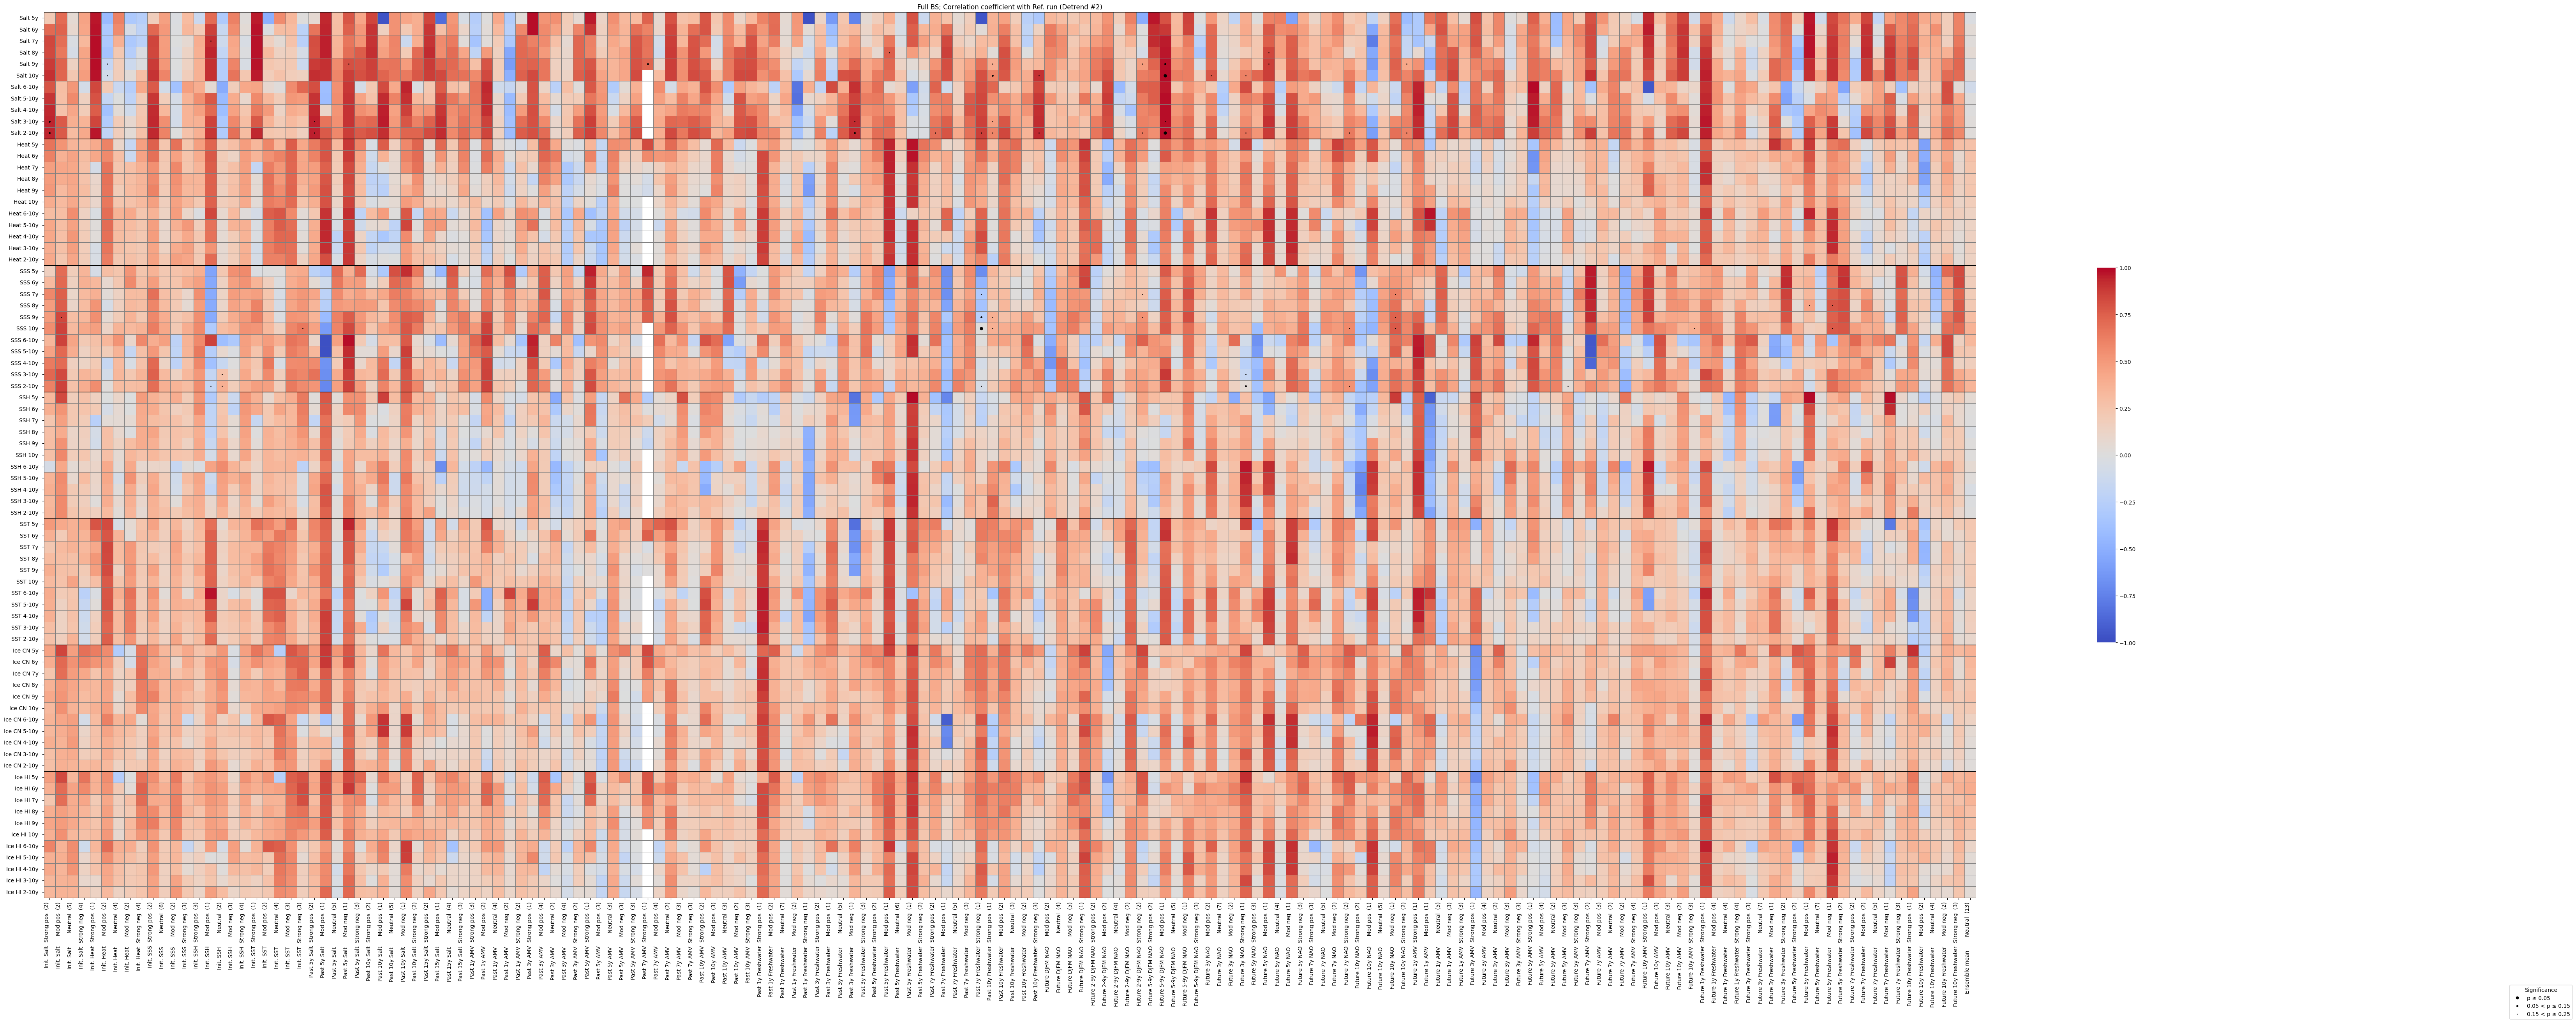

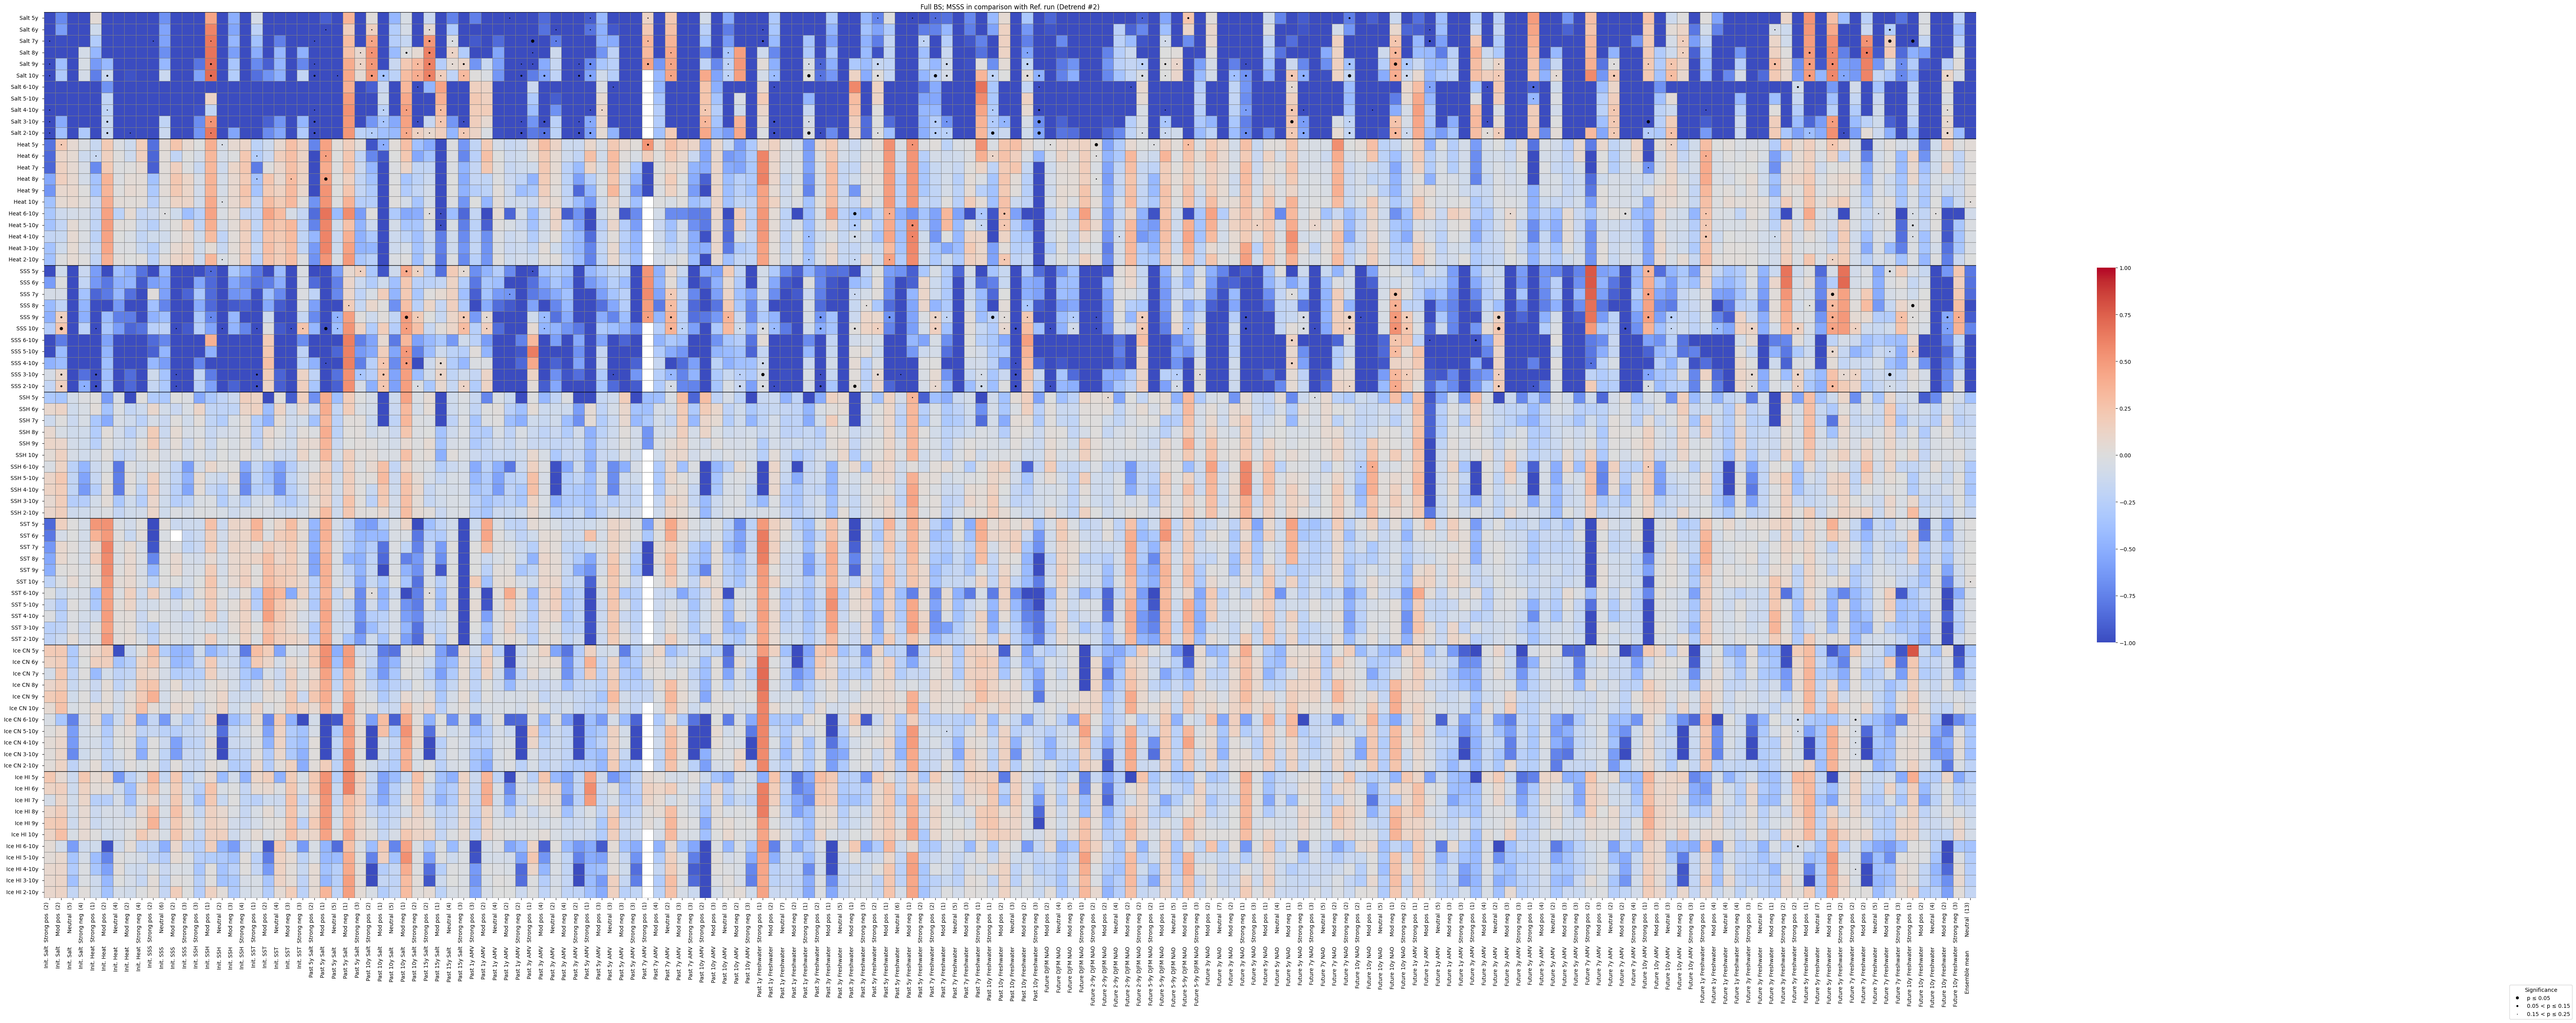

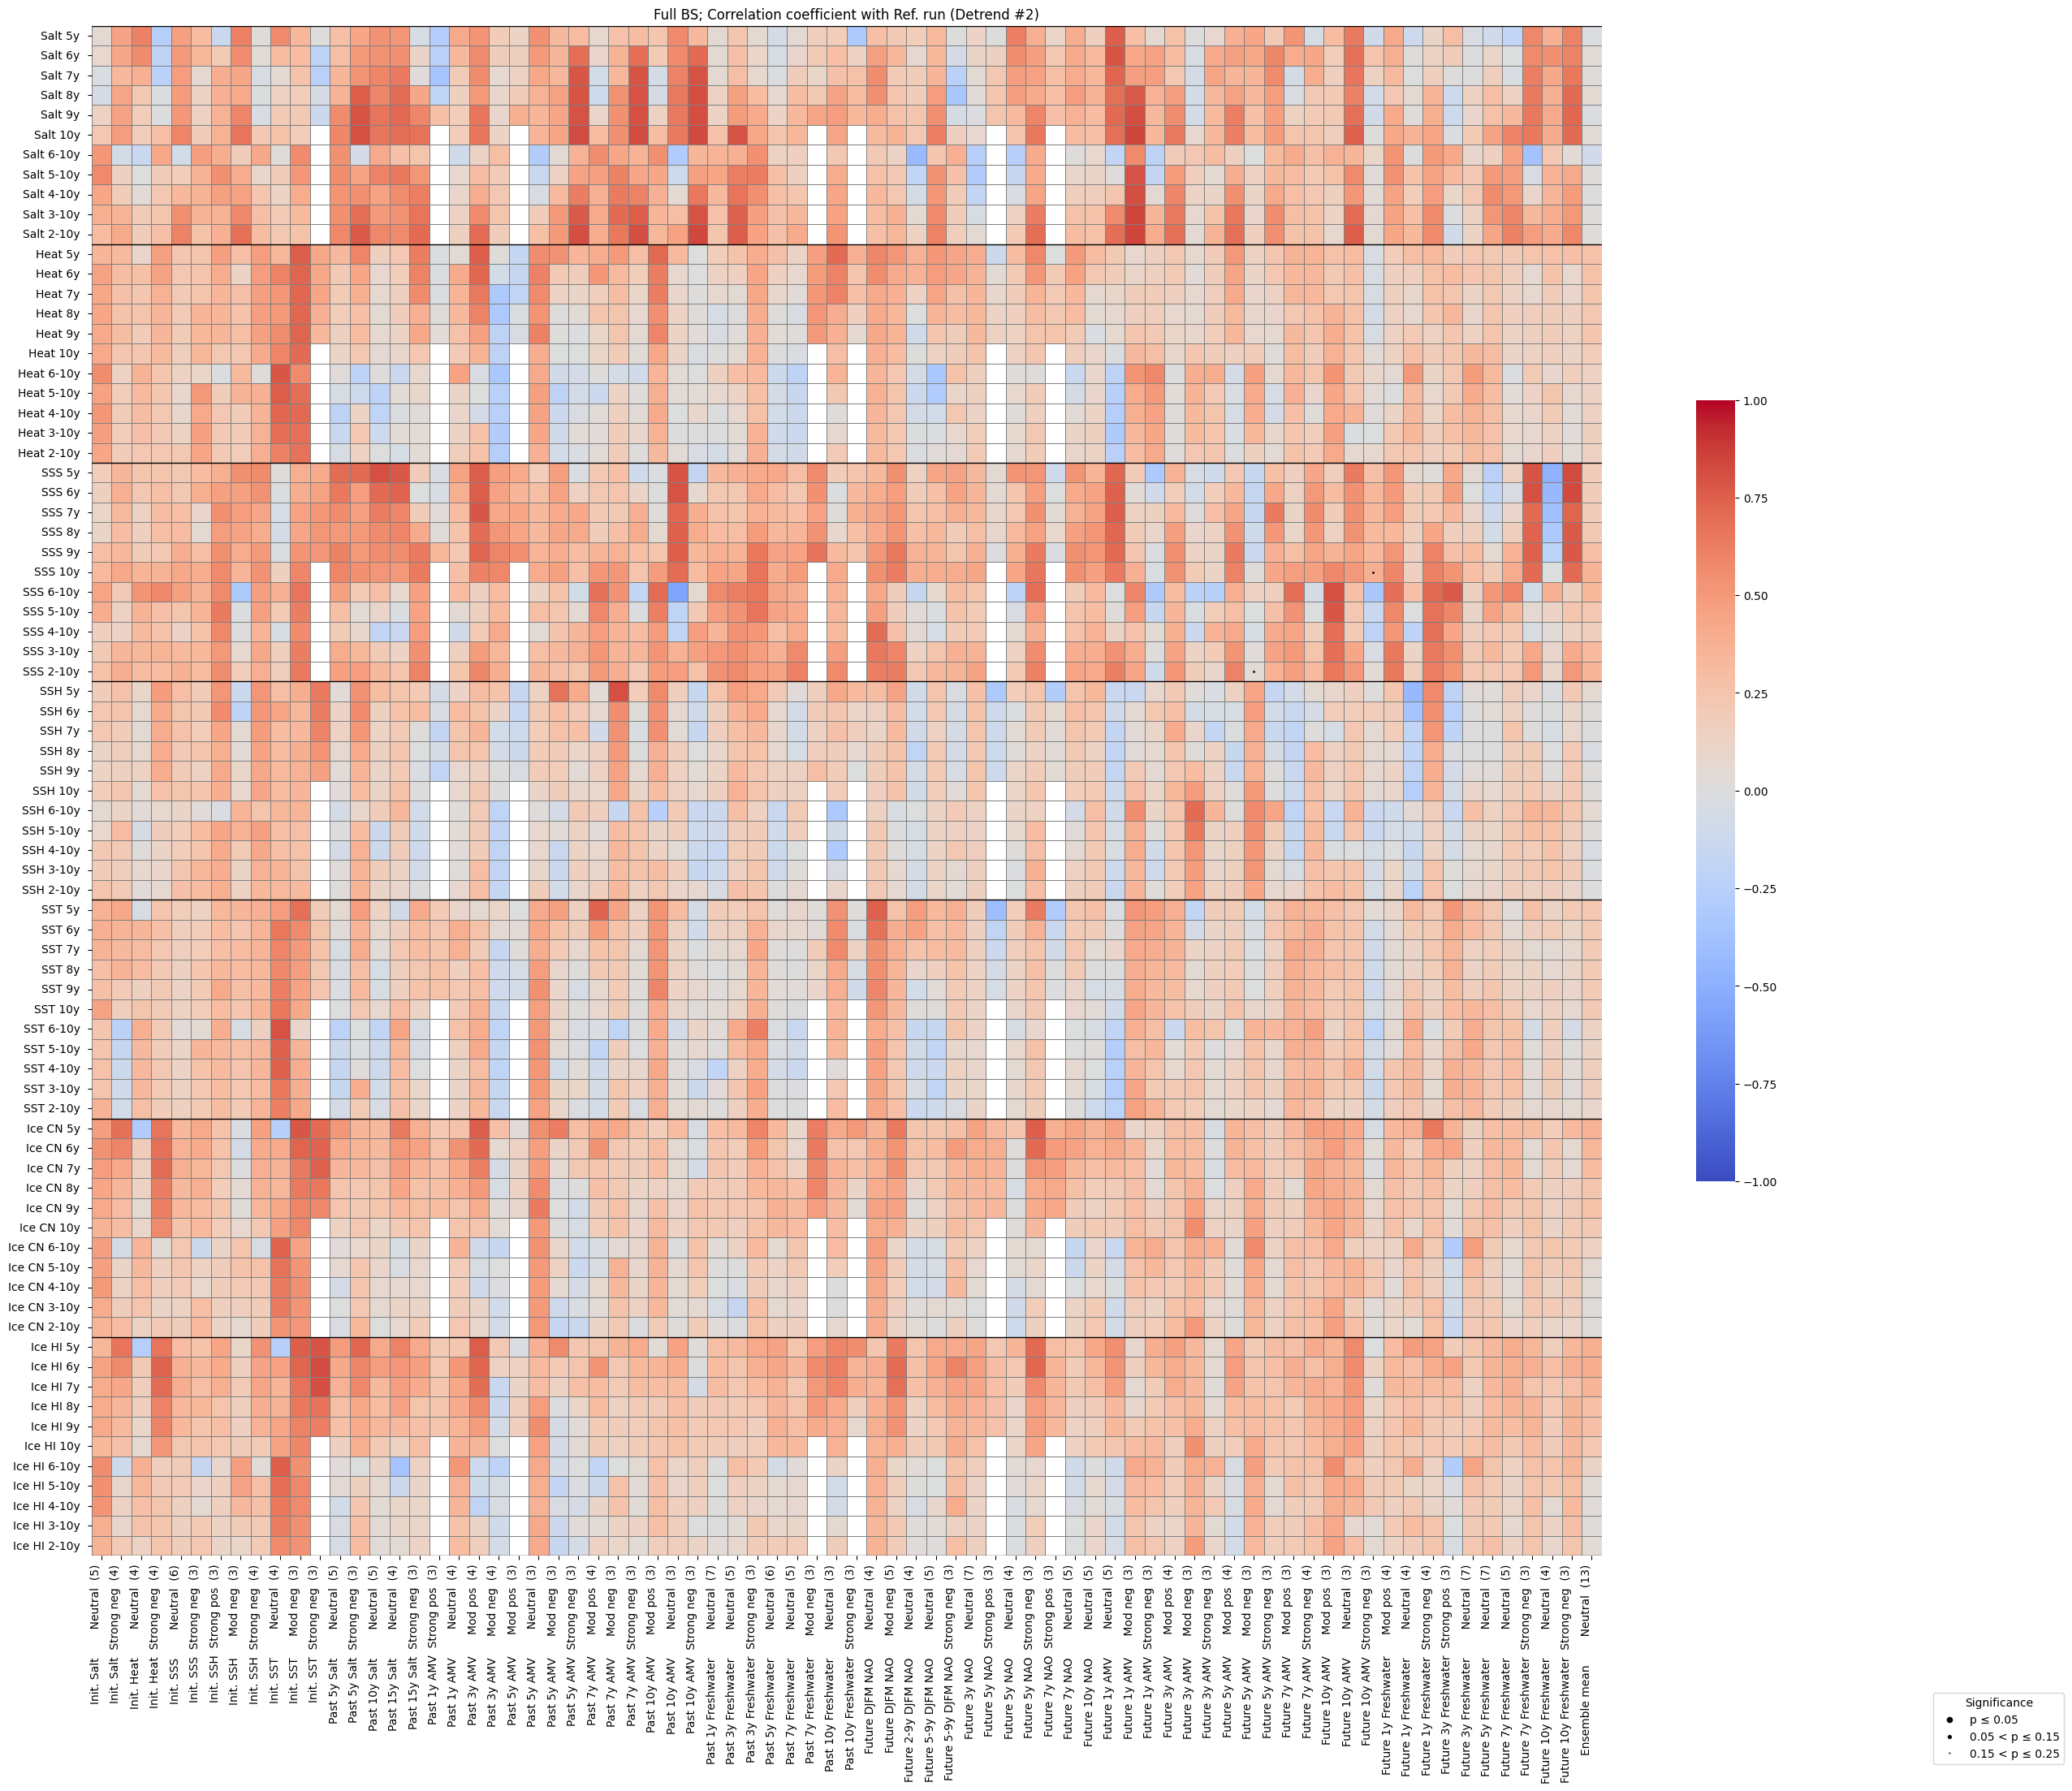

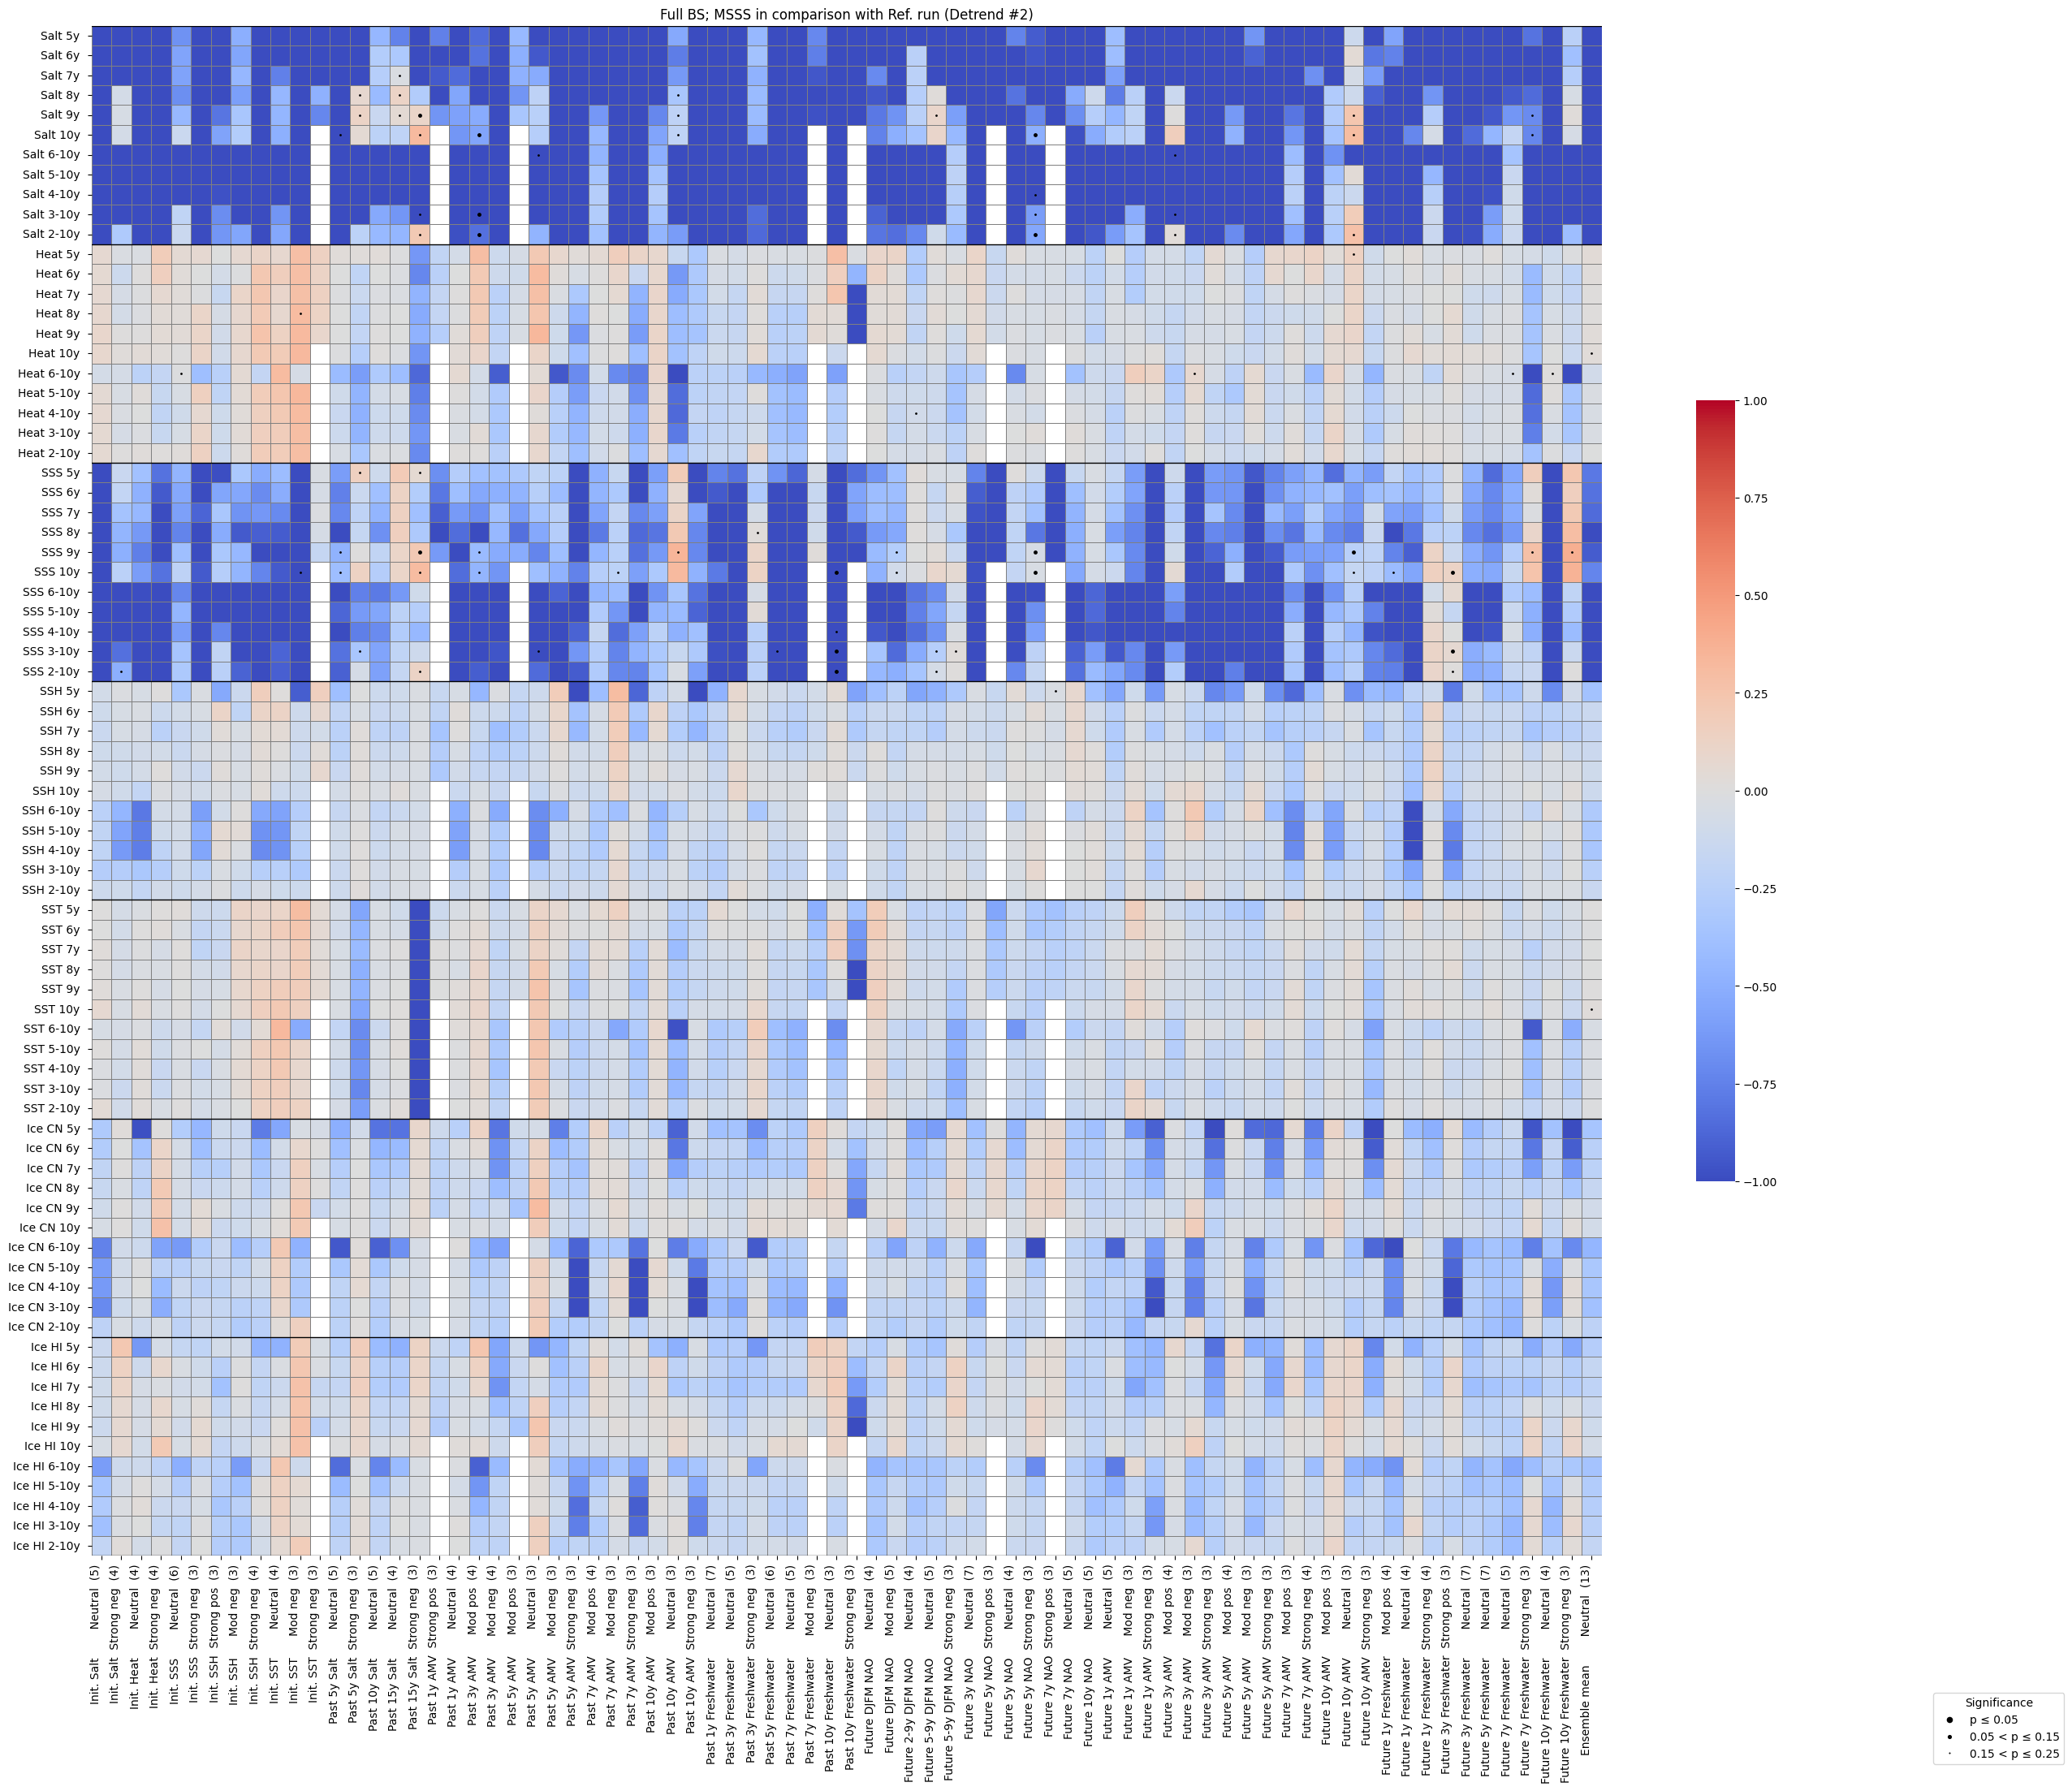

In [14]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize dataframes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_annual_full_BS
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_annual_full_BS['CC'][predictant][timescale][predictor][threshold]), len(skill_data_annual_full_BS['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '5y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '5y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_annual_full_BS['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_annual_full_BS['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_annual_full_BS['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(80,50))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/full_BS_CC1.png", bbox_inches='tight')

plt.figure(figsize=(80,50))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/full_BS_MSSS1.png", bbox_inches='tight')



###### Plot 3 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,50))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/full_BS_CC2.png", bbox_inches='tight')

plt.figure(figsize=(30,50))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Full BS; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/full_BS_MSSS2.png", bbox_inches='tight')

### Skill Data Arkona

In [15]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["5y", "6y", "7y", "8y", "9y", "10y", "6-10y", "5-10y", "4-10y", "3-10y", "2-10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt full BS", "Init. Heat full BS", "Init. SSS full BS", "Init. SSH full BS", "Init. SST full BS",
                      "Init. Salt Arkona", "Init. Heat Arkona", "Init. SSS Arkona", "Init. SSH Arkona", "Init. SST Arkona",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                                                           # init. values at start point of ensemble
                    #   "Past 5y Salt Arkona", "Past 10y Salt Arkona", "Past 15y Salt Arkona",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_Arkona, refruns_salt_Arkona), ("Heat", ds_heat_Arkona_ano, refruns_heat_Arkona_ano), ("SSS", ds_sss_Arkona, refruns_sss_Arkona), ("SSH", ds_ssh_Arkona, refruns_ssh_Arkona), ("SST", ds_sst_Arkona_ano, refruns_sst_Arkona_ano), ("Ice CN", ds_ice_cn_Arkona, refruns_ice_cn_Arkona), ("Ice HI", ds_ice_hi_Arkona, refruns_ice_hi_Arkona)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat full BS", heat_0101_full_BS),("Init. Salt full BS", salt_0101_full_BS),("Init. SSS full BS", sss_0101_full_BS),("Init. SST full BS", sst_0101_full_BS),("Init. SSH full BS", ssh_0101_full_BS),
    ("Init. Heat Arkona", heat_0101_Arkona),("Init. Salt Arkona", salt_0101_Arkona),("Init. SSS Arkona", sss_0101_Arkona),("Init. SST Arkona", sst_0101_Arkona),("Init. SSH Arkona", ssh_0101_Arkona),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past 5y Salt full BS", salt_past_5y_full_BS), ("Past 10y Salt full BS", salt_past_10y_full_BS), ("Past 15y Salt full BS", salt_past_15y_full_BS), 
    # ("Past 5y Salt Arkona", salt_past_5y_arkona), ("Past 10y Salt Arkona", salt_past_10y_arkona), ("Past 15y Salt Arkona", salt_past_15y_arkona) 
    ]


# skill_data_annual_Arkona['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_annual_Arkona   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_annual_Arkona_scores_EY = []
skill_data_annual_Arkona_p_EY = []


# Define file paths
path1 = 'ensemble_data/Arkona/skill_data_annual_Arkona.pkl'
path2 = 'ensemble_data/Arkona/skill_data_annual_Arkona_scores_EY.pkl'
path3 = 'ensemble_data/Arkona/skill_data_annual_Arkona_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_annual_Arkona = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_annual_Arkona_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_annual_Arkona_p_EY = pickle.load(f)

In [16]:
'''Compute CC and MSSS (ca. 15min)'''

for EY in ensemble_years:
    if EY in skill_data_annual_Arkona_scores_EY:
        continue  # skip, already read in
    skill_data_annual_Arkona_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 5y Salt Arkona", "Past 10y Salt Arkona", "Past 15y Salt Arkona"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 10y Salt Arkona", "Past 15y Salt Arkona"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS", "Past 15y Salt Arkona"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_annual_Arkona list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Arkona', bootstrap=0)
                skill_data_annual_Arkona['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_annual_Arkona['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_annual_Arkona and years already evaluated
with open('ensemble_data/Arkona/skill_data_annual_Arkona.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Arkona, f)
with open('ensemble_data/Arkona/skill_data_annual_Arkona_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Arkona_scores_EY, f)

In [17]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 4h)'''

for EY in ensemble_years:
    if EY in skill_data_annual_Arkona_p_EY:
        continue  # skip, already read in
    skill_data_annual_Arkona_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 5y Salt Arkona", "Past 10y Salt Arkona", "Past 15y Salt Arkona"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 10y Salt Arkona", "Past 15y Salt Arkona"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS", "Past 15y Salt Arkona"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_annual_Arkona list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year'), refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Arkona', bootstrap=1)
                skill_data_annual_Arkona['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_annual_Arkona['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_Arkona and years already evaluated
with open('ensemble_data/Arkona/skill_data_annual_Arkona.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Arkona, f)
with open('ensemble_data/Arkona/skill_data_annual_Arkona_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Arkona_p_EY, f)

/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


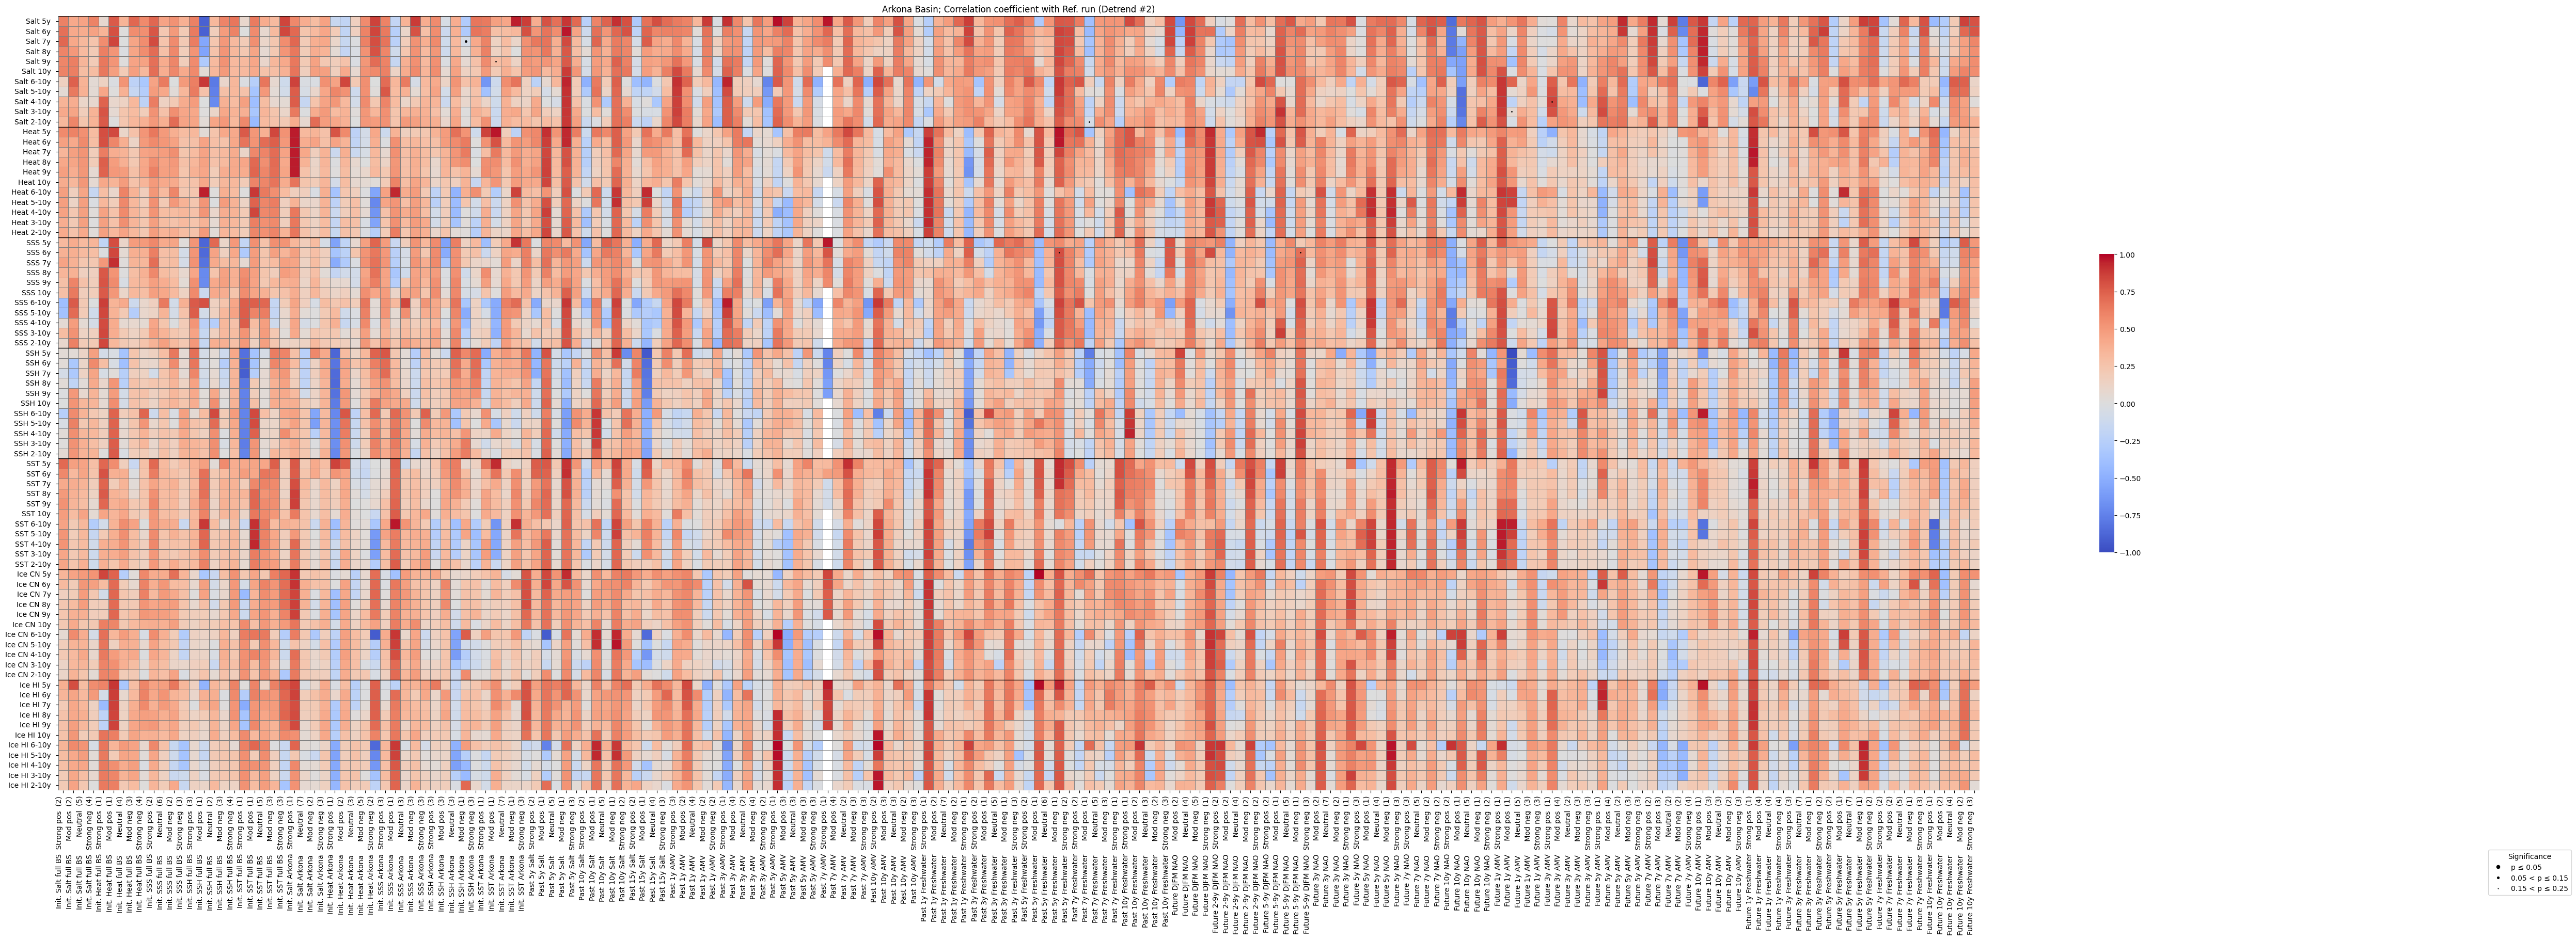

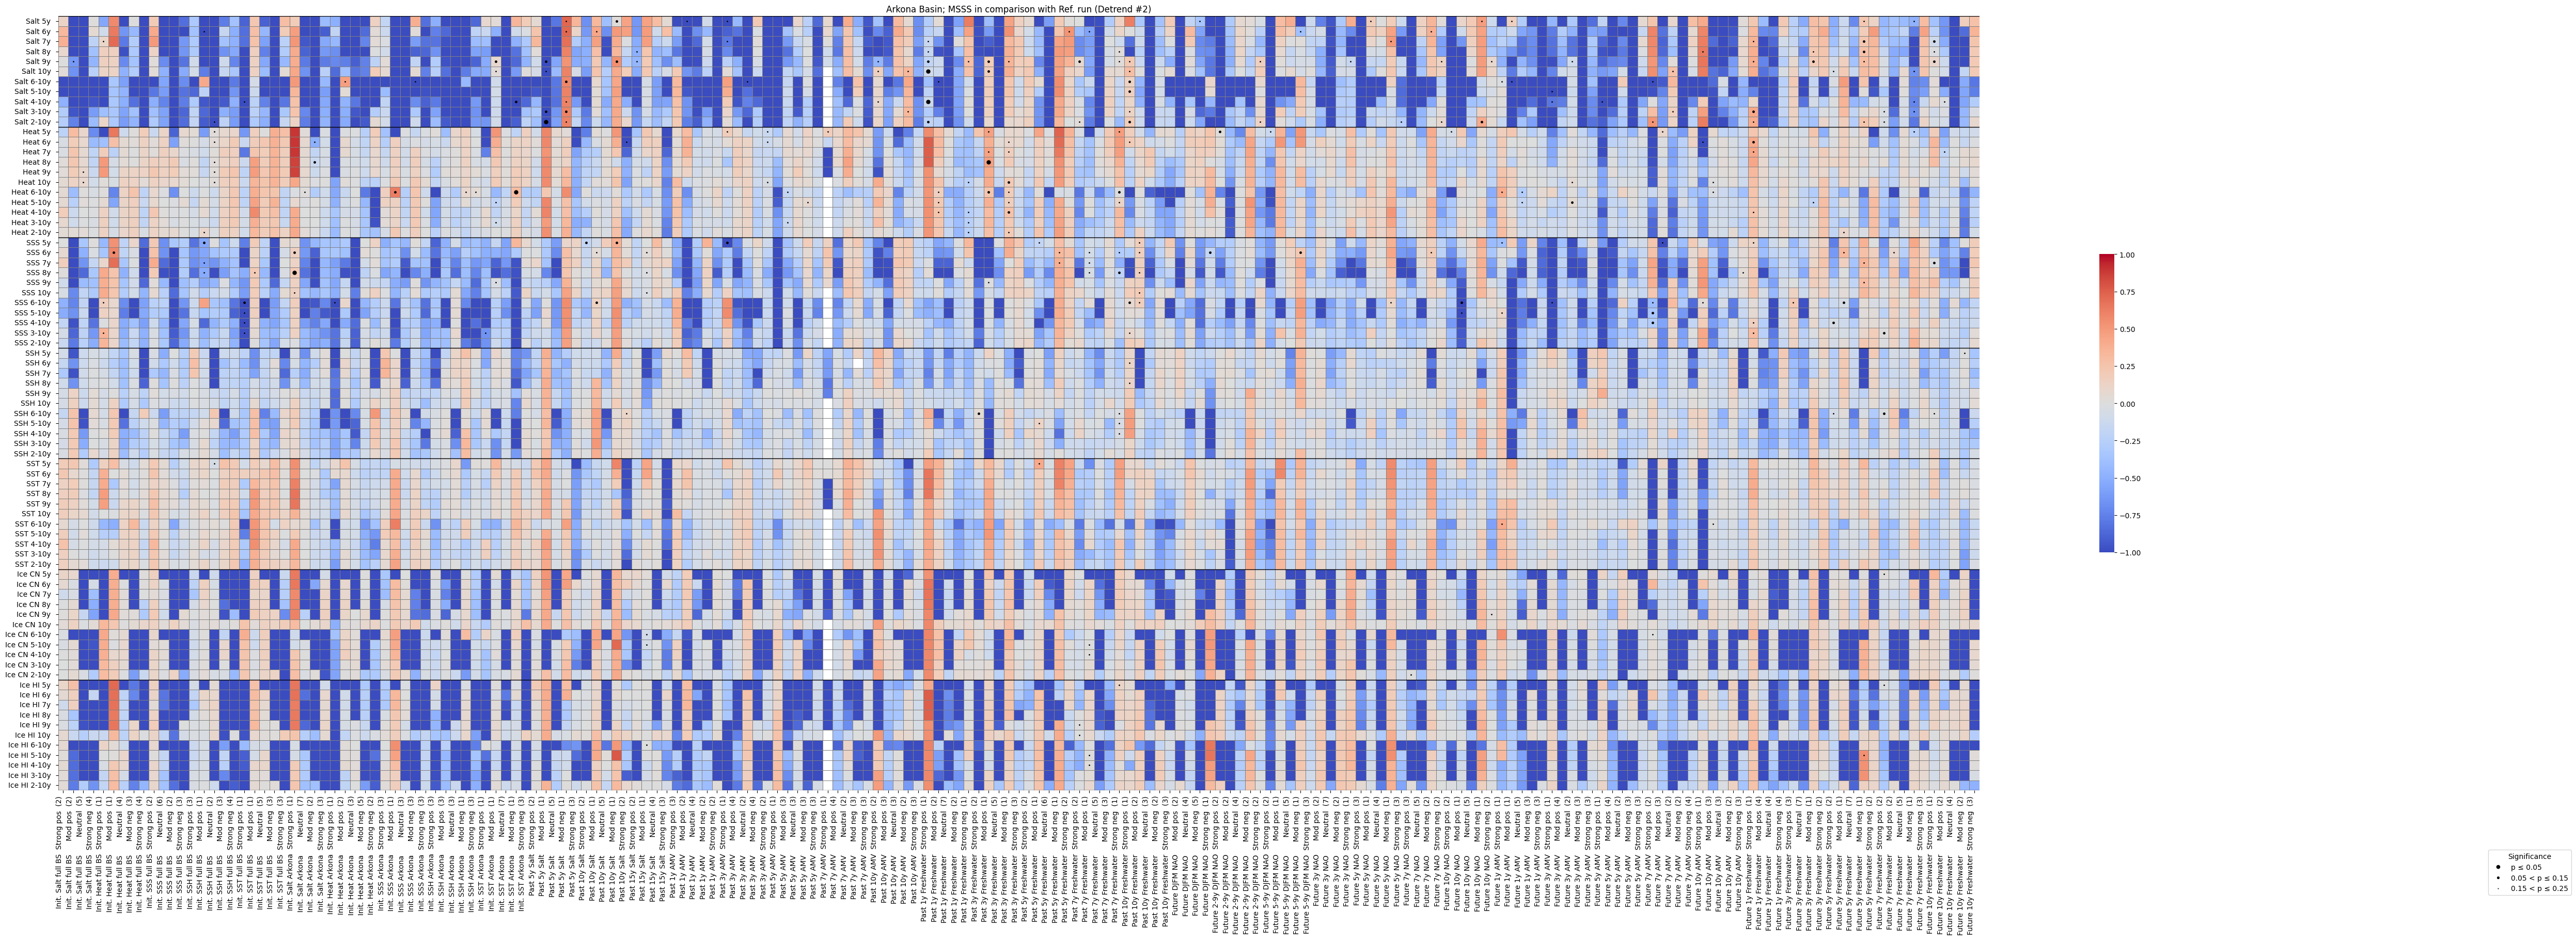

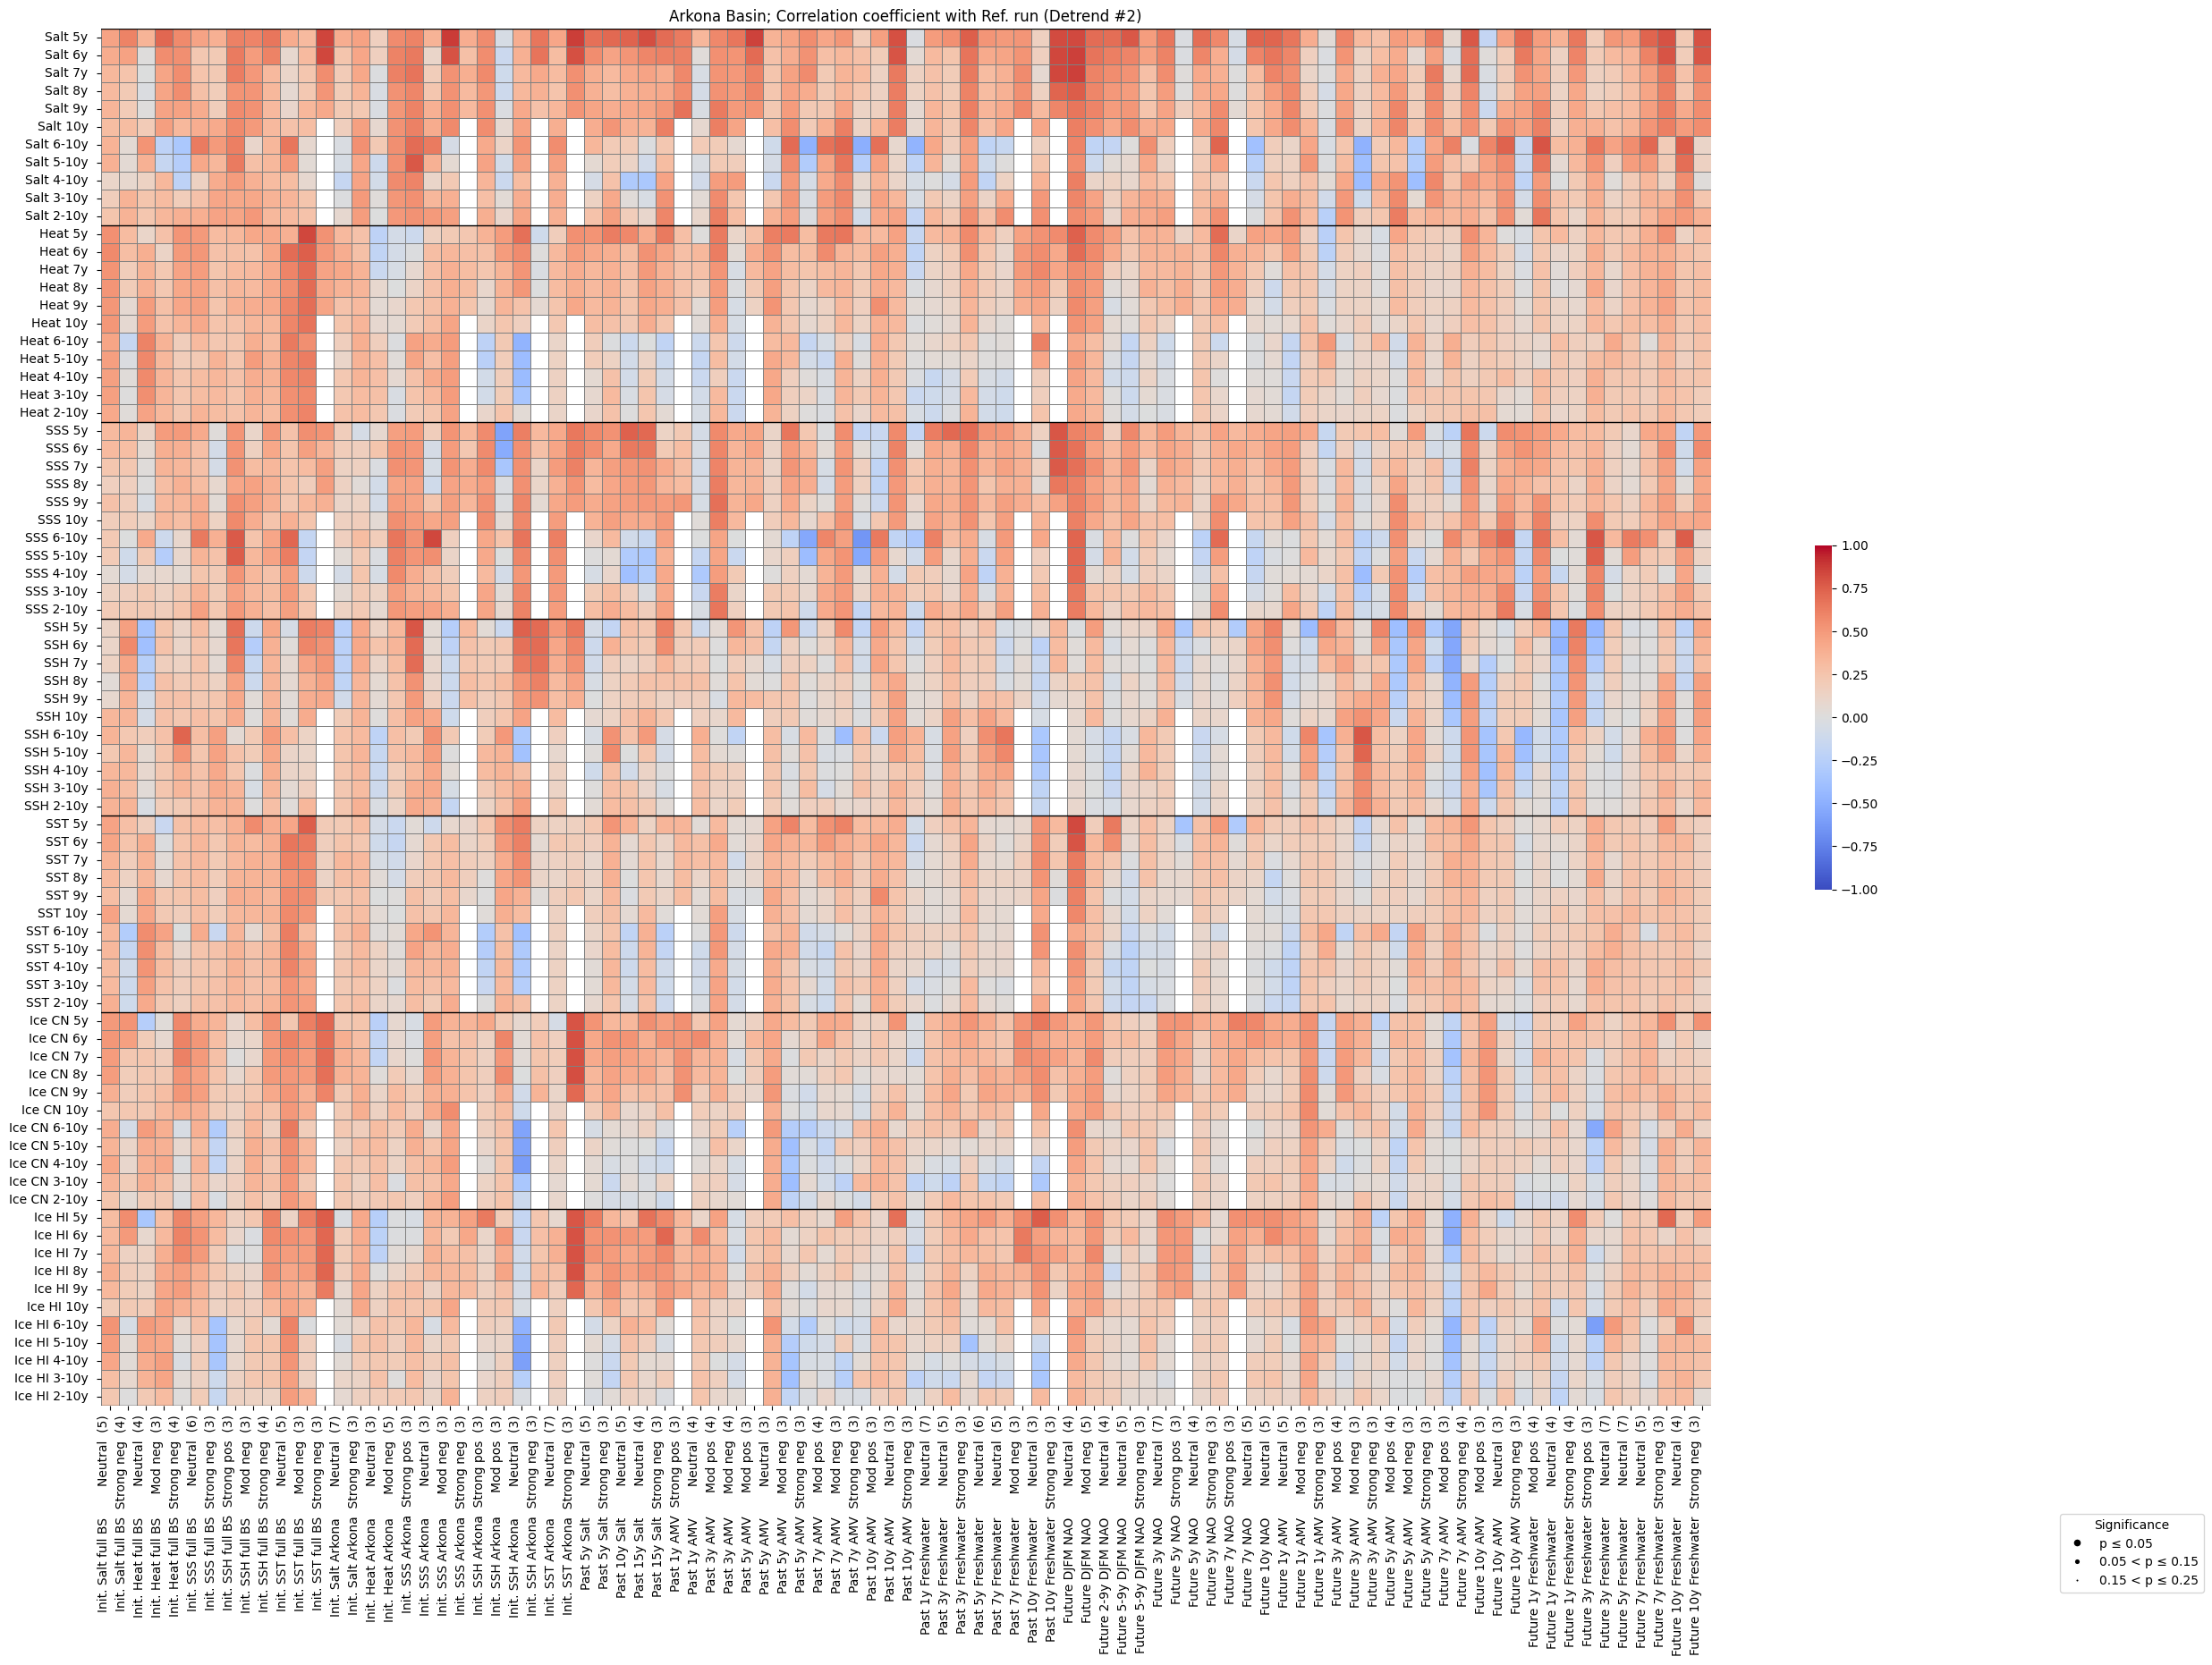

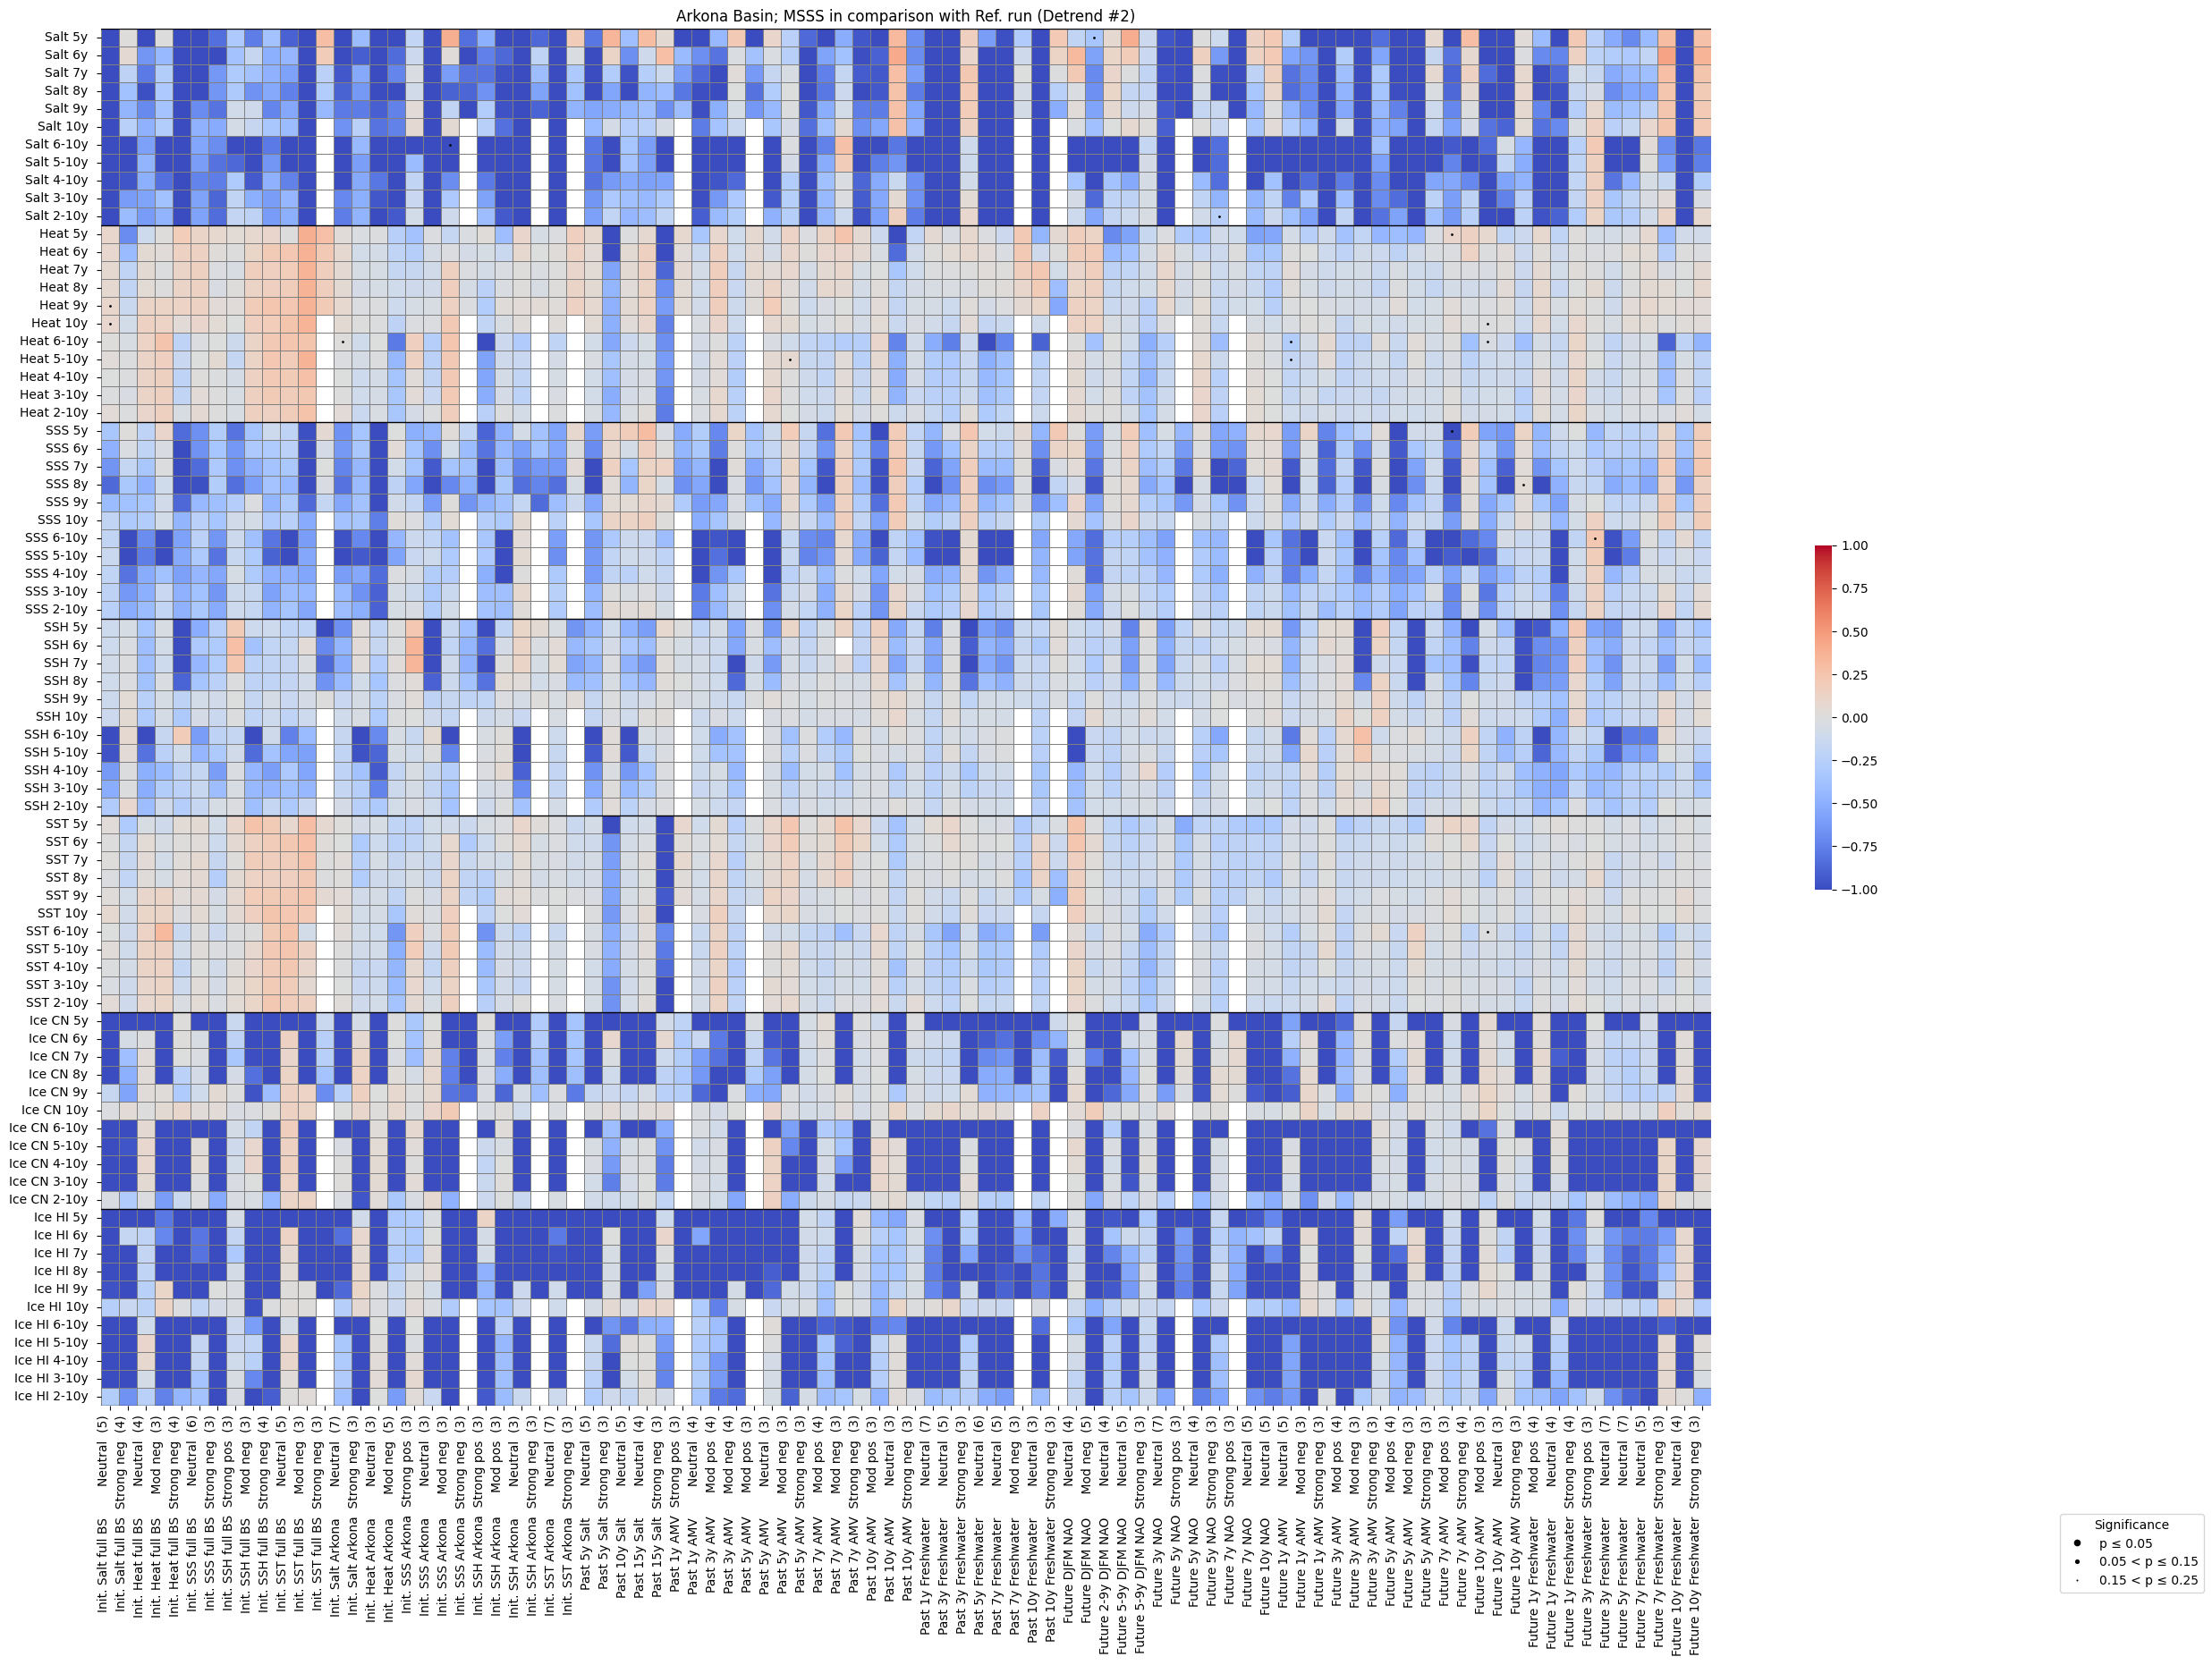

In [18]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_annual_Arkona
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_annual_Arkona['CC'][predictant][timescale][predictor][threshold]), len(skill_data_annual_Arkona['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '5y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '5y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_annual_Arkona['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_annual_Arkona['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_annual_Arkona['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(60,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Arkona_CC1.png", bbox_inches='tight')

plt.figure(figsize=(60,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Arkona_MSSS1.png", bbox_inches='tight')



###### Plot 2 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Arkona_CC2.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Arkona Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Arkona_MSSS2.png", bbox_inches='tight')

### Skill Data Gotland

In [19]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["5y", "6y", "7y", "8y", "9y", "10y", "6-10y", "5-10y", "4-10y", "3-10y", "2-10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt full BS", "Init. Heat full BS", "Init. SSS full BS", "Init. SSH full BS", "Init. SST full BS",                                                                                       # init. values at start point of ensemble
                      "Init. Salt Gotland", "Init. Heat Gotland", "Init. SSS Gotland", "Init. SSH Gotland", "Init. SST Gotland",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                                                                # init. values at start point of ensemble
                    #   "Past 5y Salt Gotland", "Past 10y Salt Gotland", "Past 15y Salt Gotland",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_Gotland, refruns_salt_Gotland), ("Heat", ds_heat_Gotland_ano, refruns_heat_Gotland_ano), ("SSS", ds_sss_Gotland, refruns_sss_Gotland), ("SSH", ds_ssh_Gotland, refruns_ssh_Gotland), ("SST", ds_sst_Gotland_ano, refruns_sst_Gotland_ano), ("Ice CN", ds_ice_cn_Gotland, refruns_ice_cn_Gotland), ("Ice HI", ds_ice_hi_Gotland, refruns_ice_hi_Gotland)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat full BS", heat_0101_full_BS),("Init. Salt full BS", salt_0101_full_BS),("Init. SSS full BS", sss_0101_full_BS),("Init. SST full BS", sst_0101_full_BS),("Init. SSH full BS", ssh_0101_full_BS),
    ("Init. Heat Gotland", heat_0101_Gotland),("Init. Salt Gotland", salt_0101_Gotland),("Init. SSS Gotland", sss_0101_Gotland),("Init. SST Gotland", sst_0101_Gotland),("Init. SSH Gotland", ssh_0101_Gotland),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past 5y Salt full BS", salt_past_5y_full_BS), ("Past 10y Salt full BS", salt_past_10y_full_BS), ("Past 15y Salt full BS", salt_past_15y_full_BS), 
    ("Past 5y Salt Gotland", salt_past_5y_gotland), ("Past 10y Salt Gotland", salt_past_10y_gotland), ("Past 15y Salt Gotland", salt_past_15y_gotland) 
    ]


# skill_data_annual_Gotland['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_annual_Gotland   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_annual_Gotland_scores_EY = []
skill_data_annual_Gotland_p_EY = []


# Define file paths
path1 = 'ensemble_data/Gotland/skill_data_annual_Gotland.pkl'
path2 = 'ensemble_data/Gotland/skill_data_annual_Gotland_scores_EY.pkl'
path3 = 'ensemble_data/Gotland/skill_data_annual_Gotland_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_annual_Gotland = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_annual_Gotland_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_annual_Gotland_p_EY = pickle.load(f)

In [20]:
'''Compute CC and MSSS (ca. 15min)'''

for EY in ensemble_years:
    if EY in skill_data_annual_Gotland_scores_EY:
        continue  # skip, already read in
    skill_data_annual_Gotland_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 5y Salt Gotland", "Past 10y Salt Gotland", "Past 15y Salt Gotland"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 10y Salt Gotland", "Past 15y Salt Gotland"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS", "Past 15y Salt Gotland"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_Gotland list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Gotland', bootstrap=0)
                skill_data_annual_Gotland['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_annual_Gotland['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_annual_Gotland and years already evaluated
with open('ensemble_data/Gotland/skill_data_annual_Gotland.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Gotland, f)
with open('ensemble_data/Gotland/skill_data_annual_Gotland_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Gotland_scores_EY, f)

In [21]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 2h)'''

for EY in ensemble_years:
    if EY in skill_data_annual_Gotland_p_EY:
        continue  # skip, already read in
    skill_data_annual_Gotland_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 5y Salt Gotland", "Past 10y Salt Gotland", "Past 15y Salt Gotland"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 10y Salt Gotland", "Past 15y Salt Gotland"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS", "Past 15y Salt Gotland"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_annual_Gotland list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Gotland', bootstrap=1)
                skill_data_annual_Gotland['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_annual_Gotland['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_annual_Gotland and years already evaluated
with open('ensemble_data/Gotland/skill_data_annual_Gotland.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Gotland, f)
with open('ensemble_data/Gotland/skill_data_annual_Gotland_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Gotland_p_EY, f)

/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


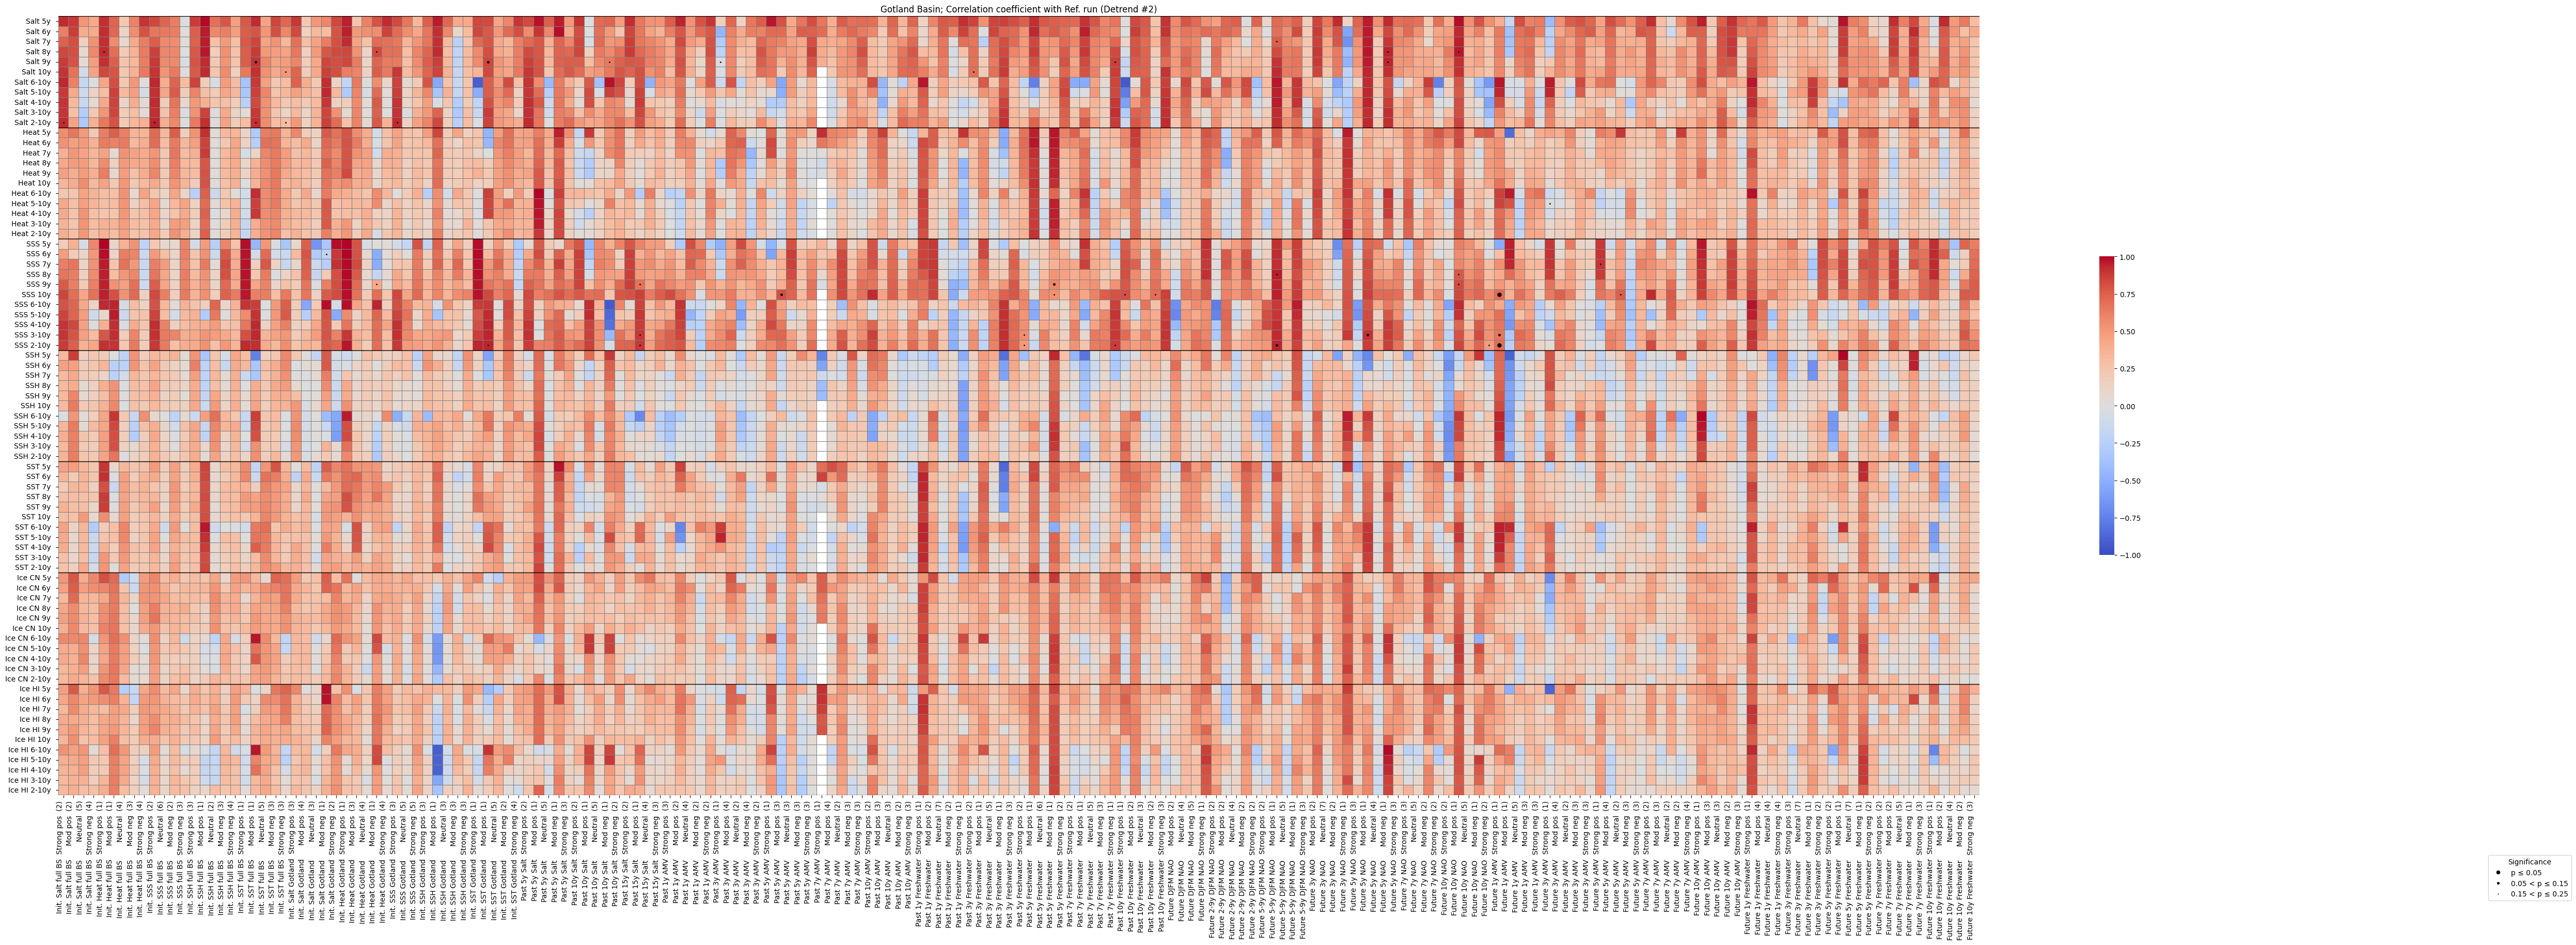

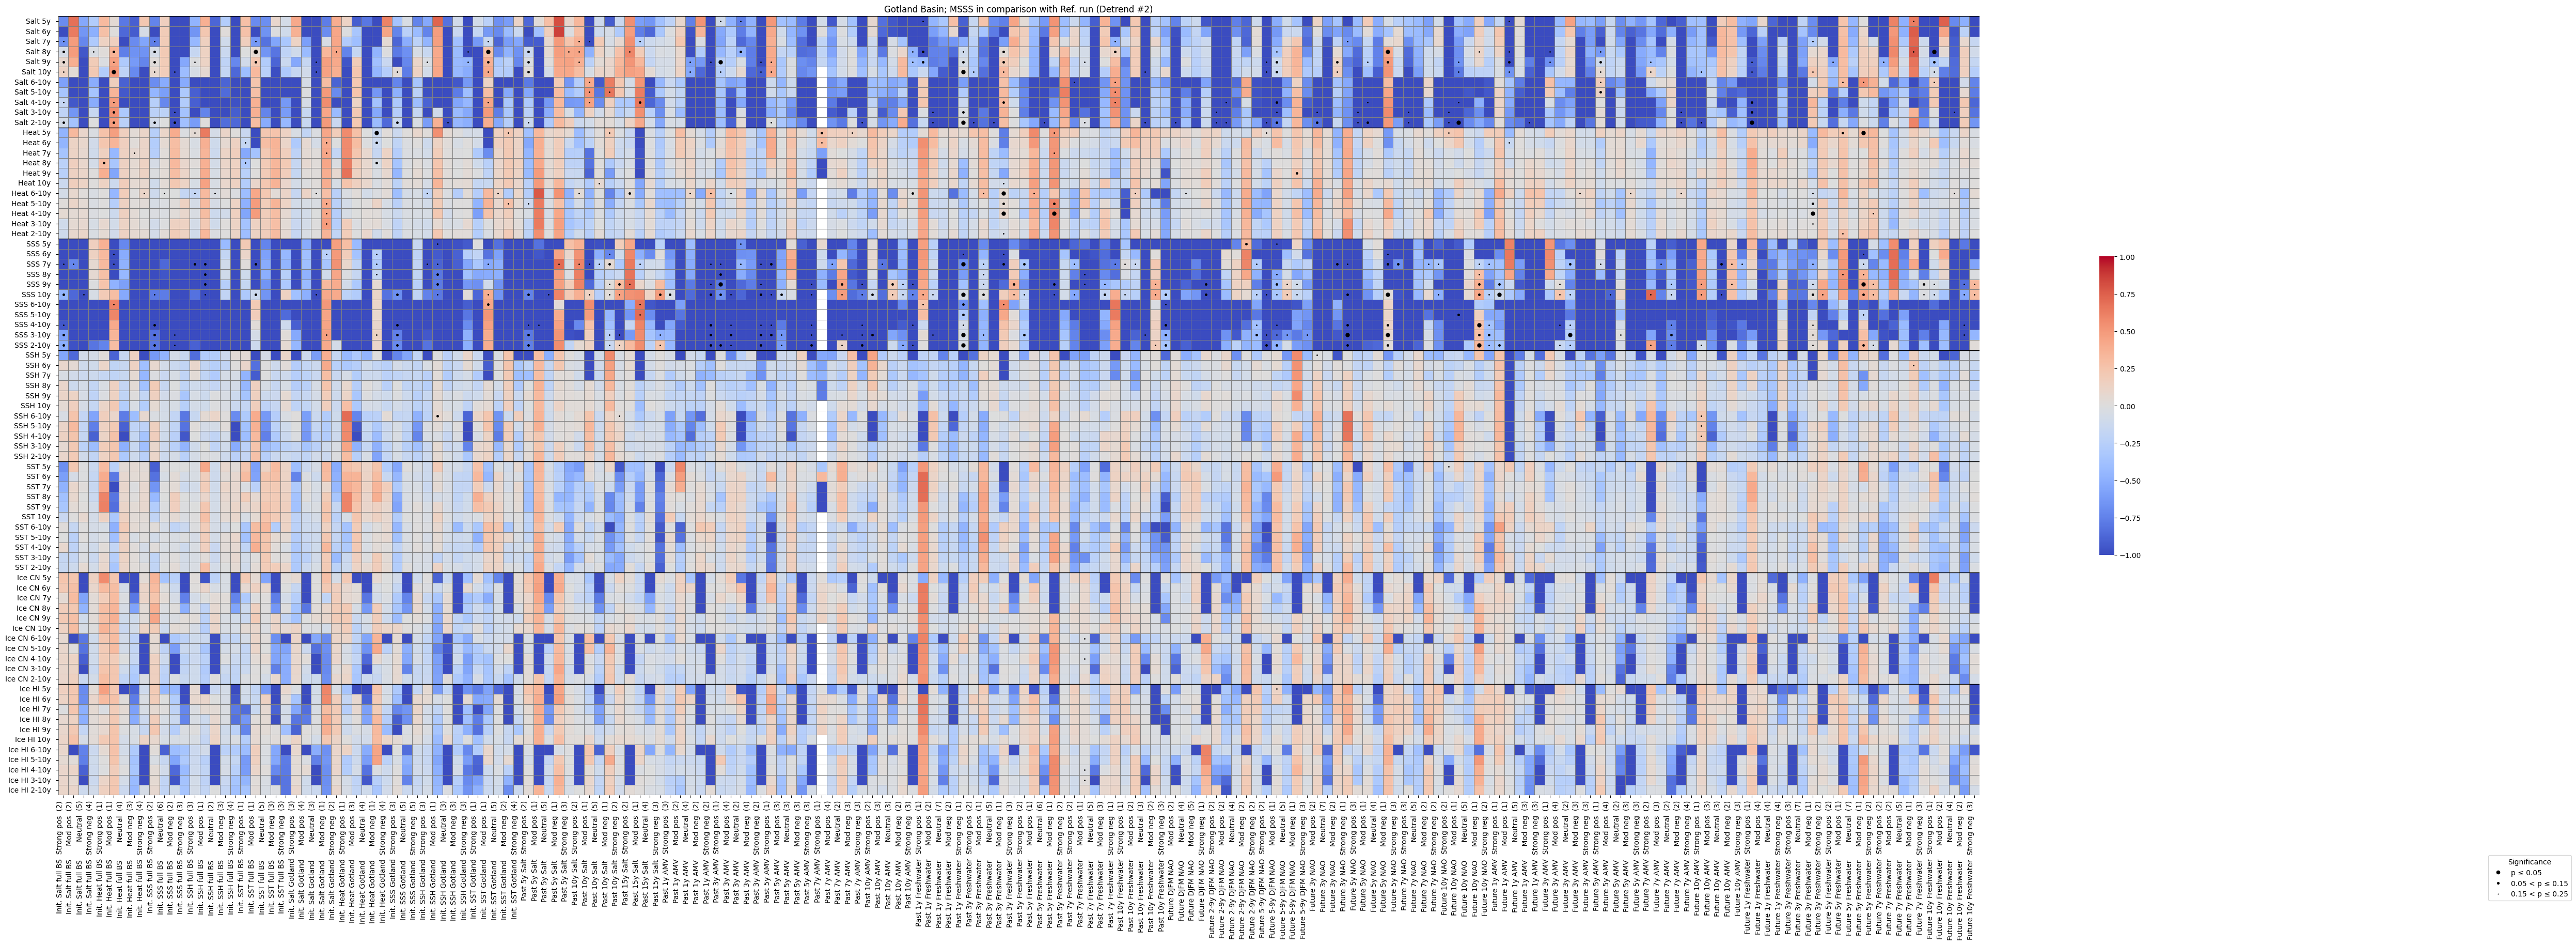

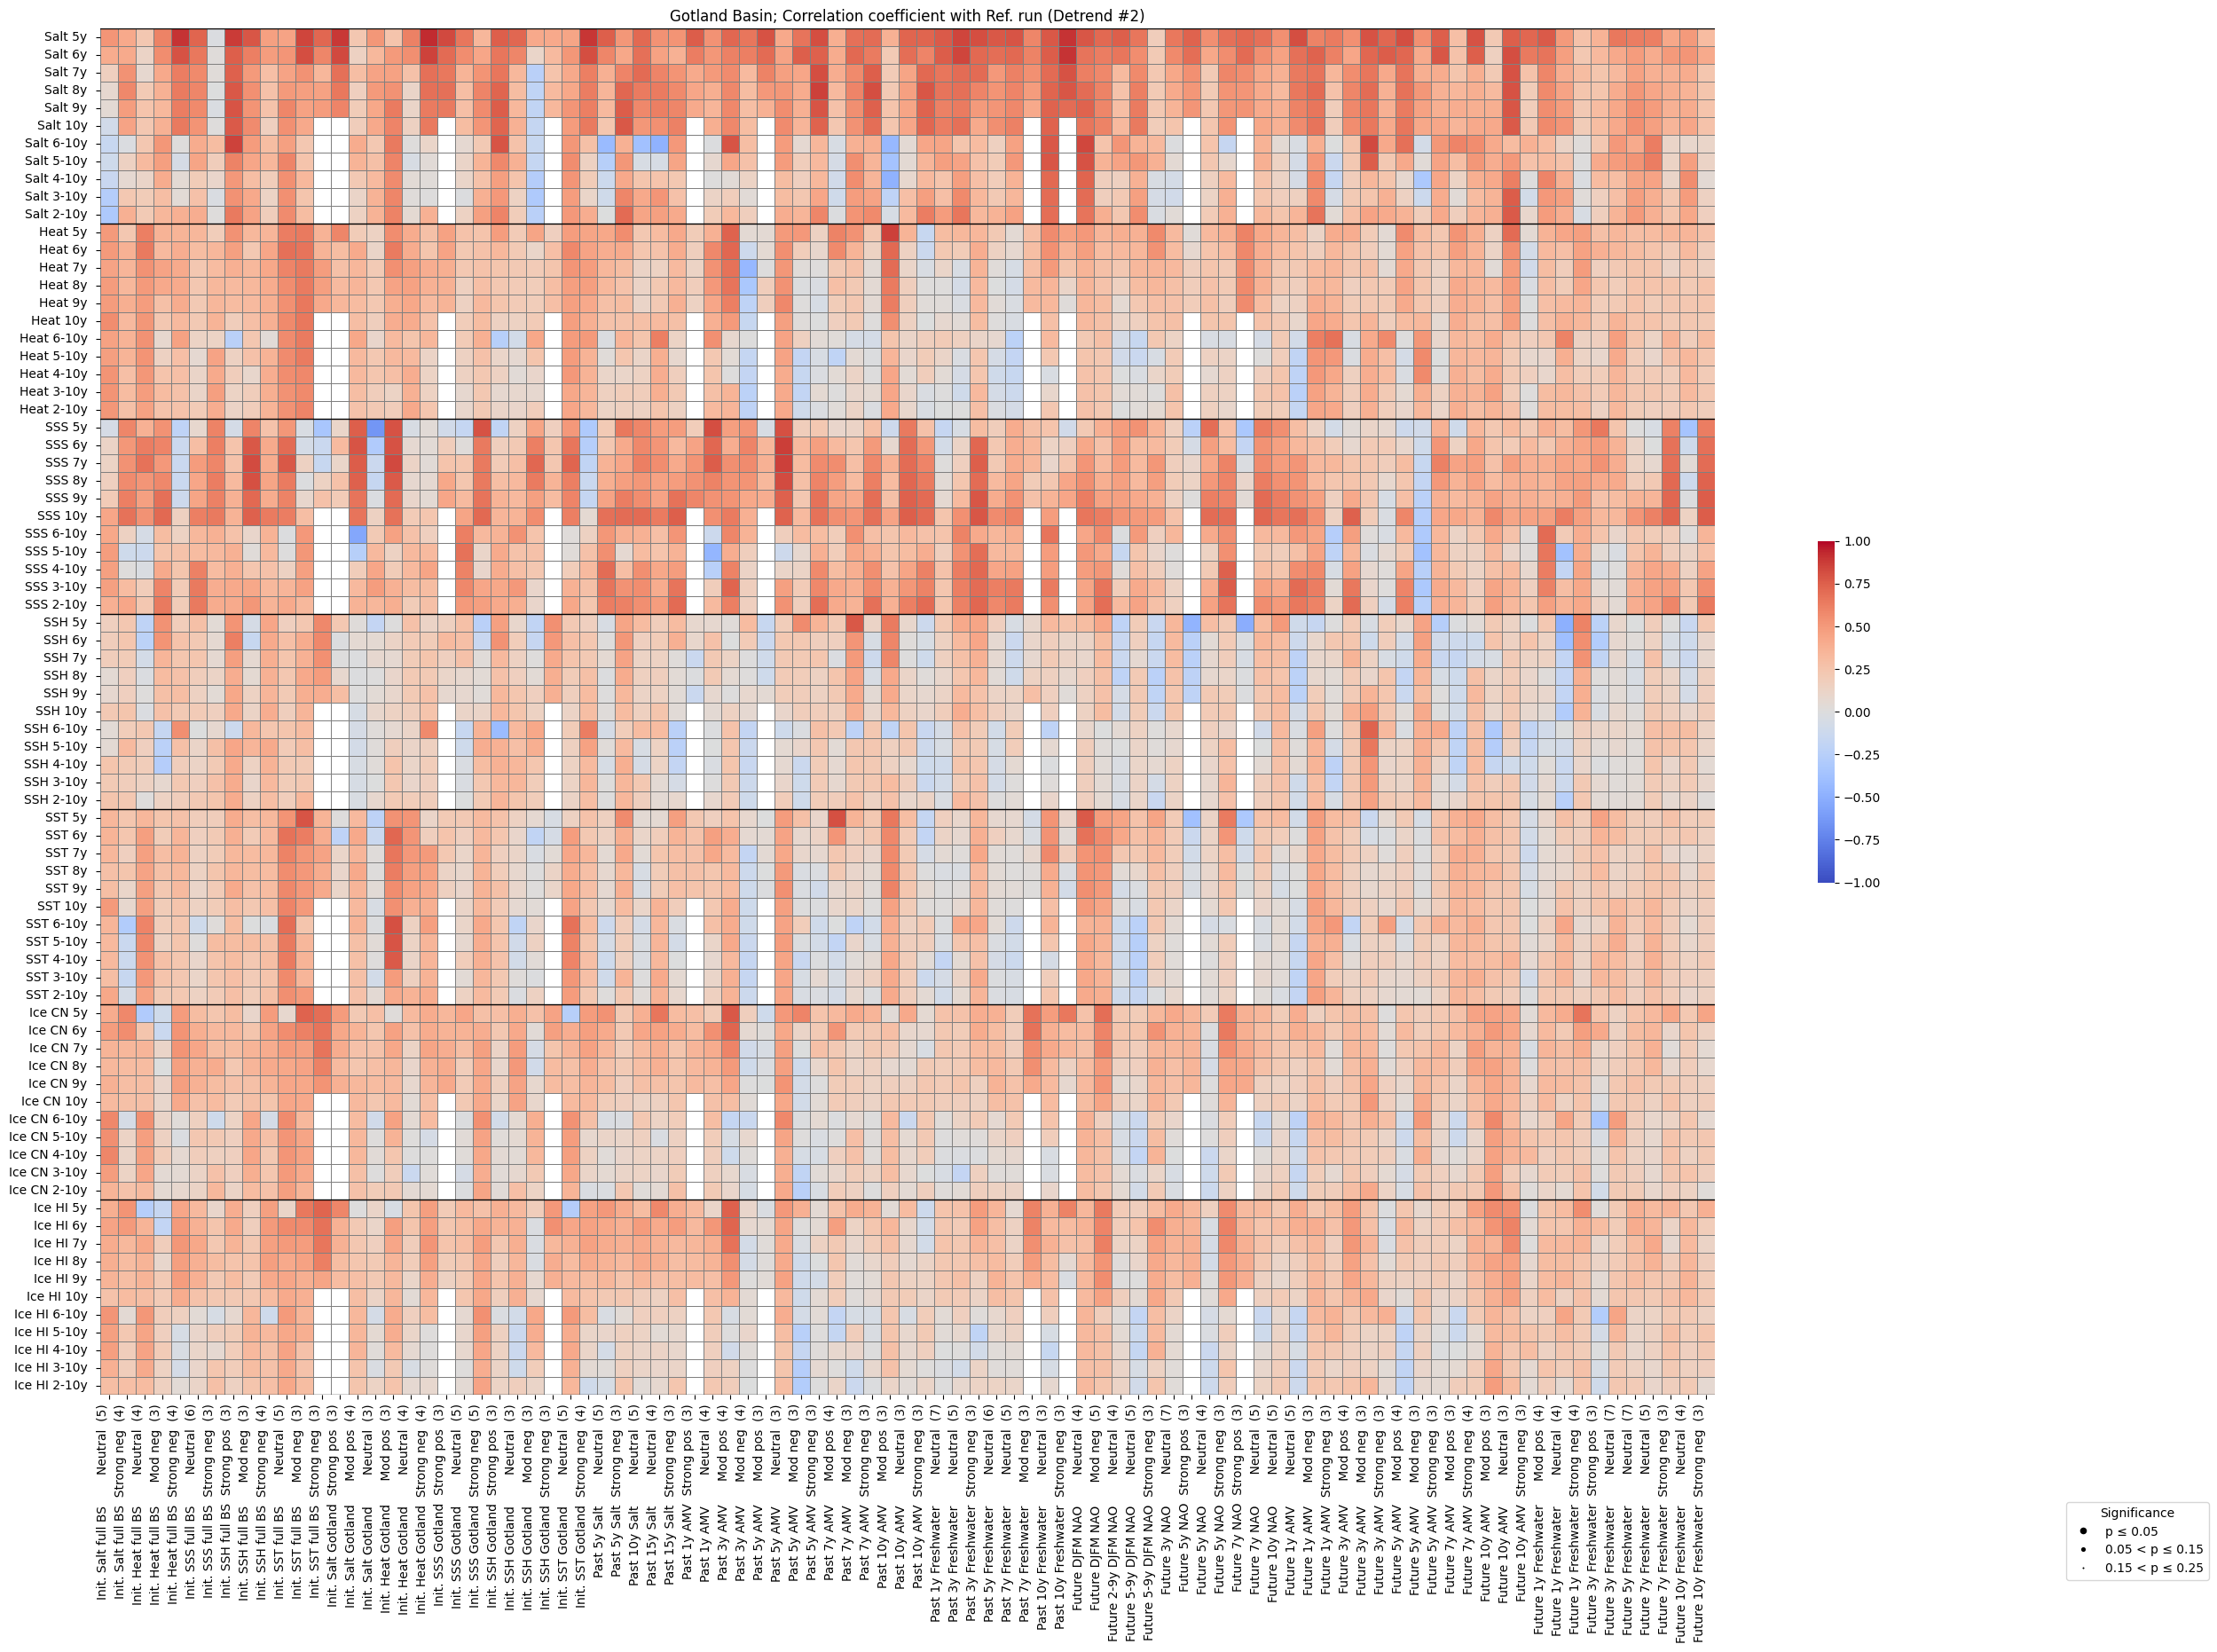

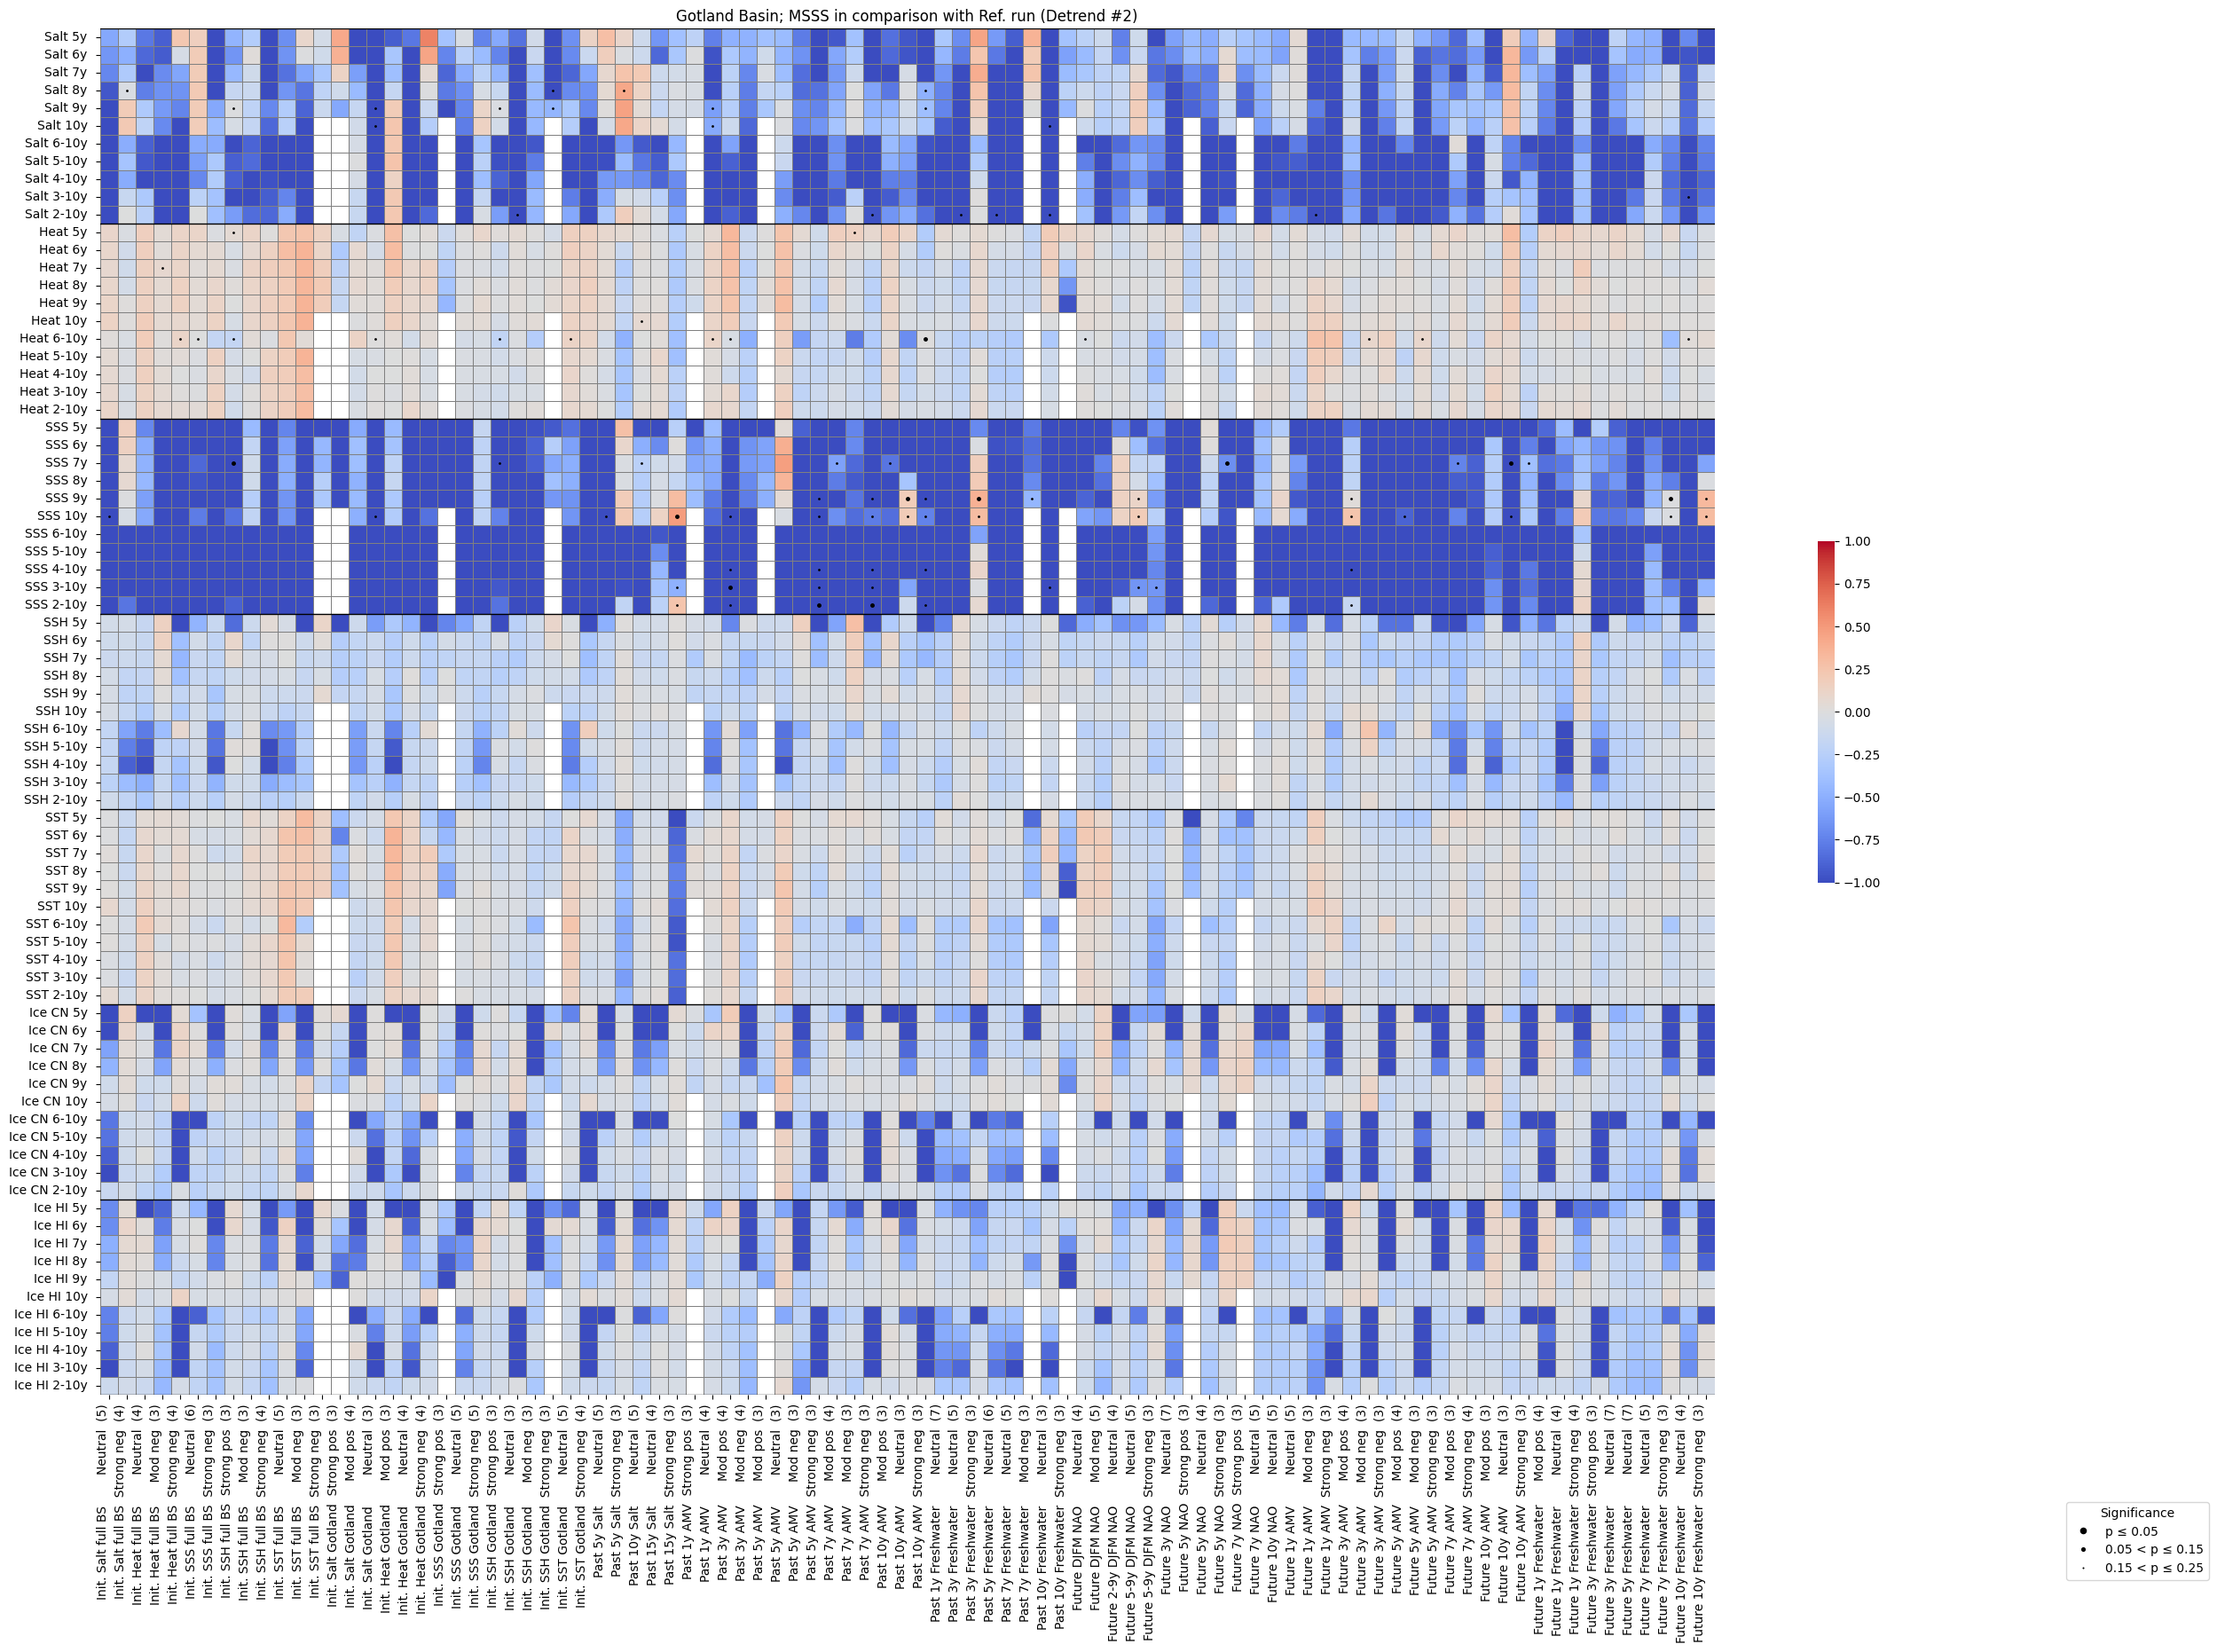

In [22]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_Gotland
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_annual_Gotland['CC'][predictant][timescale][predictor][threshold]), len(skill_data_annual_Gotland['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '5y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '5y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_annual_Gotland['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_annual_Gotland['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_annual_Gotland['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(60,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Gotland_CC1.png", bbox_inches='tight')

plt.figure(figsize=(60,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Gotland_MSSS1.png", bbox_inches='tight')



###### Plot 2 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Gotland_CC2.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Gotland Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Gotland_MSSS2.png", bbox_inches='tight')

### Skill Data Bothnian

In [23]:
'''Initialize library categories to store all the computed values for CC, p-value and MSSS'''
# metrics that measure the prediction skill. CC = pearson correlation coefficient, MSSS = Mean squared skill score; and the the p values of each one using bootstrapping test
metric_names       = ["CC", "CC_p", "MSSS", "MSSS_p"]
# what i want to predict
predictant_names   = ["Salt", "Heat", "SSS", "SSH", "SST", "Ice CN", "Ice HI"]
# on what timescale i am predicting the predictants
timescale_names    = ["5y", "6y", "7y", "8y", "9y", "10y", "6-10y", "5-10y", "4-10y", "3-10y", "2-10y"]
# what variable is used to subsample the ensemble
predictor_names    = ["Init. Salt full BS", "Init. Heat full BS", "Init. SSS full BS", "Init. SSH full BS", "Init. SST full BS",                                                                                       # init. values at start point of ensemble
                      "Init. Salt Bothnian", "Init. Heat Bothnian", "Init. SSS Bothnian", "Init. SSH Bothnian", "Init. SST Bothnian",                                                                                       # init. values at start point of ensemble
                      "Past 5y Salt", "Past 10y Salt", "Past 15y Salt",                                                                                                                                                     # init. values at start point of ensemble
                    #   "Past 5y Salt Bothnian", "Past 10y Salt Bothnian", "Past 15y Salt Bothnian",                                                                                                        # mean total salt values of last .. years before initialization
                      "Past 1y AMV", "Past 3y AMV", "Past 5y AMV", "Past 7y AMV", "Past 10y AMV",                                                                              # mean AMV index over last .. years before initialization
                      "Past 1y Freshwater","Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater",                                               # mean water input (rain, runoff) into BS over last .. years before initialization
                      "Future DJFM NAO", "Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO",                                                                                                             # NAO index, always DJFM mean; either using the Deceber before initialization and the three first months after over the DJFM for the next 2-9 years
                      "Future 1y AMV", "Future 3y AMV", "Future 5y AMV", "Future 7y AMV", "Future 10y AMV",                                                                    # mean AMV index over next .. years after initialization
                      "Future 1y Freshwater","Future 3y Freshwater","Future 5y Freshwater","Future 7y Freshwater","Future 10y Freshwater",                                     # mean water input (rain, runoff) into BS over next .. years after initialization
                    ]
# in what threshold the predictor lays -> essential to compare between ensembles of different initial fields
threshold_names    = [" Strong pos", "     Mod pos", "       Neutral", "     Mod neg", " Strong neg"]

# assign data and refruns to all predictants
predictants   = [
    ("Salt", ds_salt_Bothnian, refruns_salt_Bothnian), ("Heat", ds_heat_Bothnian_ano, refruns_heat_Bothnian_ano), ("SSS", ds_sss_Bothnian, refruns_sss_Bothnian), ("SSH", ds_ssh_Bothnian, refruns_ssh_Bothnian), ("SST", ds_sst_Bothnian_ano, refruns_sst_Bothnian_ano), ("Ice CN", ds_ice_cn_Bothnian, refruns_ice_cn_Bothnian), ("Ice HI", ds_ice_hi_Bothnian, refruns_ice_hi_Bothnian)
    ]

# assign timeseries to all predictors
# time series are computed and formatted a few cells above under 'predictor timeseries'
predictors = [
    ("Init. Heat full BS", heat_0101_full_BS),("Init. Salt full BS", salt_0101_full_BS),("Init. SSS full BS", sss_0101_full_BS),("Init. SST full BS", sst_0101_full_BS),("Init. SSH full BS", ssh_0101_full_BS),
    ("Init. Heat Bothnian", heat_0101_Bothnian),("Init. Salt Bothnian", salt_0101_Bothnian),("Init. SSS Bothnian", sss_0101_Bothnian),("Init. SST Bothnian", sst_0101_Bothnian),("Init. SSH Bothnian", ssh_0101_Bothnian),
    ("Past 1y AMV", ds_AMV_past_1y), ("Past 3y AMV", ds_AMV_past_3y), ("Past 5y AMV", ds_AMV_past_5y), ("Past 7y AMV", ds_AMV_past_7y), ("Past 10y AMV", ds_AMV_past_10y),
    ("Future 1y AMV", ds_AMV_future_1y), ("Future 3y AMV", ds_AMV_future_3y), ("Future 5y AMV", ds_AMV_future_5y), ("Future 7y AMV", ds_AMV_future_7y), ("Future 10y AMV", ds_AMV_future_10y),
    ("Future DJFM NAO", NAO_DJFM), ("Future 2-9y DJFM NAO", NAO_DJFM_29), ("Future 5-9y DJFM NAO", NAO_DJFM_59), ("Future 3y NAO", NAO_DJFM_future_3y), ("Future 5y NAO", NAO_DJFM_future_5y), ("Future 7y NAO", NAO_DJFM_future_7y), ("Future 10y NAO", NAO_DJFM_future_10y),
    ("Past 1y Freshwater", ds_freshwater_past_1y), ("Past 3y Freshwater", ds_freshwater_past_3y), ("Past 5y Freshwater", ds_freshwater_past_5y), ("Past 7y Freshwater", ds_freshwater_past_7y), ("Past 10y Freshwater", ds_freshwater_past_10y),  
    ("Future 1y Freshwater", ds_freshwater_future_1y), ("Future 3y Freshwater", ds_freshwater_future_3y), ("Future 5y Freshwater", ds_freshwater_future_5y), ("Future 7y Freshwater", ds_freshwater_future_7y), ("Future 10y Freshwater", ds_freshwater_future_10y), 
    ("Past 5y Salt full BS", salt_past_5y_full_BS), ("Past 10y Salt full BS", salt_past_10y_full_BS), ("Past 15y Salt full BS", salt_past_15y_full_BS), 
    ("Past 5y Salt Bothnian", salt_past_5y_bothnian), ("Past 10y Salt Bothnian", salt_past_10y_bothnian), ("Past 15y Salt Bothnian", salt_past_15y_bothnian) 
    ]


# skill_data_annual_Bothnian['metric']['predictant']['timescale']['predictor']['threshold']
skill_data_annual_Bothnian   = {
    metric: {
        predictant: {
            timescale: {
                predictor: {
                    threshold: [] for threshold in threshold_names
                } for predictor in predictor_names
            } for timescale in timescale_names
        } for predictant in predictant_names
    } for metric in metric_names
}
skill_data_annual_Bothnian_scores_EY = []
skill_data_annual_Bothnian_p_EY = []


# Define file paths
path1 = 'ensemble_data/Bothnian/skill_data_annual_Bothnian.pkl'
path2 = 'ensemble_data/Bothnian/skill_data_annual_Bothnian_scores_EY.pkl'
path3 = 'ensemble_data/Bothnian/skill_data_annual_Bothnian_p_EY.pkl'
# Load only if the files exist
if os.path.exists(path1):
    with open(path1, 'rb') as f:
        skill_data_annual_Bothnian = pickle.load(f)
if os.path.exists(path2):
    with open(path2, 'rb') as f:
        skill_data_annual_Bothnian_scores_EY = pickle.load(f)
if os.path.exists(path3):
    with open(path3, 'rb') as f:
        skill_data_annual_Bothnian_p_EY = pickle.load(f)

In [24]:
'''Compute CC and MSSS (ca. 15min)'''

for EY in ensemble_years:
    if EY in skill_data_annual_Bothnian_scores_EY:
        continue  # skip, already read in
    skill_data_annual_Bothnian_scores_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 5y Salt Bothnian", "Past 10y Salt Bothnian", "Past 15y Salt Bothnian"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 10y Salt Bothnian", "Past 15y Salt Bothnian"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS", "Past 15y Salt Bothnian"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_annual_Bothnian list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                CC, _, MSSS, _ = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Bothnian', bootstrap=0)
                skill_data_annual_Bothnian['CC'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC,4))
                skill_data_annual_Bothnian['MSSS'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS,4))


# save skill_data_annual_Bothnian and years already evaluated
with open('ensemble_data/Bothnian/skill_data_annual_Bothnian.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Bothnian, f)
with open('ensemble_data/Bothnian/skill_data_annual_Bothnian_scores_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Bothnian_scores_EY, f)

In [25]:
'''Bootstrapping: compute p_values of CC and MSSS (ca. 2h)'''

for EY in ensemble_years:
    if EY in skill_data_annual_Bothnian_p_EY:
        continue  # skip, already read in
    skill_data_annual_Bothnian_p_EY.append(EY)
    for predictant_name, predictant_ds, predictant_refruns in predictants:
        print(f"{predictant_name} {EY}")
        for timescale in timescale_names:
            print(timescale)
            if EY == 2011 and timescale in ["2-10y","3-10y","4-10y","5-10y","6-10y","10y"]: # only 9y of refrun left
                continue
            for predictor_name, predictor_timeseries in predictors:

                # for all predictors listed above use function to determine in which threshold the initial field of a given EY lays
                if predictor_name == "Init. Heat" or predictor_name == "Init. SST":  # detrend temperature related timeseries to remove climate change signal
                    detrend = 1
                else:
                    detrend = 0
                if EY == 1951 and predictor_name in ["Past 3y Freshwater","Past 5y Freshwater","Past 7y Freshwater","Past 10y Freshwater", "Future DJFM NAO", "Future 3y NAO", "Future 5y NAO", "Future 7y NAO", "Future 10y NAO", "Past 5y Salt full BS", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 5y Salt Bothnian", "Past 10y Salt Bothnian", "Past 15y Salt Bothnian"]:
                    continue
                if EY == 1956 and predictor_name in ["Past 10y Freshwater", "Past 10y Salt full BS", "Past 15y Salt full BS", "Past 10y Salt Bothnian", "Past 15y Salt Bothnian"]:
                    continue
                if EY == 1961 and predictor_name in ["Past 15y Salt full BS", "Past 15y Salt Bothnian"]:
                    continue
                if EY == 2011 and predictor_name in ["Future 2-9y DJFM NAO", "Future 5-9y DJFM NAO", "Future 10y NAO", "Future 10y AMV", "Future 10y Freshwater"]:
                    continue

                if predictor_name == "Ensemble mean":
                    thres_name = "       Neutral"
                    thres_years = predictant_ds.year
                else:
                    _, thres_name, thres_years = get_predictor_thresholds(predictor_timeseries, detrend, EY)

                # compute the wished skill metrics and append them to the skill_data_annual_Bothnian list. use append because predictors can lay in the sam threshold for different EY 
                # the part '.sel(year=thres_years)' does the subsampling thats so crucial in this study
                _, CC_p, _, MSSS_p = compute_skill_metrics(data_timeseries=predictant_ds.sel(EY=EY).sel(year=thres_years).mean(dim='year') , refrun_timeseries=predictant_refruns[EY] , timescale=timescale, predictant=predictant_name, basin='Bothnian', bootstrap=1)
                skill_data_annual_Bothnian['CC_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(CC_p,4))
                skill_data_annual_Bothnian['MSSS_p'][predictant_name][timescale][predictor_name][thres_name].append(np.round(MSSS_p,4))


# save skill_data_annual_Bothnian and years already evaluated
with open('ensemble_data/Bothnian/skill_data_annual_Bothnian.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Bothnian, f)
with open('ensemble_data/Bothnian/skill_data_annual_Bothnian_p_EY.pkl', 'wb') as f:
    pickle.dump(skill_data_annual_Bothnian_p_EY, f)

/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tb2267/jupyter_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


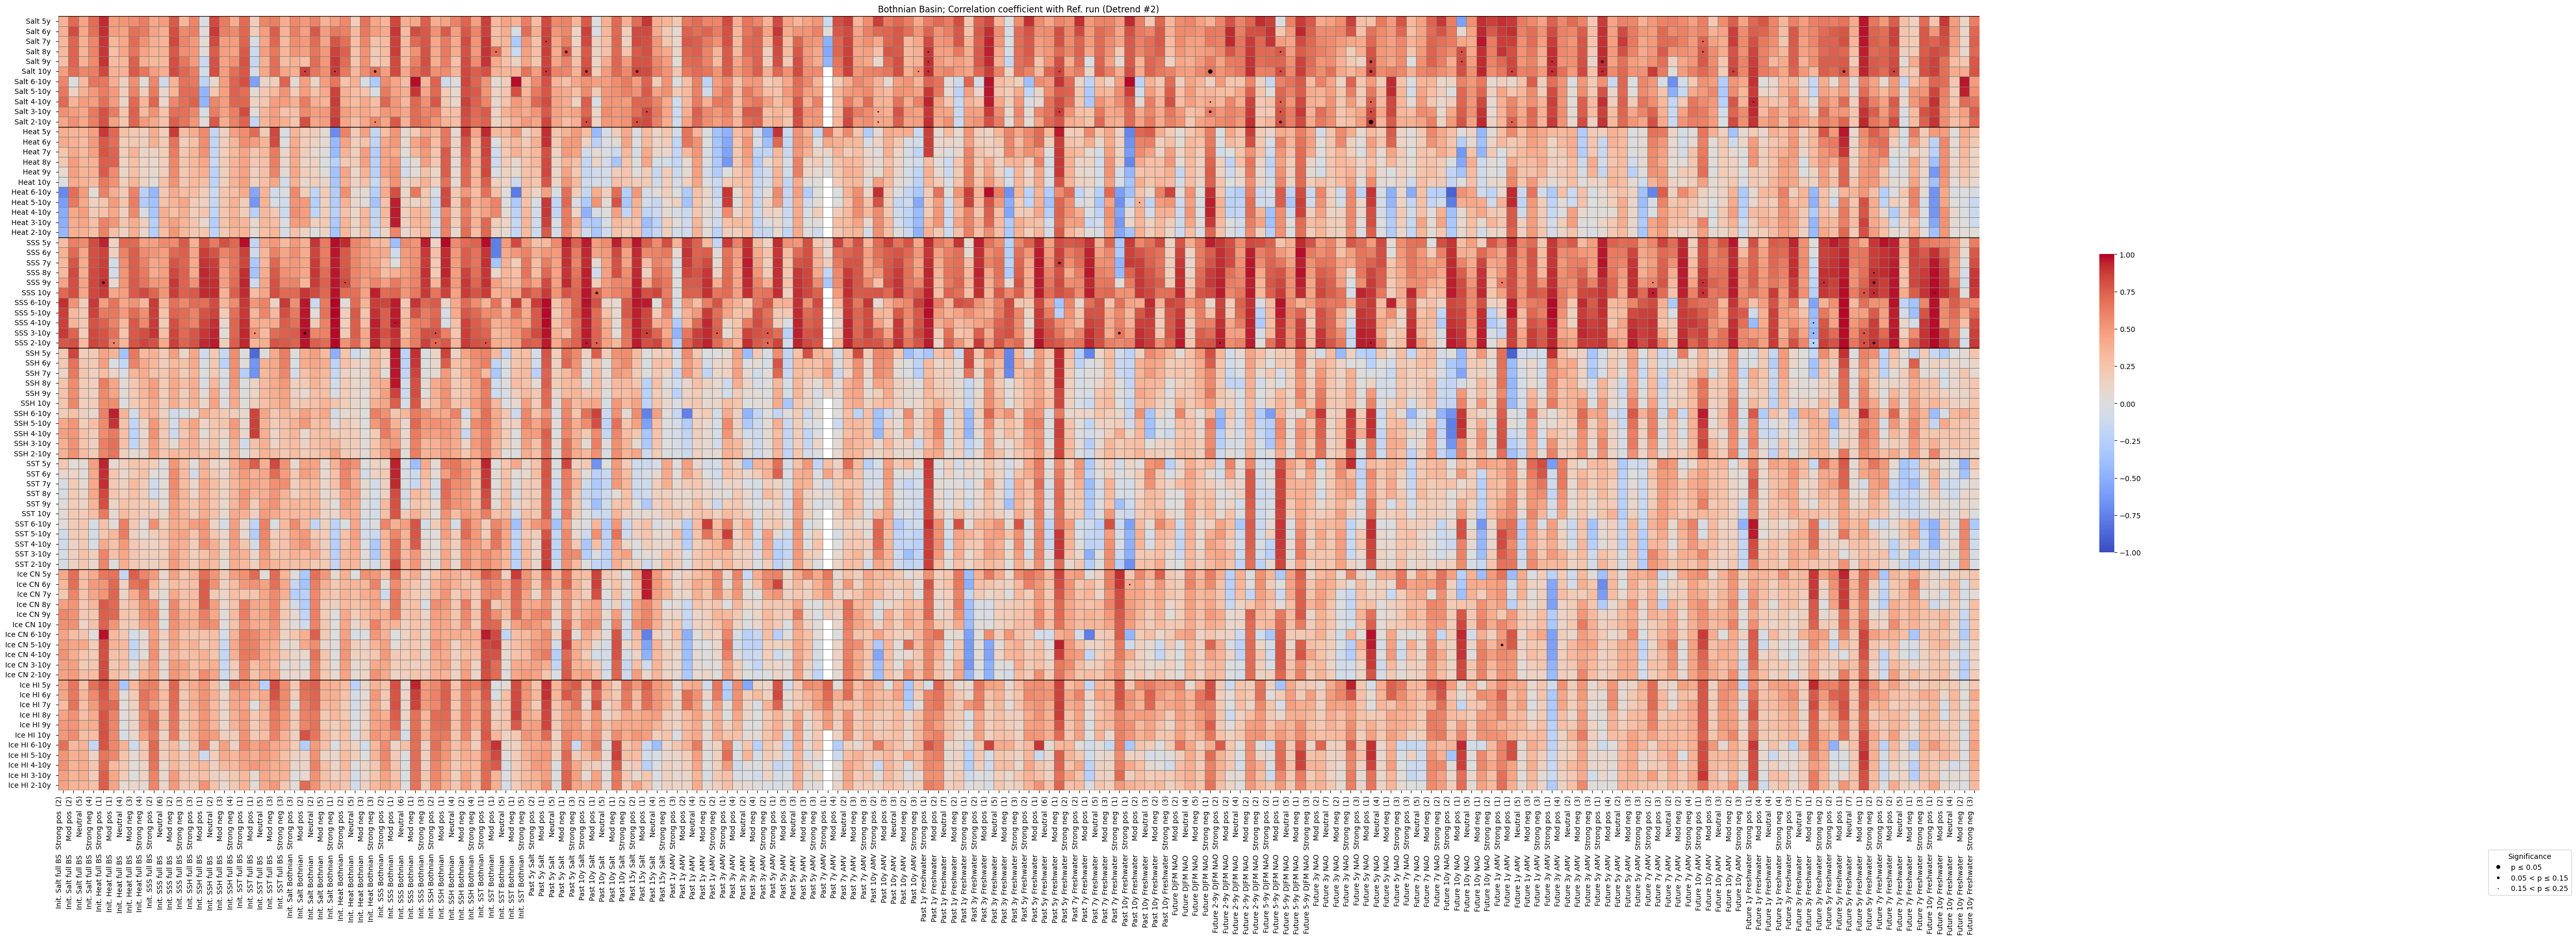

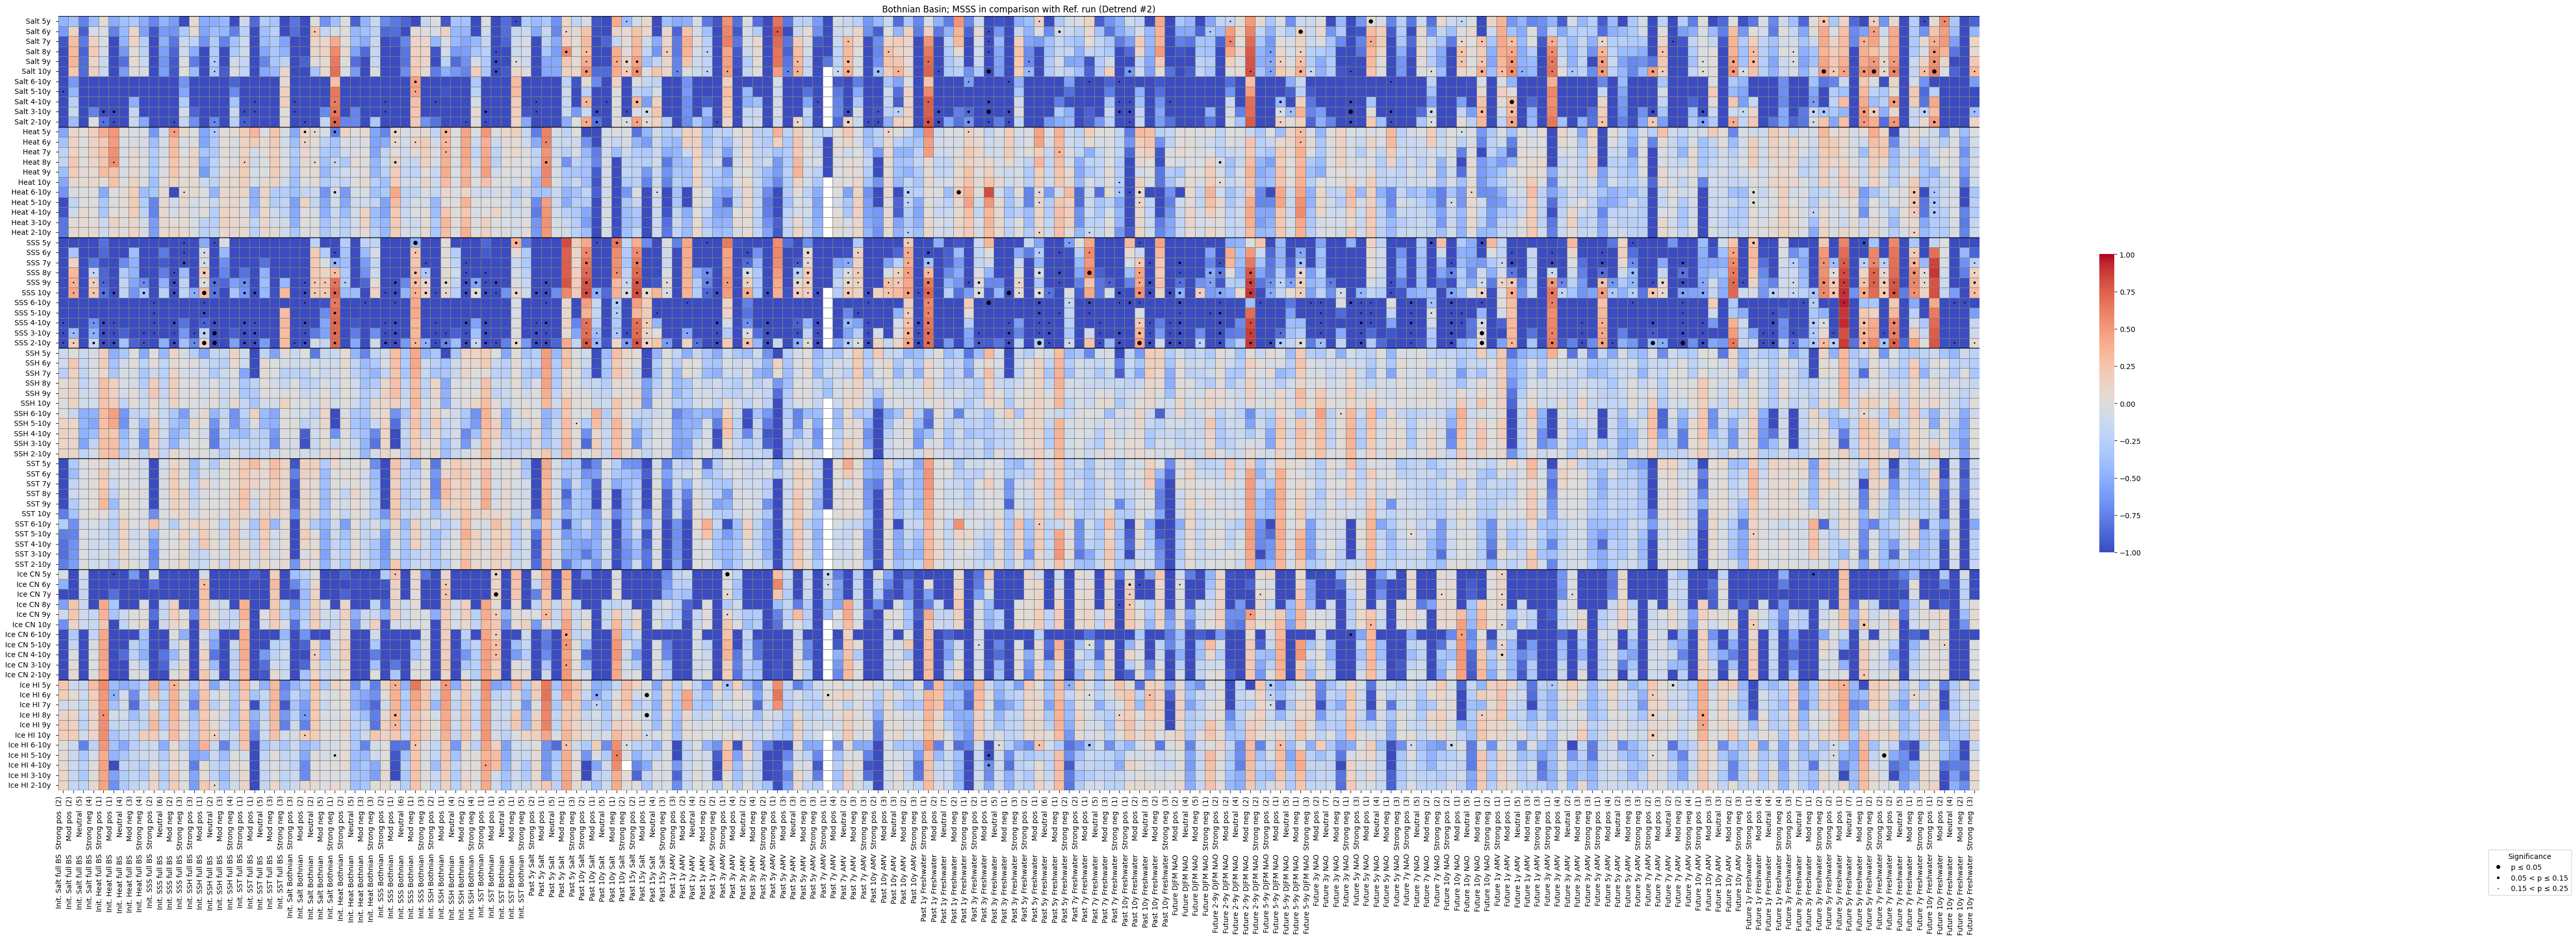

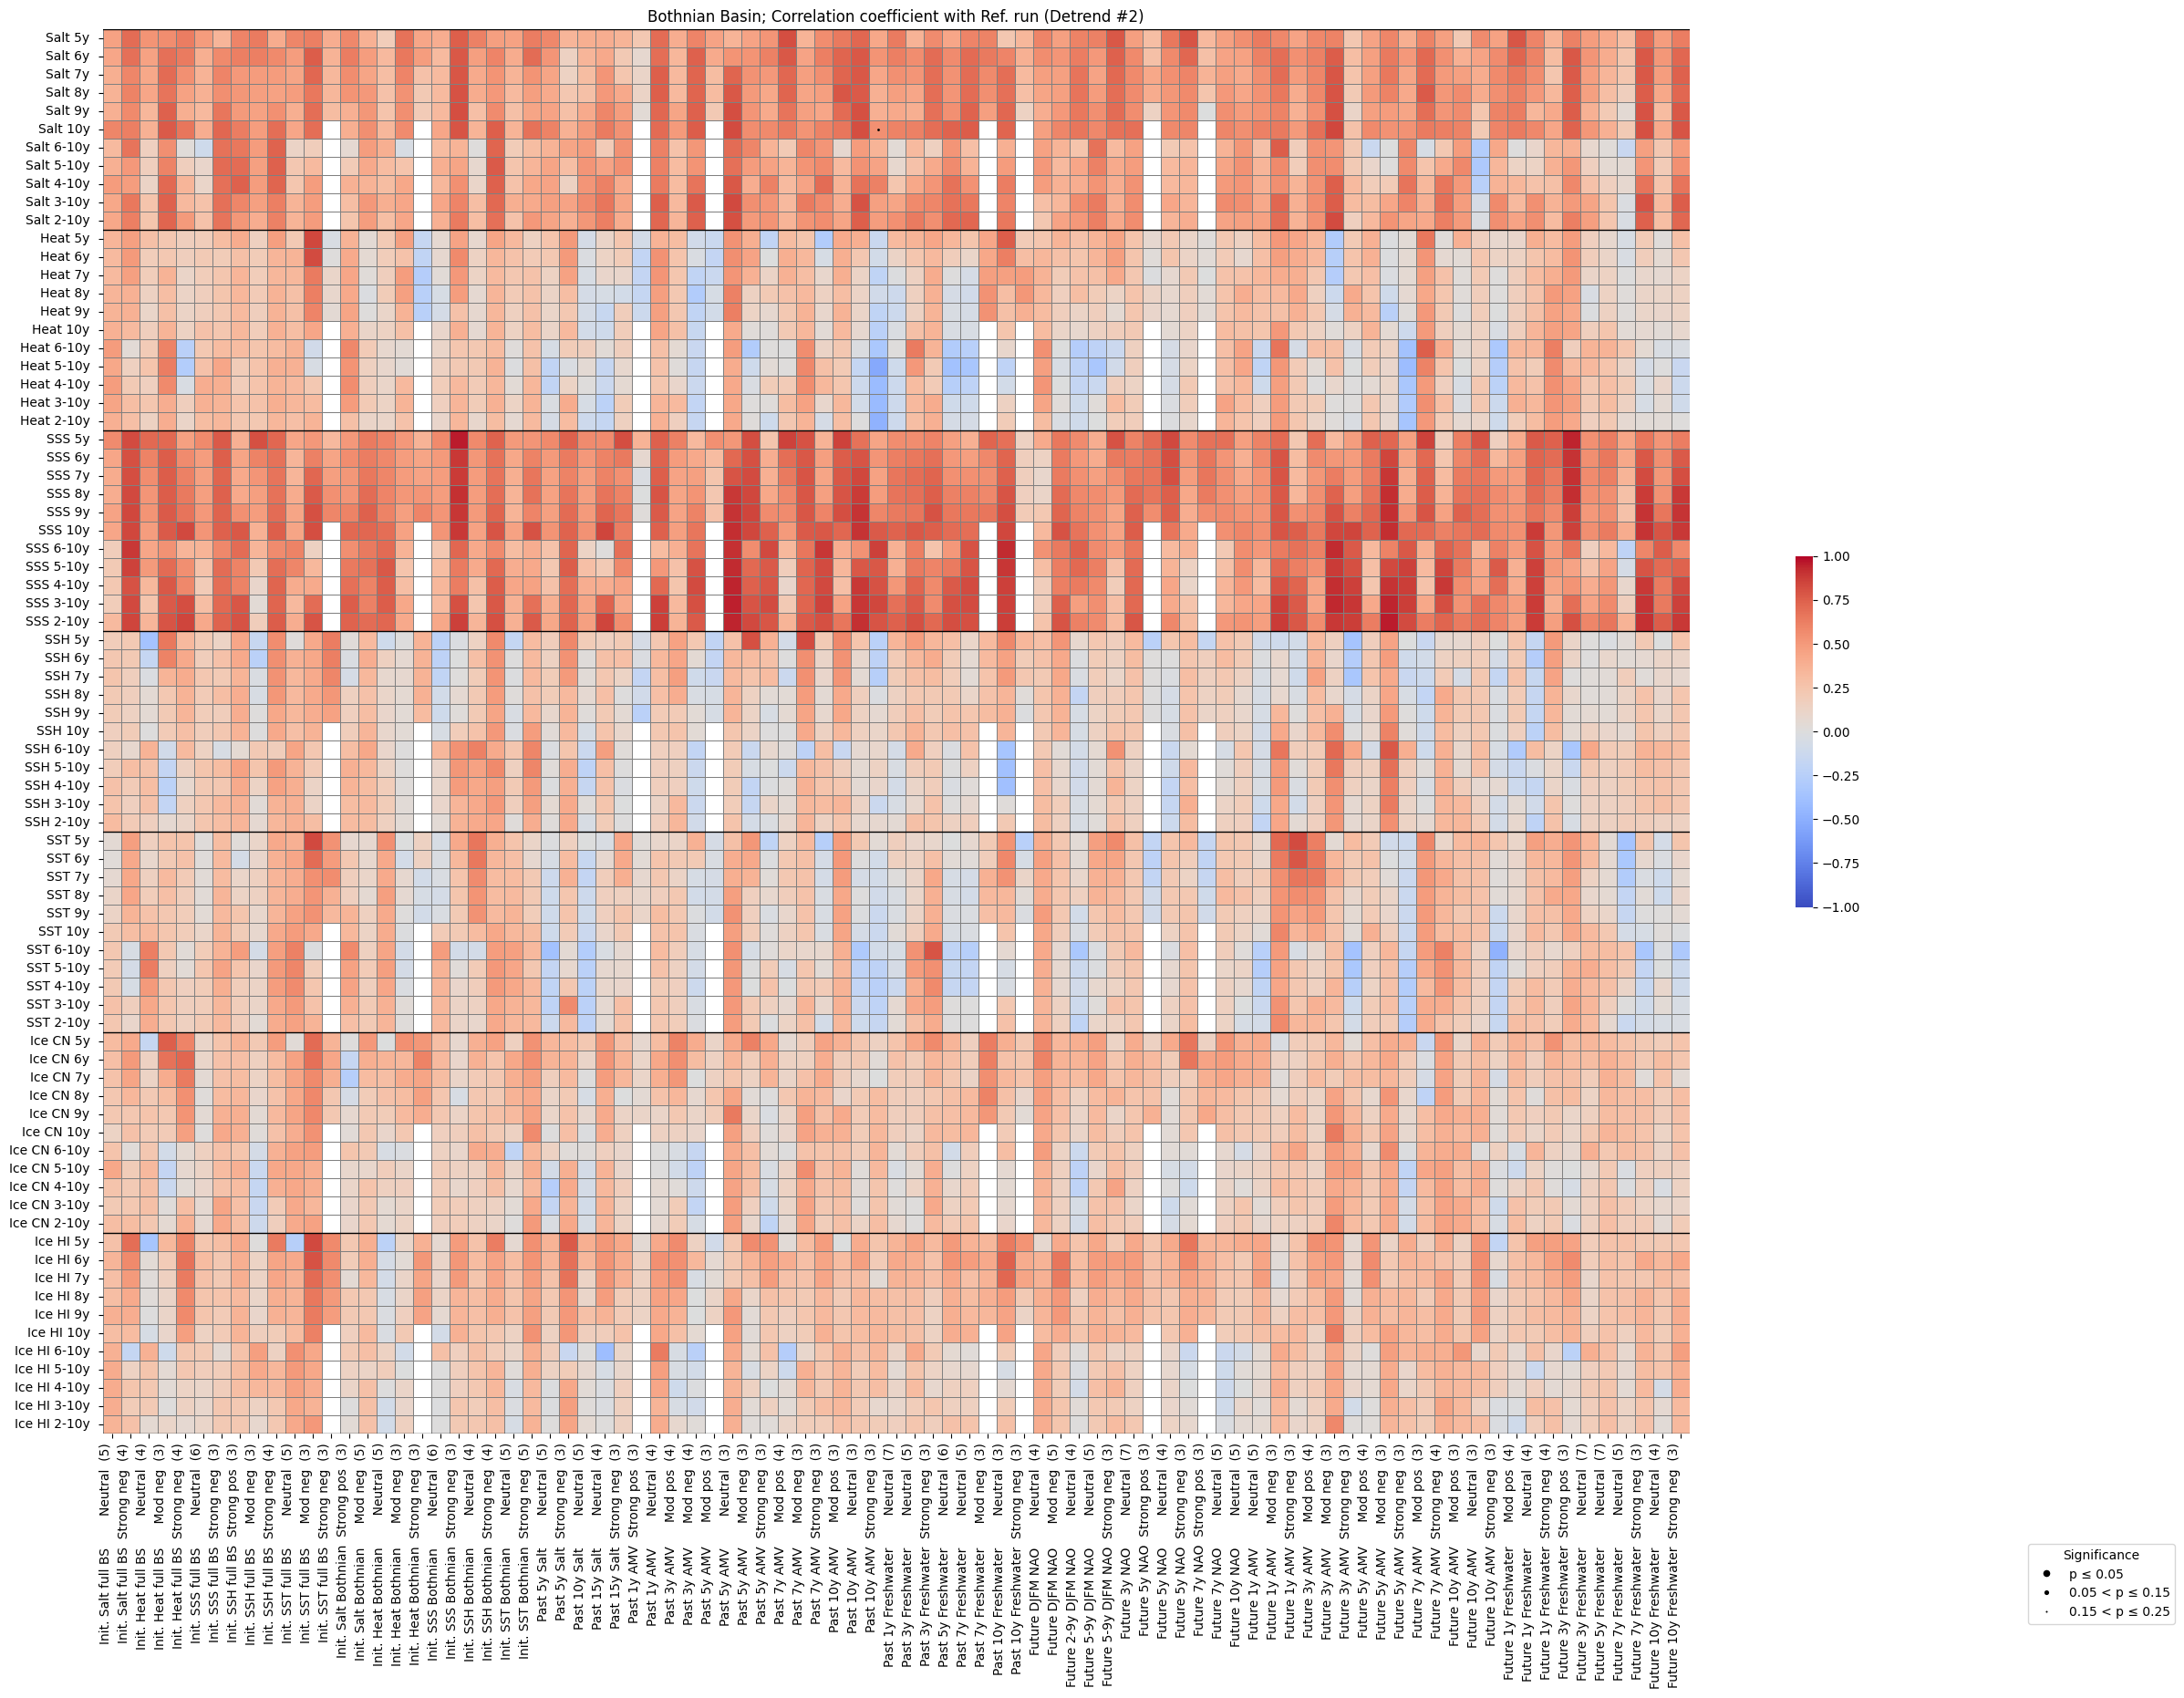

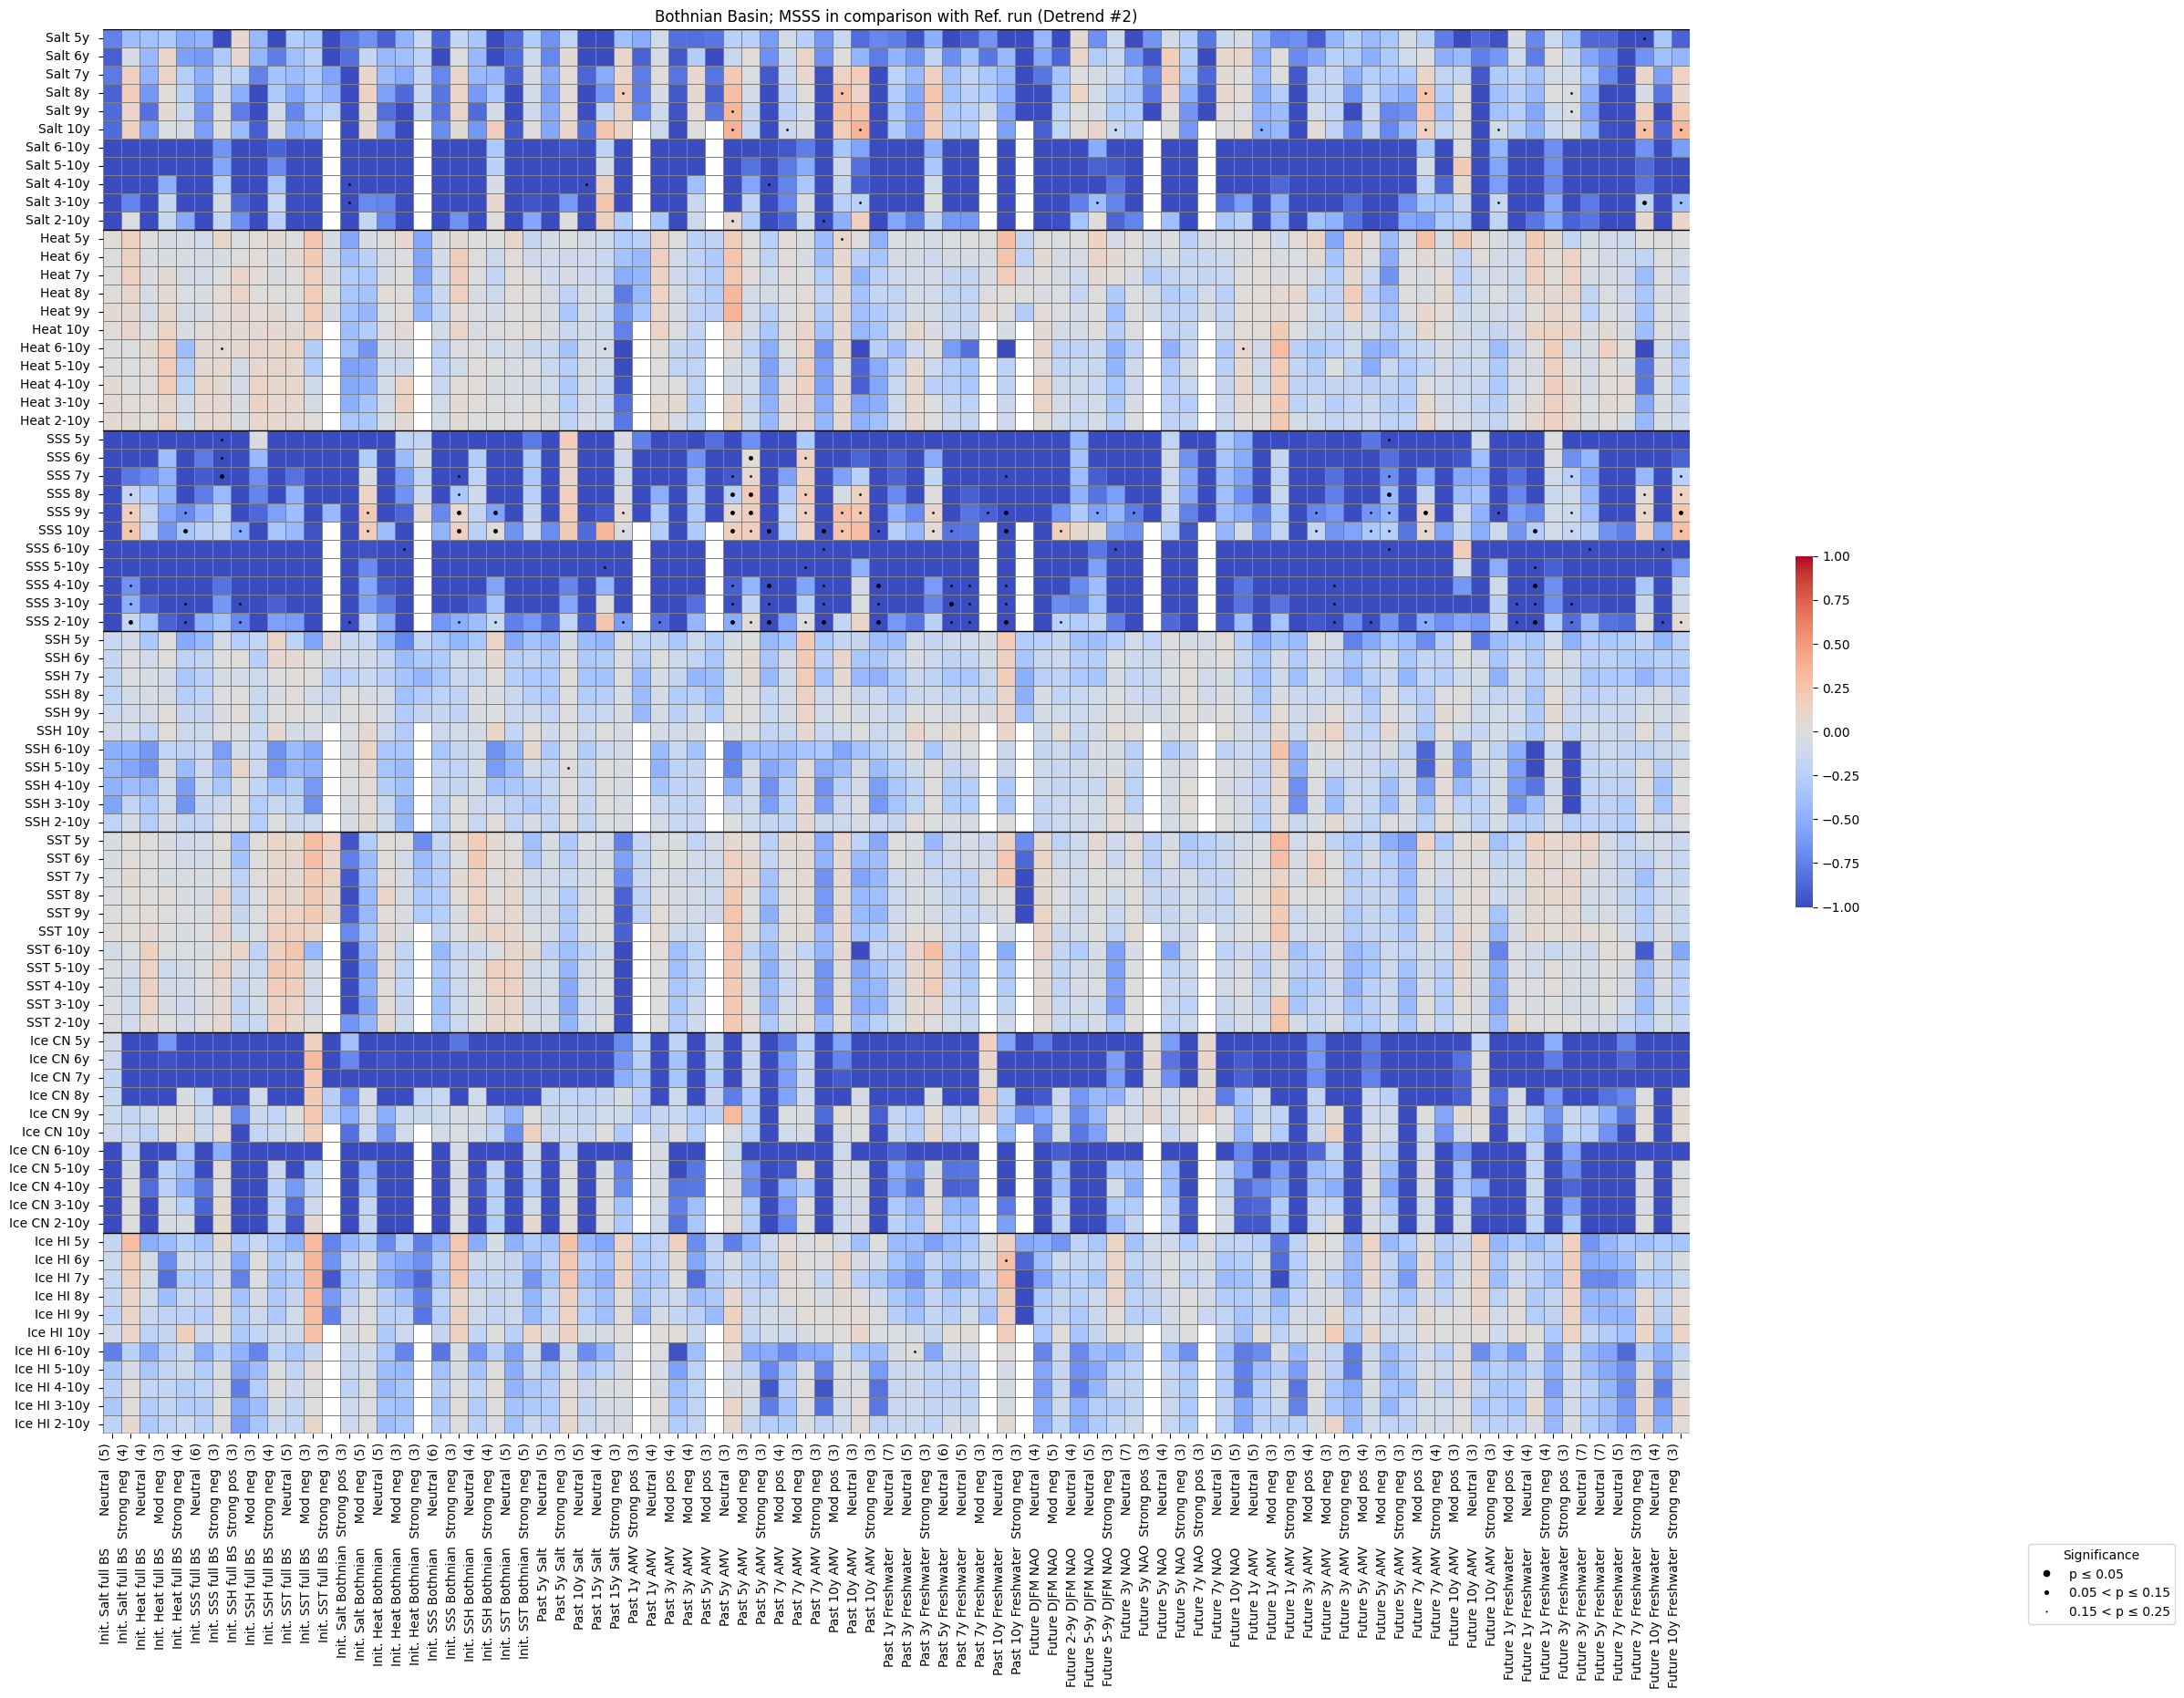

In [26]:
'''Plot the CC&MSSS data including the boostrapped p-values in a heatmap'''

min_sample_size = 3

###### Prepare the plot ##########################################################################################################################################################
# Define row and column labels & initialize dataframe
row_labels = [f"{predictor} {threshold} " for predictor in predictor_names for threshold in threshold_names]
col_labels = [f"{predictant} {timescale} " for predictant in predictant_names for timescale in timescale_names]
# Dataframes that contain all the data
df_CC     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
# Initialize datafraes than only contain data more than 1 EY have the same init. field
df_CC_min_sample_size     = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_CC_p_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_min_sample_size   = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)
df_MSSS_p_min_sample_size = pd.DataFrame(index=row_labels, columns=col_labels, dtype=float)

# Fill the df with the values of skill_data_Bothnian
labels = []
labels_min_sample_size = []
for predictant in predictant_names:
    for timescale in timescale_names:
        for predictor in predictor_names:
            for threshold in threshold_names:
                row_key  = f"{predictor} {threshold} "
                col_key  = f"{predictant} {timescale} "
                CC_value = [np.mean(skill_data_annual_Bothnian['CC'][predictant][timescale][predictor][threshold]), len(skill_data_annual_Bothnian['CC'][predictant][timescale][predictor][threshold])]
                df_CC.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                # Creating a list of labels for the later plot. Setting predictor and timescale to a specific value makes sure that each label is only appended once (otherwise each label is in the list as often as there are predictant timescale combinations)
                if CC_value[1] > 0 and predictant == 'Salt' and timescale == '5y':
                    labels.append(f"{row_key} ({CC_value[1]})")
                if CC_value[1] > min_sample_size-1 and predictant == 'Salt' and timescale == '5y':
                    labels_min_sample_size.append(f"{row_key} ({CC_value[1]})")
                CC_p = np.mean(skill_data_annual_Bothnian['CC_p'][predictant][timescale][predictor][threshold])
                df_CC_p.at[row_key, col_key] = CC_p if CC_p else np.nan
                MSSS_value = np.mean(skill_data_annual_Bothnian['MSSS'][predictant][timescale][predictor][threshold])
                df_MSSS.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                MSSS_p = np.mean(skill_data_annual_Bothnian['MSSS_p'][predictant][timescale][predictor][threshold])
                df_MSSS_p.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan
                if CC_value[1] > min_sample_size-1:
                    df_CC_min_sample_size.at[row_key, col_key] = CC_value[0] if CC_value else np.nan
                    df_CC_p_min_sample_size.at[row_key, col_key] = CC_p if CC_p else np.nan
                    df_MSSS_min_sample_size.at[row_key, col_key] = MSSS_value if MSSS_value else np.nan
                    df_MSSS_p_min_sample_size.at[row_key, col_key] = MSSS_p if MSSS_p else np.nan

df_CC_plot     = df_CC.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_plot   = df_CC_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_plot   = df_MSSS.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_plot = df_MSSS_p.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_min_sample_size_plot     = df_CC_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_CC_p_min_sample_size_plot   = df_CC_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_min_sample_size_plot   = df_MSSS_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN
df_MSSS_p_min_sample_size_plot = df_MSSS_p_min_sample_size.T.dropna(how='all', axis=1)  # drop rows where all values are NaN


###### Plot all the data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(60,30))
ax = sns.heatmap(df_CC_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_CC_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_plot.shape[0]):
    for j in range(df_CC_plot.shape[1]):
        pval = df_CC_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Bothnian_CC1.png", bbox_inches='tight')

plt.figure(figsize=(60,30))
ax = sns.heatmap(df_MSSS_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels, rotation=90, ha='right')
for i in range(0, (df_MSSS_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_plot.shape[0]):
    for j in range(df_MSSS_plot.shape[1]):
        pval = df_MSSS_p_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Bothnian_MSSS1.png", bbox_inches='tight')



###### Plot 2 or more data ##########################################################################################################################################################
# Plot CC
plt.figure(figsize=(30,20))
ax = sns.heatmap(df_CC_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; Correlation coefficient with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_CC_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot with legend
for i in range(df_CC_min_sample_size_plot.shape[0]):
    for j in range(df_CC_min_sample_size_plot.shape[1]):
        pval = df_CC_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p ≤ 0.05', markerfacecolor='black', markersize=6.5),
    Line2D([0], [0], marker='o', color='w', label='0.05 < p ≤ 0.15', markerfacecolor='black', markersize=4.75),
    Line2D([0], [0], marker='o', color='w', label='0.15 < p ≤ 0.25', markerfacecolor='black', markersize=2.5),
]
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Bothnian_CC2.png", bbox_inches='tight')

plt.figure(figsize=(30,20))
ax = sns.heatmap(df_MSSS_min_sample_size_plot, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": 0.25}, linewidths=0.5, linecolor='gray', square=True)
plt.title("Bothnian Basin; MSSS in comparison with Ref. run (Detrend #2)")
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
ax.set_xticklabels(labels_min_sample_size, rotation=90, ha='right')
for i in range(0, (df_MSSS_min_sample_size_plot.shape[1]+2), 11):
    ax.axhline(i, color='black', linewidth=1)
# Plot p value dots onto CC plot
for i in range(df_MSSS_min_sample_size_plot.shape[0]):
    for j in range(df_MSSS_min_sample_size_plot.shape[1]):
        pval = df_MSSS_p_min_sample_size_plot.iloc[i, j]
        if pd.notna(pval):
            if pval <= 0.05:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=5, color='black')  
            elif pval <= 0.10:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=2.5, color='black')  
            elif pval <= 0.15:
                ax.plot(j + 0.5, i + 0.5, 'o', markersize=1, color='black')  
ax.legend(handles=legend_elements, title='Significance', bbox_to_anchor=(1.31, -0.14), loc='lower right')
plt.savefig("plots_ensemble_colormaps/current/Bothnian_MSSS2.png", bbox_inches='tight')

### Blocksize determining

/tmp/ipykernel_2173379/262602324.py:221: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 800x400 with 0 Axes>

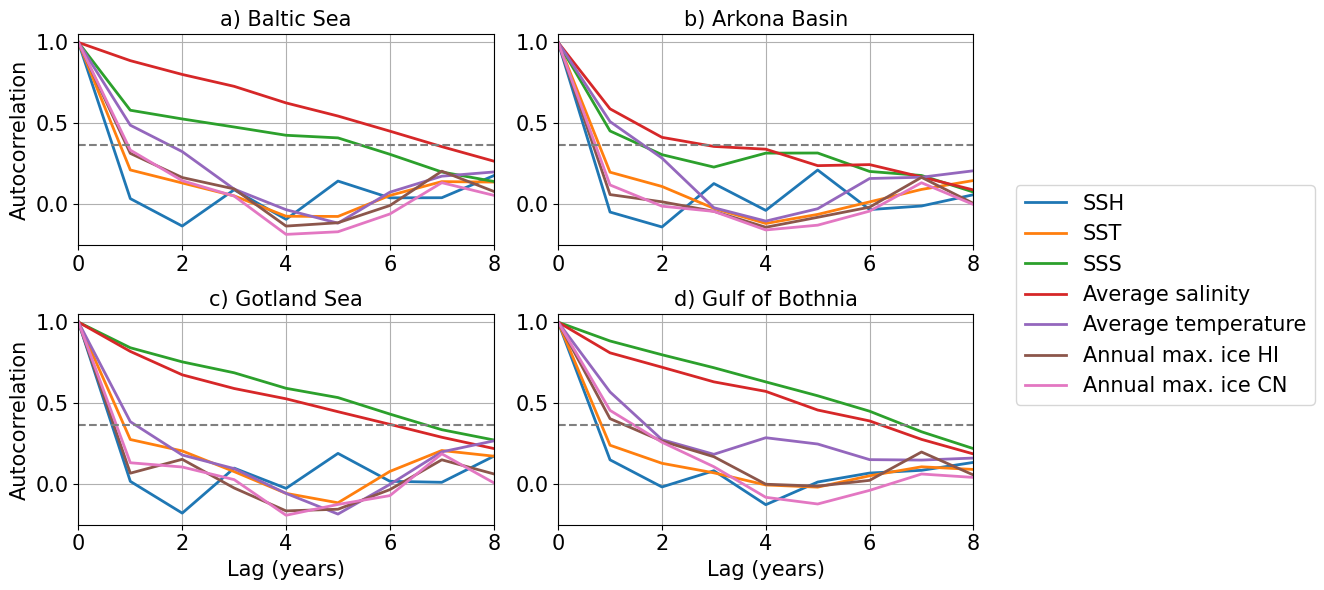

In [28]:
'''Plot autocorrelation functions for refrun'''

# Constants
MAX_LAG = 8  # 10 years
E_INV = 1 / np.e   # ≈ 0.3679

# Load and rename datasets
datasets_full_BS = {
    "SSH": refrun_ssh_full_BS['SSH'].resample(time='1YS').mean(),
    "SST": refrun_sst_full_BS['SST'].resample(time='1YS').mean(),
    "SSS": refrun_sss_full_BS['SSS'].resample(time='1YS').mean(),
    "Average salinity": refrun_salt_full_BS['Salt'].resample(time='1YS').mean(),
    "Average temperature": refrun_heat_full_BS['Heat'].resample(time='1YS').mean(),
    "Annual max. ice HI":  refrun_ice_hi_full_BS['HI'].resample(time='1YS').mean(),
    "Annual max. ice CN":  refrun_ice_cn_full_BS['CN'].sum(dim='ct').resample(time='1YS').mean()
}

# # Set up plot
# plt.figure(figsize=(8,4))
# colors = plt.cm.tab10.colors
# acf_decay_lags = {}

# # Loop over each dataset
# for i, (var_name, ds) in enumerate(datasets_full_BS.items()):

#     # Compute ACF
#     acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

#     # Find first lag where ACF drops below 1/e
#     below = np.where(acf_vals < E_INV)[0]
#     first_below = below[0] if len(below) > 0 else None
#     acf_decay_lags[var_name] = first_below

#     # Plot
#     plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name}")# (drop <1/e @ {first_below} mo)", color=colors[i % len(colors)])

# # Plot formatting
# plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
# plt.xlabel("Lag (yrs)")
# plt.ylabel("Autocorrelation")
# plt.title("Full Baltic Sea")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Print the decay lags
# print("Lag (in years) where ACF first drops below 1/e:")
# for var, lag in acf_decay_lags.items():
#     print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")


# Load and rename datasets
datasets_arkona = {
    "SSH": refrun_sfc_arkona['SSH'].resample(time='1YS').mean(),
    "SST": refrun_sfc_arkona['SST'].resample(time='1YS').mean(),
    "SSS": refrun_sfc_arkona['SSS'].resample(time='1YS').mean(),
    "Salt": refrun_salt_arkona['salt'].resample(time='1YS').mean(),
    "Heat": refrun_heat_arkona['temp'].resample(time='1YS').mean(),
    "Ice HI":  refrun_ice_arkona['HI'].resample(time='1YS').mean(),
    "Ice CN":  refrun_ice_arkona['CN'].sum(dim='ct').resample(time='1YS').mean()
}

# Set up plot
plt.figure(figsize=(8,4))
colors = plt.cm.tab10.colors
acf_decay_lags = {}

# # Loop over each dataset
# for i, (var_name, ds) in enumerate(datasets_arkona.items()):

#     # Compute ACF
#     acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

#     # Find first lag where ACF drops below 1/e
#     below = np.where(acf_vals < E_INV)[0]
#     first_below = below[0] if len(below) > 0 else None
#     acf_decay_lags[var_name] = first_below

#     # Plot
#     plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} y)", color=colors[i % len(colors)])

# # Plot formatting
# plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
# plt.xlabel("Lag (yrs)")
# plt.ylabel("Autocorrelation")
# plt.title("Arkona")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Print the decay lags
# print("Lag (in years) where ACF first drops below 1/e:")
# for var, lag in acf_decay_lags.items():
#     print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")


# Load and rename datasets
datasets_Gotland = {
    "SSH": refrun_sfc_gotland['SSH'].resample(time='1YS').mean(),
    "SST": refrun_sfc_gotland['SST'].resample(time='1YS').mean(),
    "SSS": refrun_sfc_gotland['SSS'].resample(time='1YS').mean(),
    "Salt": refrun_salt_gotland['salt'].resample(time='1YS').mean(),
    "Heat": refrun_heat_gotland['temp'].resample(time='1YS').mean(),
    "Ice HI":  refrun_ice_gotland['HI'].resample(time='1YS').mean(),
    "Ice CN":  refrun_ice_gotland['CN'].sum(dim='ct').resample(time='1YS').mean()
}

# # Set up plot
# plt.figure(figsize=(8,4))
# colors = plt.cm.tab10.colors
# acf_decay_lags = {}

# # Loop over each dataset
# for i, (var_name, ds) in enumerate(datasets_Gotland.items()):

#     # Compute ACF
#     acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

#     # Find first lag where ACF drops below 1/e
#     below = np.where(acf_vals < E_INV)[0]
#     first_below = below[0] if len(below) > 0 else None
#     acf_decay_lags[var_name] = first_below

#     # Plot
#     plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} y)", color=colors[i % len(colors)])

# # Plot formatting
# plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
# plt.xlabel("Lag (yrs)")
# plt.ylabel("Autocorrelation")
# plt.title("Gotland")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Print the decay lags
# print("Lag (in years) where ACF first drops below 1/e:")
# for var, lag in acf_decay_lags.items():
#     print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")


# Load and rename datasets
datasets_Bothnian = {
    "SSH": refrun_sfc_bothnian['SSH'].resample(time='1YS').mean(),
    "SST": refrun_sfc_bothnian['SST'].resample(time='1YS').mean(),
    "SSS": refrun_sfc_bothnian['SSS'].resample(time='1YS').mean(),
    "Salt": refrun_salt_bothnian['salt'].resample(time='1YS').mean(),
    "Heat": refrun_heat_bothnian['temp'].resample(time='1YS').mean(),
    "Ice HI":  refrun_ice_bothnian['HI'].resample(time='1YS').mean(),
    "Ice CN":  refrun_ice_bothnian['CN'].sum(dim='ct').resample(time='1YS').mean()
}

# # Set up plot
# plt.figure(figsize=(8,4))
# colors = plt.cm.tab10.colors
# acf_decay_lags = {}

# # Loop over each dataset
# for i, (var_name, ds) in enumerate(datasets_Bothnian.items()):

#     # Compute ACF
#     acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)

#     # Find first lag where ACF drops below 1/e
#     below = np.where(acf_vals < E_INV)[0]
#     first_below = below[0] if len(below) > 0 else None
#     acf_decay_lags[var_name] = first_below

#     # Plot
#     plt.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name} (drop <1/e @ {first_below} y)", color=colors[i % len(colors)])

# # Plot formatting
# plt.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
# plt.xlabel("Lag (yrs)")
# plt.ylabel("Autocorrelation")
# plt.title("Bothnian")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Print the decay lags
# print("Lag (in months) where ACF first drops below 1/e:")
# for var, lag in acf_decay_lags.items():
#     print(f"{var}: {lag if lag is not None else 'Never drops below 1/e'}")

fig, ax = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
colors = plt.cm.tab10.colors

def plot_acf(ax, datasets, title, xlabel=False, ylabel=False):
    acf_decay_lags = {}
    for i, (var_name, ds) in enumerate(datasets.items()):
        acf_vals = acf(ds.values, nlags=MAX_LAG, fft=True)
        below = np.where(acf_vals < E_INV)[0]
        first_below = below[0] if len(below) > 0 else None
        acf_decay_lags[var_name] = first_below
        ax.plot(range(MAX_LAG + 1), acf_vals, label=f"{var_name}", lw=2)
    ax.axhline(E_INV, color='gray', linestyle='--', label='1/e threshold')
    if xlabel:
        ax.set_xlabel("Lag (years)", fontsize=15)
    if ylabel:
        ax.set_ylabel("Autocorrelation", fontsize=15)
    ax.set_title(title, fontsize=15)
    ax.grid(True)
    ax.set_ylim(-0.25, 1.05)
    ax.set_xlim(0, 8)
    ax.tick_params(axis='both', which='major', labelsize=15)

plot_acf(ax[0,0], datasets_full_BS, "a) Baltic Sea", ylabel=True)
plot_acf(ax[0,1], datasets_arkona, "b) Arkona Basin")
plot_acf(ax[1,0], datasets_Gotland, "c) Gotland Sea", xlabel=True, ylabel=True)
plot_acf(ax[1,1], datasets_Bothnian, "d) Gulf of Bothnia", xlabel=True)

# Legend example (if needed)
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles[:-1], labels[:-1], loc="center right", bbox_to_anchor=(1.33, 0.5), fontsize=15)

plt.tight_layout()
plt.savefig("plots_writing/annual_AC_basins.png", dpi=200, bbox_inches='tight')
plt.show()
